# 数据生成

我将帮你创建一个生成合理建筑分布的代码。我们将使用 Python 的 geopandas、numpy 和其他库来完成这个任务。以下是分步实现的代码：



d:\anaconda3\envs\play\Lib\site-packages\pyogrio\geopandas.py:662: UserWarning: 'crs' was not provided.  The output dataset will not have projection information defined and may not be usable in other systems.
  write(
d:\anaconda3\envs\play\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 31859 (\N{CJK UNIFIED IDEOGRAPH-7C73}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
d:\anaconda3\envs\play\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 24314 (\N{CJK UNIFIED IDEOGRAPH-5EFA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
d:\anaconda3\envs\play\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 31569 (\N{CJK UNIFIED IDEOGRAPH-7B51}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
d:\anaconda3\envs\play\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 29289 (\N{CJK UNIFIED IDEOGRAPH-7269}) missing from font(s) DejaVu Sa

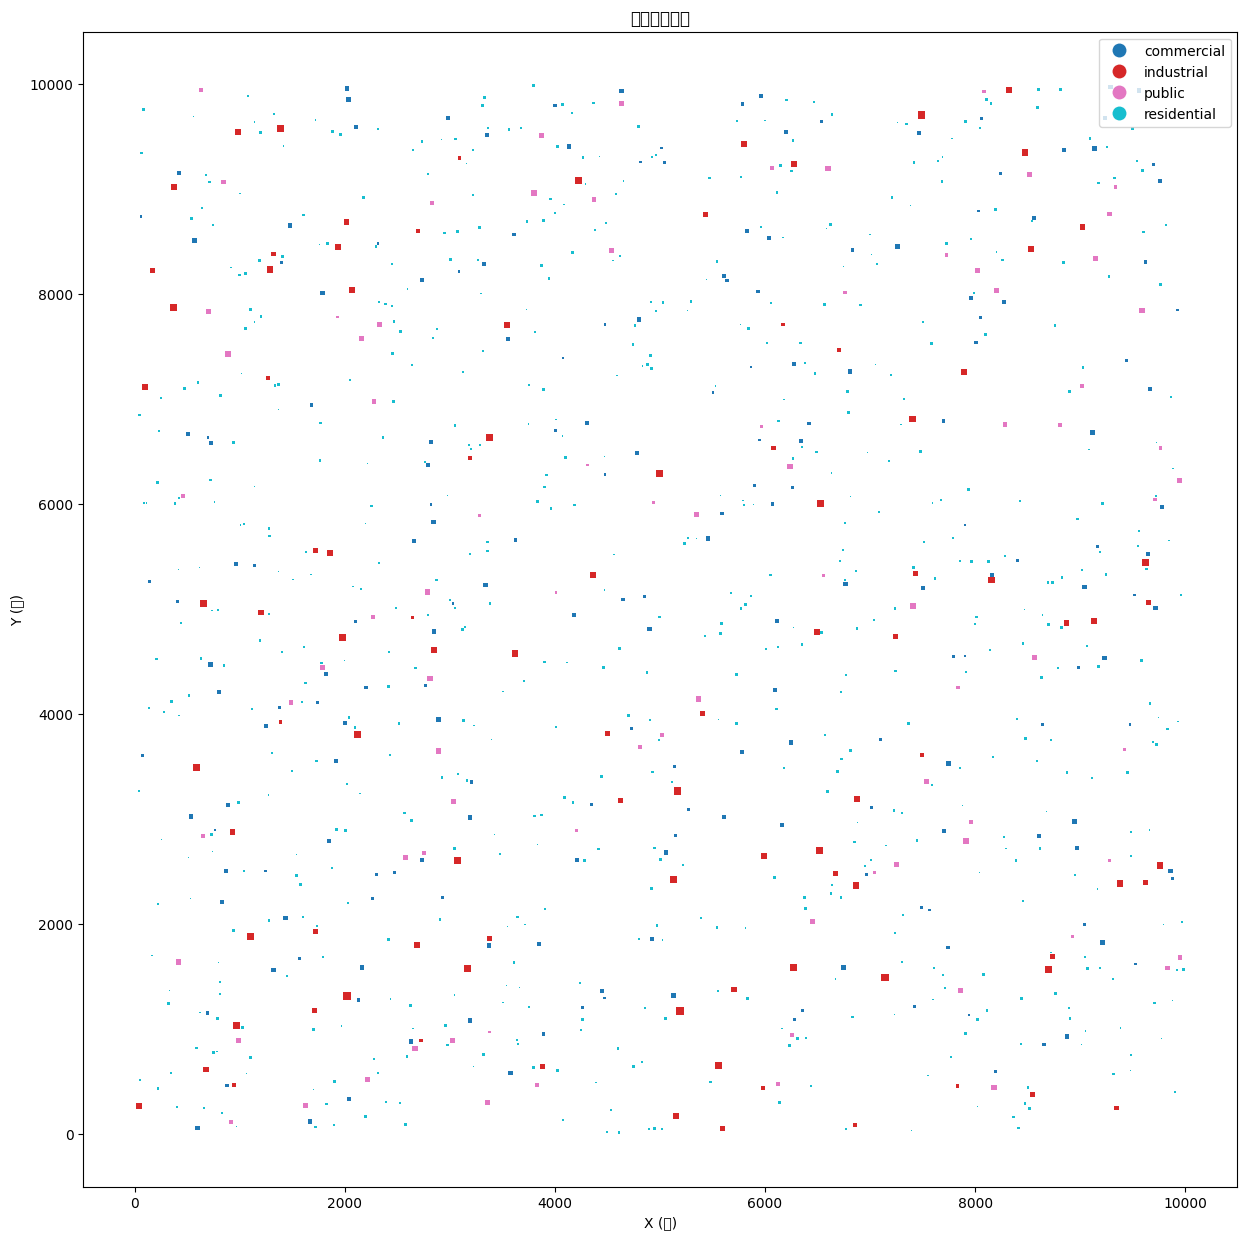

In [4]:
import numpy as np
import geopandas as gpd
from shapely.geometry import Polygon, box
import random
from shapely.ops import unary_union
import matplotlib.pyplot as plt

# 1. 定义研究区域（100平方千米）
def create_study_area():
    # 创建一个10km x 10km的矩形区域
    xmin, ymin = 0, 0
    xmax, ymax = 10000, 10000  # 米为单位
    study_area = box(xmin, ymin, xmax, ymax)
    return study_area

# 2. 生成建筑物参数
def generate_building_params():
    # 建筑类型及其概率
    building_types = {
        'residential': 0.6,
        'commercial': 0.2,
        'industrial': 0.1,
        'public': 0.1
    }
    
    # 根据建筑类型设置参数范围
    type_params = {
        'residential': {
            'height_range': (12, 60),  # 米
            'floor_height': 3,  # 米/层
            'area_range': (100, 800),  # 平方米
            'population_density': (0.02, 0.04)  # 人/平方米
        },
        'commercial': {
            'height_range': (6, 100),
            'floor_height': 4,
            'area_range': (500, 2000),
            'population_density': (0.01, 0.02)
        },
        'industrial': {
            'height_range': (6, 20),
            'floor_height': 4,
            'area_range': (1000, 5000),
            'population_density': (0.005, 0.01)
        },
        'public': {
            'height_range': (6, 30),
            'floor_height': 4,
            'area_range': (500, 3000),
            'population_density': (0.015, 0.03)
        }
    }
    
    building_type = random.choices(list(building_types.keys()), 
                                 list(building_types.values()))[0]
    params = type_params[building_type]
    
    height = random.uniform(*params['height_range'])
    floors = int(height / params['floor_height'])
    area = random.uniform(*params['area_range'])
    population = int(area * floors * random.uniform(*params['population_density']))
    
    return building_type, height, floors, area, population

# 3. 生成建筑物几何形状
def create_building_geometry(x, y, area):
    # 生成矩形建筑
    width = np.sqrt(area)
    height = area / width
    return Polygon([
        (x, y),
        (x + width, y),
        (x + width, y + height),
        (x, y + height)
    ])

# 4. 生成建筑物数据
def generate_buildings(study_area, num_buildings=1000):
    buildings = []
    existing_buildings = []
    
    minx, miny, maxx, maxy = study_area.bounds
    
    while len(buildings) < num_buildings:
        # 生成建筑物参数
        building_type, height, floors, area, population = generate_building_params()
        
        # 随机位置
        x = random.uniform(minx, maxx - np.sqrt(area))
        y = random.uniform(miny, maxy - np.sqrt(area))
        
        # 创建建筑物几何形状
        geometry = create_building_geometry(x, y, area)
        
        # 检查是否与现有建筑重叠
        if not any(geometry.intersects(existing) for existing in existing_buildings):
            buildings.append({
                'geometry': geometry,
                'type': building_type,
                'height': height,
                'floors': floors,
                'area': area,
                'population': population
            })
            existing_buildings.append(geometry)
    
    return gpd.GeoDataFrame(buildings)

# 5. 主函数
def main():
    # 创建研究区域
    study_area = create_study_area()
    
    # 生成建筑物
    buildings_gdf = generate_buildings(study_area)
    
    # 保存为shapefile
    output_path = 'buildings.shp'
    buildings_gdf.to_file(output_path)
    
    # 可视化
    fig, ax = plt.subplots(figsize=(15, 15))
    buildings_gdf.plot(column='type', categorical=True, legend=True, ax=ax)
    plt.title('建筑物分布图')
    plt.xlabel('X (米)')
    plt.ylabel('Y (米)')
    plt.show()

    return buildings_gdf

# 运行程序
if __name__ == "__main__":
    buildings_gdf = main()

我将帮你创建一个在建筑物之间生成道路网络的代码。以下是实现代码：



In [5]:
# import geopandas as gpd
# import networkx as nx
# from shapely.geometry import LineString, MultiLineString
# import numpy as np
# from shapely.ops import unary_union
# import random
# import matplotlib.pyplot as plt
# from shapely.geometry import Point, LineString, box  # 添加 Point 导入

# def create_road_network(buildings_gdf, study_area):
#     # 道路类型及其参数
#     road_types = {
#         'primary': {
#             'width': (20, 30),  # 米
#             'probability': 0.1,
#             'min_length': 500,
#             'max_length': 2000,
#             'speed_limit': 60  # km/h
#         },
#         'secondary': {
#             'width': (15, 20),
#             'probability': 0.3,
#             'min_length': 300,
#             'max_length': 1000,
#             'speed_limit': 50
#         },
#         'local': {
#             'width': (8, 15),
#             'probability': 0.6,
#             'min_length': 100,
#             'max_length': 500,
#             'speed_limit': 30
#         }
#     }

#     # 添加节点
#     nodes = []
#     buildings_union = unary_union(buildings_gdf.geometry)
#     for x in x_points:
#         for y in y_points:
#             # 将坐标元组转换为 Point 对象
#             point = Point(x, y)
#             # 确保节点不在建筑物内部
#             if not buildings_union.contains(point):
#                 nodes.append((x, y))  # 仍然存储为元组用于后续使用
#                 G.add_node((x, y))
    
#     # 添加边（道路）
#     roads = []
#     for i in range(len(nodes)):
#         for j in range(i + 1, len(nodes)):
#             node1, node2 = nodes[i], nodes[j]
#             # 计算两点间距离
#             distance = ((node1[0] - node2[0])**2 + (node1[1] - node2[1])**2)**0.5
            
#             # 选择道路类型
#             road_type = random.choices(list(road_types.keys()),
#                                      [t['probability'] for t in road_types.values()])[0]
#             params = road_types[road_type]
            
#             # 检查距离是否在允许范围内
#             if params['min_length'] <= distance <= params['max_length']:
#                 road = LineString([node1, node2])
#                 # 创建道路缓冲区
#                 road_width = random.uniform(*params['width'])
#                 road_buffer = road.buffer(road_width/2)
                
#                 # 检查是否与建筑物或现有道路重叠
#                 if not road_buffer.intersects(buildings_union):
#                     roads.append({
#                         'geometry': road,
#                         'type': road_type,
#                         'width': road_width,
#                         'length': distance,
#                         'speed_limit': params['speed_limit']
#                     })
#                     G.add_edge(node1, node2)
    
#     # 创建GeoDataFrame
#     roads_gdf = gpd.GeoDataFrame(roads)
    
#     # 保存为shapefile
#     roads_gdf.to_file('roads.shp')
    
#     return roads_gdf

#     # 创建网格点作为可能的道路节点
#     grid_size = 100  # 米
#     minx, miny, maxx, maxy = study_area.bounds
#     x_points = np.arange(minx, maxx, grid_size)
#     y_points = np.arange(miny, maxy, grid_size)
    
#     # 创建图形对象
#     G = nx.Graph()
    
#     # 添加节点
#     nodes = []
#     buildings_union = unary_union(buildings_gdf.geometry)
#     for x in x_points:
#         for y in y_points:
#             point = (x, y)
#             # 确保节点不在建筑物内部
#             if not buildings_union.contains(point):
#                 nodes.append(point)
#                 G.add_node(point)
    
#     # 添加边（道路）
#     roads = []
#     for i in range(len(nodes)):
#         for j in range(i + 1, len(nodes)):
#             node1, node2 = nodes[i], nodes[j]
#             # 计算两点间距离
#             distance = ((node1[0] - node2[0])**2 + (node1[1] - node2[1])**2)**0.5
            
#             # 选择道路类型
#             road_type = random.choices(list(road_types.keys()),
#                                      [t['probability'] for t in road_types.values()])[0]
#             params = road_types[road_type]
            
#             # 检查距离是否在允许范围内
#             if params['min_length'] <= distance <= params['max_length']:
#                 road = LineString([node1, node2])
#                 # 创建道路缓冲区
#                 road_width = random.uniform(*params['width'])
#                 road_buffer = road.buffer(road_width/2)
                
#                 # 检查是否与建筑物或现有道路重叠
#                 if not road_buffer.intersects(buildings_union):
#                     roads.append({
#                         'geometry': road,
#                         'type': road_type,
#                         'width': road_width,
#                         'length': distance,
#                         'speed_limit': params['speed_limit']
#                     })
#                     G.add_edge(node1, node2)
    
#     # 创建GeoDataFrame
#     roads_gdf = gpd.GeoDataFrame(roads)
    
#     # 保存为shapefile
#     roads_gdf.to_file('roads.shp')
    
#     return roads_gdf

# def visualize_buildings_and_roads(buildings_gdf, roads_gdf):
#     # 创建图形
#     fig, ax = plt.subplots(figsize=(15, 15))
    
#     # 绘制建筑物
#     buildings_gdf.plot(column='type', categorical=True, 
#                       legend=True, ax=ax, alpha=0.6)
    
#     # 绘制道路网络
#     roads_gdf.plot(column='type', categorical=True, 
#                   legend=True, ax=ax, linewidth=1)
    
#     plt.title('建筑物和道路网络分布图')
#     plt.xlabel('X (米)')
#     plt.ylabel('Y (米)')
#     plt.show()

# # 主函数
# def main():
#     # 读取之前生成的建筑物数据
#     buildings_gdf = gpd.read_file('buildings.shp')
#     study_area = buildings_gdf.unary_union.convex_hull
    
#     # 生成道路网络
#     roads_gdf = create_road_network(buildings_gdf, study_area)
    
#     # 可视化
#     visualize_buildings_and_roads(buildings_gdf, roads_gdf)

# if __name__ == "__main__":
#     main()



这段代码将：

1. 读取之前生成的建筑物数据
2. 在建筑物之间生成道路网络，包含三种类型的道路：
   - 主干道（primary）
   - 次干道（secondary）
   - 支路（local）
3. 为每条道路分配属性：
   - 道路类型
   - 道路宽度
   - 道路长度
   - 速度限制
4. 确保道路不会与建筑物重叠
5. 将道路网络保存为shapefile文件
6. 生成建筑物和道路网络的综合可视化图

主要特点：

- 使用网格点作为潜在的道路节点
- 不同类型道路有不同的参数范围
- 道路生成考虑合理的长度范围
- 包含与建筑物的碰撞检测
- 道路网络具有层级结构

要运行这段代码，需要额外安装：


In [ ]:
# pip install networkx



你可以通过调整以下参数来优化道路网络：
- 修改网格大小（grid_size）
- 调整道路类型的比例
- 更改道路的参数范围
- 添加更多道路属性

运行代码后，将生成 `roads.shp` 文件，并显示包含建筑物和道路网络的可视化图表。



这段代码将：

1. 创建一个 100 平方千米（10km x 10km）的研究区域
2. 生成不同类型的建筑物（住宅、商业、工业和公共建筑）
3. 为每个建筑物分配合理的参数：
   - 建筑高度
   - 层数
   - 底面积
   - 人口数
   - 建筑类型
4. 确保建筑物之间不会重叠
5. 将数据保存为 shapefile 文件
6. 使用 matplotlib 可视化建筑物分布

主要特点：

- 建筑物类型按照合理的概率分布生成
- 不同类型建筑有不同的参数范围
- 使用简单的矩形来表示建筑物（可以根据需要修改形状）
- 包含空间冲突检测，确保建筑物不会重叠
- 生成的数据保存为标准的 GIS 格式（shapefile）

要运行这段代码，你需要安装以下 Python 包：




你可以根据实际需求调整参数，比如：
- 修改建筑物数量
- 调整各类型建筑的比例
- 更改建筑物的参数范围
- 添加更多建筑物属性

生成的数据将保存在 `buildings.shp` 文件中，同时会显示一个建筑物分布的可视化图表。

请帮我生成一个100平方千米的区域，区域内 有建筑轮廓数据，数据包含建筑高度、建筑的底面积、建筑的层数、建筑类型、每个建筑的人口数和其他一些建筑参数，注意建筑之间要规划合理并且不能有建筑和建筑之间的重叠，输出一个shapefile文件，并使用python可视化数据。然后在这些建筑之间的空隙处，生成一些道路网络，注意路网也不能和这些建筑重合，并且路网也有详细数据属性（包括道路类型、道路宽度、道路的长度和其他关键指标等)，最后也输出shp文件和可视化结果。

下面是生成道路网络的代码，这段代码将在之前生成的建筑物之间创建道路网络：



In [ ]:
import geopandas as gpd
import networkx as nx
from shapely.geometry import LineString, Point
import numpy as np
from shapely.ops import unary_union
import random
import matplotlib.pyplot as plt

def create_road_network(buildings_gdf):
    # 定义道路类型及其参数
    road_types = {
        '主干道': {
            'width': (25, 35),  # 米
            'probability': 0.1,
            'min_length': 500,
            'max_length': 2000,
            'speed_limit': 60,  # km/h
            'lanes': (4, 6)
        },
        '次干道': {
            'width': (15, 25),
            'probability': 0.3,
            'min_length': 300,
            'max_length': 1000,
            'speed_limit': 40,
            'lanes': (2, 4)
        },
        '支路': {
            'width': (8, 15),
            'probability': 0.6,
            'min_length': 100,
            'max_length': 500,
            'speed_limit': 30,
            'lanes': (2, 2)
        }
    }

    # 获取研究区域范围
    study_area = buildings_gdf.unary_union.convex_hull
    minx, miny, maxx, maxy = study_area.bounds
    
    # 创建网格点作为可能的道路节点
    grid_size = 100  # 米
    x_points = np.arange(minx, maxx, grid_size)
    y_points = np.arange(miny, maxy, grid_size)
    
    # 创建图形对象
    G = nx.Graph()
    
    # 添加节点
    nodes = []
    buildings_union = unary_union(buildings_gdf.geometry)
    for x in x_points:
        for y in y_points:
            point = Point(x, y)
            # 确保节点不在建筑物内部且在研究区域内
            if not buildings_union.contains(point) and study_area.contains(point):
                nodes.append((x, y))
                G.add_node((x, y))
    
    # 添加边（道路）
    roads = []
    for i in range(len(nodes)):
        for j in range(i + 1, len(nodes)):
            node1, node2 = nodes[i], nodes[j]
            # 计算两点间距离
            distance = ((node1[0] - node2[0])**2 + (node1[1] - node2[1])**2)**0.5
            
            # 根据概率选择道路类型
            road_type = random.choices(
                list(road_types.keys()),
                [t['probability'] for t in road_types.values()]
            )[0]
            params = road_types[road_type]
            
            # 检查距离是否在允许范围内
            if params['min_length'] <= distance <= params['max_length']:
                road = LineString([node1, node2])
                # 创建道路缓冲区
                road_width = random.uniform(*params['width'])
                road_buffer = road.buffer(road_width/2)
                
                # 检查是否与建筑物或现有道路重叠
                if not road_buffer.intersects(buildings_union):
                    # 随机生成车道数
                    lanes = random.randint(*params['lanes'])
                    
                    roads.append({
                        'geometry': road,
                        'type': road_type,
                        'width': road_width,
                        'length': distance,
                        'speed_limit': params['speed_limit'],
                        'lanes': lanes,
                        'capacity': lanes * 800  # 假设每车道每小时通过800辆车
                    })
                    G.add_edge(node1, node2)
    
    # 创建GeoDataFrame
    roads_gdf = gpd.GeoDataFrame(roads)
    
    # 保存为shapefile
    roads_gdf.to_file('roads.shp')
    
    return roads_gdf

def visualize_buildings_and_roads(buildings_gdf, roads_gdf):
    # 创建图形
    fig, ax = plt.subplots(figsize=(15, 15))
    
    # 绘制建筑物
    buildings_gdf.plot(column='type', categorical=True, 
                      legend=True, ax=ax, alpha=0.6,
                      cmap='Set3')
    
    # 为不同类型的道路设置不同的颜色
    road_colors = {
        '主干道': 'red',
        '次干道': 'blue',
        '支路': 'green'
    }
    
    # 绘制道路网络
    for road_type in road_colors:
        mask = roads_gdf['type'] == road_type
        roads_gdf[mask].plot(
            color=road_colors[road_type],
            ax=ax,
            label=road_type,
            linewidth=roads_gdf[mask]['width']/5  # 道路宽度可视化
        )
    
    plt.title('建筑物和道路网络分布图')
    plt.xlabel('X (米)')
    plt.ylabel('Y (米)')
    plt.legend()
    plt.show()

# 读取之前生成的建筑物数据
buildings_gdf = gpd.read_file('buildings.shp')

# 生成道路网络
roads_gdf = create_road_network(buildings_gdf)

# 可视化结果
visualize_buildings_and_roads(buildings_gdf, roads_gdf)

# 显示道路网络的统计信息
print("\n道路网络统计信息：")
print(f"道路总数：{len(roads_gdf)}")
print("\n各类型道路数量：")
print(roads_gdf['type'].value_counts())
print("\n道路总长度（千米）：{:.2f}".format(roads_gdf['length'].sum() / 1000))
print("\n平均道路宽度（米）：{:.2f}".format(roads_gdf['width'].mean()))



这段代码将：

1. 定义了三种道路类型：主干道、次干道和支路，每种类型都有其特定的参数
2. 在建筑物之间的空隙处生成道路网络
3. 为每条道路添加详细属性（类型、宽度、长度、车道数等）
4. 保存为shapefile文件
5. 可视化建筑物和道路网络
6. 输出道路网络的统计信息

需要在运行代码前确保已经生成了建筑物的shapefile文件。代码会自动避免道路与建筑物的重叠，并为不同类型的道路设置不同的颜色和宽度进行可视化。

# v1

我注意到代码中存在一些问题，让我帮你进行调试：

1. **代码结构重复**：`create_road_network` 函数中有重复的代码块，需要删除一份。

2. **变量定义顺序问题**：`x_points` 和 `y_points` 在使用前没有定义。

3. **图对象 G 的定义时机不对**：在使用 `G` 之前没有定义。

这是修复后的代码：



In [6]:
def create_road_network(buildings_gdf, study_area):
    # 道路类型及其参数
    road_types = {
        'primary': {
            'width': (20, 30),  # 米
            'probability': 0.1,
            'min_length': 500,
            'max_length': 2000,
            'speed_limit': 60  # km/h
        },
        'secondary': {
            'width': (15, 20),
            'probability': 0.3,
            'min_length': 300,
            'max_length': 1000,
            'speed_limit': 50
        },
        'local': {
            'width': (8, 15),
            'probability': 0.6,
            'min_length': 100,
            'max_length': 500,
            'speed_limit': 30
        }
    }

    # 创建网格点作为可能的道路节点
    grid_size = 100  # 米
    minx, miny, maxx, maxy = study_area.bounds
    x_points = np.arange(minx, maxx, grid_size)
    y_points = np.arange(miny, maxy, grid_size)
    
    # 创建图形对象
    G = nx.Graph()
    
    # 添加节点
    nodes = []
    buildings_union = unary_union(buildings_gdf.geometry)
    for x in x_points:
        for y in y_points:
            point = Point(x, y)
            # 确保节点不在建筑物内部
            if not buildings_union.contains(point):
                nodes.append((x, y))
                G.add_node((x, y))
    
    # 添加边（道路）
    roads = []
    for i in range(len(nodes)):
        for j in range(i + 1, len(nodes)):
            node1, node2 = nodes[i], nodes[j]
            # 计算两点间距离
            distance = ((node1[0] - node2[0])**2 + (node1[1] - node2[1])**2)**0.5
            
            # 选择道路类型
            road_type = random.choices(list(road_types.keys()),
                                     [t['probability'] for t in road_types.values()])[0]
            params = road_types[road_type]
            
            # 检查距离是否在允许范围内
            if params['min_length'] <= distance <= params['max_length']:
                road = LineString([node1, node2])
                # 创建道路缓冲区
                road_width = random.uniform(*params['width'])
                road_buffer = road.buffer(road_width/2)
                
                # 检查是否与建筑物或现有道路重叠
                if not road_buffer.intersects(buildings_union):
                    roads.append({
                        'geometry': road,
                        'type': road_type,
                        'width': road_width,
                        'length': distance,
                        'speed_limit': params['speed_limit']
                    })
                    G.add_edge(node1, node2)
    
    # 创建GeoDataFrame
    roads_gdf = gpd.GeoDataFrame(roads)
    
    # 保存为shapefile
    roads_gdf.to_file('roads.shp')
    
    return roads_gdf



主要修改包括：

1. 删除了重复的代码块
2. 将网格点的创建代码移到函数开始处
3. 确保在使用 `G` 之前创建了图对象
4. 使用 `Point` 对象来正确检查节点是否在建筑物内

另外，建议添加以下错误处理：

1. 检查输入的 `buildings_gdf` 是否为空
2. 确保生成的道路网络至少包含一条道路
3. 添加对 shapefiles 写入权限的检查

你可以添加如下错误处理代码：



In [7]:
def create_road_network(buildings_gdf, study_area):
    # 检查输入数据
    if buildings_gdf.empty:
        raise ValueError("建筑物数据为空")
    
    # ... 原有代码 ...
    
    # 检查是否生成了道路
    if not roads:
        raise ValueError("未能生成任何有效的道路")
        
    try:
        roads_gdf.to_file('roads.shp')
    except PermissionError:
        print("警告：无法保存shapefile文件，请检查写入权限")
        
    return roads_gdf

d:\anaconda3\envs\play\Lib\site-packages\pyogrio\geopandas.py:662: UserWarning: 'crs' was not provided.  The output dataset will not have projection information defined and may not be usable in other systems.
  write(


<Axes: >

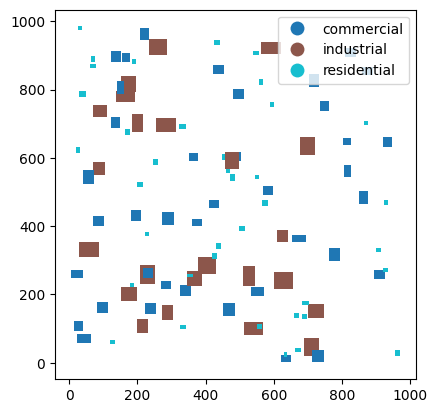

In [8]:
import geopandas as gpd
from shapely.geometry import Polygon, box
import random
import numpy as np

def generate_buildings(study_area_bounds, num_buildings=100):
    minx, miny, maxx, maxy = study_area_bounds
    
    buildings = []
    building_types = ['residential', 'commercial', 'industrial']
    building_sizes = {
        'residential': (10, 20),
        'commercial': (20, 40),
        'industrial': (30, 60)
    }
    
    for _ in range(num_buildings):
        # 随机选择建筑类型
        building_type = random.choice(building_types)
        size_range = building_sizes[building_type]
        
        # 随机生成建筑物尺寸和位置
        width = random.uniform(*size_range)
        height = random.uniform(*size_range)
        x = random.uniform(minx, maxx - width)
        y = random.uniform(miny, maxy - height)
        
        # 创建建筑物多边形
        building = box(x, y, x + width, y + height)
        
        buildings.append({
            'geometry': building,
            'type': building_type,
            'area': building.area
        })
    
    # 创建GeoDataFrame
    buildings_gdf = gpd.GeoDataFrame(buildings)
    
    # 保存为shapefile
    buildings_gdf.to_file('buildings.shp')
    
    return buildings_gdf

# 定义研究区域范围
study_area_bounds = (0, 0, 1000, 1000)  # 示例范围，单位：米

# 生成建筑物
buildings_gdf = generate_buildings(study_area_bounds, num_buildings=100)

# 简单可视化
buildings_gdf.plot(column='type', categorical=True, legend=True)

## 生成道路网络

下面是生成道路网络的代码，这段代码将在之前生成的建筑物之间创建道路网络：



C:\Users\fengq\AppData\Local\Temp\ipykernel_17604\4127852681.py:39: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  study_area = buildings_gdf.unary_union.convex_hull
C:\Users\fengq\AppData\Local\Temp\ipykernel_17604\4127852681.py:103: UserWarning: Column names longer than 10 characters will be truncated when saved to ESRI Shapefile.
  roads_gdf.to_file('roads.shp')
d:\anaconda3\envs\play\Lib\site-packages\pyogrio\geopandas.py:662: UserWarning: 'crs' was not provided.  The output dataset will not have projection information defined and may not be usable in other systems.
  write(
d:\anaconda3\envs\play\Lib\site-packages\pyogrio\raw.py:723: RuntimeWarning: Normalized/laundered field name: 'speed_limit' to 'speed_limi'
  ogr_write(
d:\anaconda3\envs\play\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 31859 (\N{CJK UNIFIED IDEOGRAPH-7C73}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw

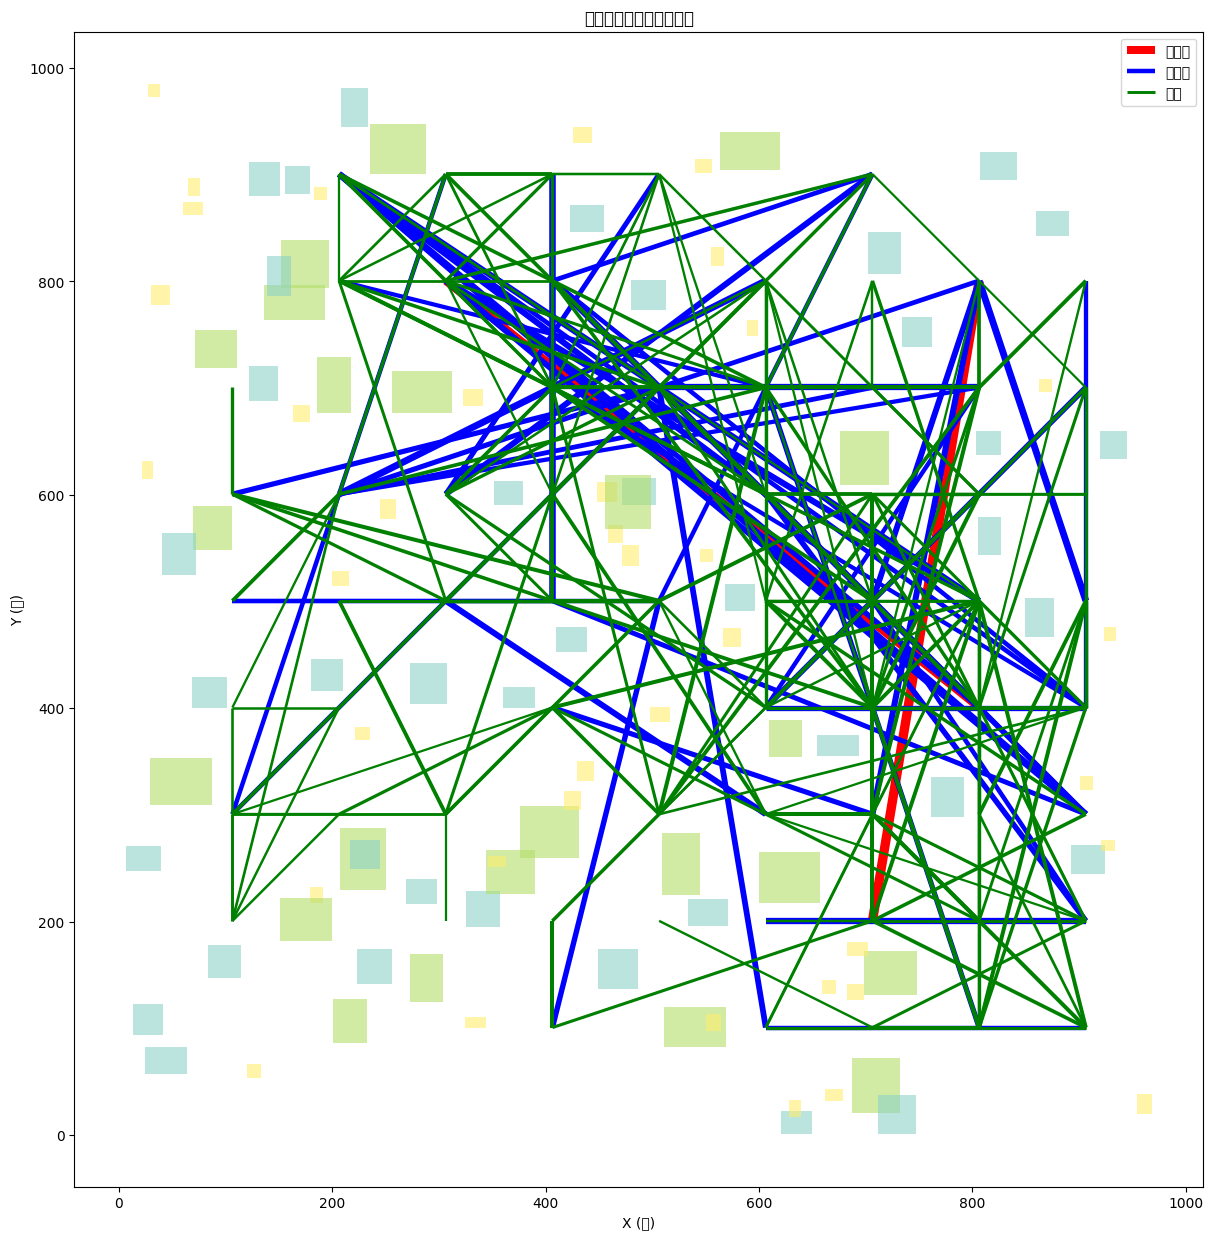


道路网络统计信息：
道路总数：248

各类型道路数量：
type
支路     200
次干道     46
主干道      2
Name: count, dtype: int64

道路总长度（千米）：72.03

平均道路宽度（米）：12.90


In [9]:
import geopandas as gpd
import networkx as nx
from shapely.geometry import LineString, Point
import numpy as np
from shapely.ops import unary_union
import random
import matplotlib.pyplot as plt

def create_road_network(buildings_gdf):
    # 定义道路类型及其参数
    road_types = {
        '主干道': {
            'width': (25, 35),  # 米
            'probability': 0.1,
            'min_length': 500,
            'max_length': 2000,
            'speed_limit': 60,  # km/h
            'lanes': (4, 6)
        },
        '次干道': {
            'width': (15, 25),
            'probability': 0.3,
            'min_length': 300,
            'max_length': 1000,
            'speed_limit': 40,
            'lanes': (2, 4)
        },
        '支路': {
            'width': (8, 15),
            'probability': 0.6,
            'min_length': 100,
            'max_length': 500,
            'speed_limit': 30,
            'lanes': (2, 2)
        }
    }

    # 获取研究区域范围
    study_area = buildings_gdf.unary_union.convex_hull
    minx, miny, maxx, maxy = study_area.bounds
    
    # 创建网格点作为可能的道路节点
    grid_size = 100  # 米
    x_points = np.arange(minx, maxx, grid_size)
    y_points = np.arange(miny, maxy, grid_size)
    
    # 创建图形对象
    G = nx.Graph()
    
    # 添加节点
    nodes = []
    buildings_union = unary_union(buildings_gdf.geometry)
    for x in x_points:
        for y in y_points:
            point = Point(x, y)
            # 确保节点不在建筑物内部且在研究区域内
            if not buildings_union.contains(point) and study_area.contains(point):
                nodes.append((x, y))
                G.add_node((x, y))
    
    # 添加边（道路）
    roads = []
    for i in range(len(nodes)):
        for j in range(i + 1, len(nodes)):
            node1, node2 = nodes[i], nodes[j]
            # 计算两点间距离
            distance = ((node1[0] - node2[0])**2 + (node1[1] - node2[1])**2)**0.5
            
            # 根据概率选择道路类型
            road_type = random.choices(
                list(road_types.keys()),
                [t['probability'] for t in road_types.values()]
            )[0]
            params = road_types[road_type]
            
            # 检查距离是否在允许范围内
            if params['min_length'] <= distance <= params['max_length']:
                road = LineString([node1, node2])
                # 创建道路缓冲区
                road_width = random.uniform(*params['width'])
                road_buffer = road.buffer(road_width/2)
                
                # 检查是否与建筑物或现有道路重叠
                if not road_buffer.intersects(buildings_union):
                    # 随机生成车道数
                    lanes = random.randint(*params['lanes'])
                    
                    roads.append({
                        'geometry': road,
                        'type': road_type,
                        'width': road_width,
                        'length': distance,
                        'speed_limit': params['speed_limit'],
                        'lanes': lanes,
                        'capacity': lanes * 800  # 假设每车道每小时通过800辆车
                    })
                    G.add_edge(node1, node2)
    
    # 创建GeoDataFrame
    roads_gdf = gpd.GeoDataFrame(roads)
    
    # 保存为shapefile
    roads_gdf.to_file('roads.shp')
    
    return roads_gdf

def visualize_buildings_and_roads(buildings_gdf, roads_gdf):
    # 创建图形
    fig, ax = plt.subplots(figsize=(15, 15))
    
    # 绘制建筑物
    buildings_gdf.plot(column='type', categorical=True, 
                      legend=True, ax=ax, alpha=0.6,
                      cmap='Set3')
    
    # 为不同类型的道路设置不同的颜色
    road_colors = {
        '主干道': 'red',
        '次干道': 'blue',
        '支路': 'green'
    }
    
    # 绘制道路网络
    for road_type in road_colors:
        mask = roads_gdf['type'] == road_type
        roads_gdf[mask].plot(
            color=road_colors[road_type],
            ax=ax,
            label=road_type,
            linewidth=roads_gdf[mask]['width']/5  # 道路宽度可视化
        )
    
    plt.title('建筑物和道路网络分布图')
    plt.xlabel('X (米)')
    plt.ylabel('Y (米)')
    plt.legend()
    plt.show()

# 读取之前生成的建筑物数据
buildings_gdf = gpd.read_file('buildings.shp')

# 生成道路网络
roads_gdf = create_road_network(buildings_gdf)

# 可视化结果
visualize_buildings_and_roads(buildings_gdf, roads_gdf)

# 显示道路网络的统计信息
print("\n道路网络统计信息：")
print(f"道路总数：{len(roads_gdf)}")
print("\n各类型道路数量：")
print(roads_gdf['type'].value_counts())
print("\n道路总长度（千米）：{:.2f}".format(roads_gdf['length'].sum() / 1000))
print("\n平均道路宽度（米）：{:.2f}".format(roads_gdf['width'].mean()))



这段代码将：

1. 定义了三种道路类型：主干道、次干道和支路，每种类型都有其特定的参数
2. 在建筑物之间的空隙处生成道路网络
3. 为每条道路添加详细属性（类型、宽度、长度、车道数等）
4. 保存为shapefile文件
5. 可视化建筑物和道路网络
6. 输出道路网络的统计信息

需要在运行代码前确保已经生成了建筑物的shapefile文件。代码会自动避免道路与建筑物的重叠，并为不同类型的道路设置不同的颜色和宽度进行可视化。

# v2

我将帮您创建一个包含能源消耗数据的网格图层。下面是相应的代码：



C:\Users\fengq\AppData\Local\Temp\ipykernel_17604\190026307.py:8: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  study_area = buildings_gdf.unary_union.convex_hull
C:\Users\fengq\AppData\Local\Temp\ipykernel_17604\190026307.py:51: UserWarning: Column names longer than 10 characters will be truncated when saved to ESRI Shapefile.
  energy_grid_gdf.to_file('energy_grid.shp')
d:\anaconda3\envs\play\Lib\site-packages\pyogrio\geopandas.py:662: UserWarning: 'crs' was not provided.  The output dataset will not have projection information defined and may not be usable in other systems.
  write(
d:\anaconda3\envs\play\Lib\site-packages\pyogrio\raw.py:723: RuntimeWarning: Normalized/laundered field name: 'energy_consumption' to 'energy_con'
  ogr_write(
d:\anaconda3\envs\play\Lib\site-packages\pyogrio\raw.py:723: RuntimeWarning: Normalized/laundered field name: 'energy_density' to 'energy_den'
  ogr_write(
C:\Users\fengq\AppData\Local\Temp\

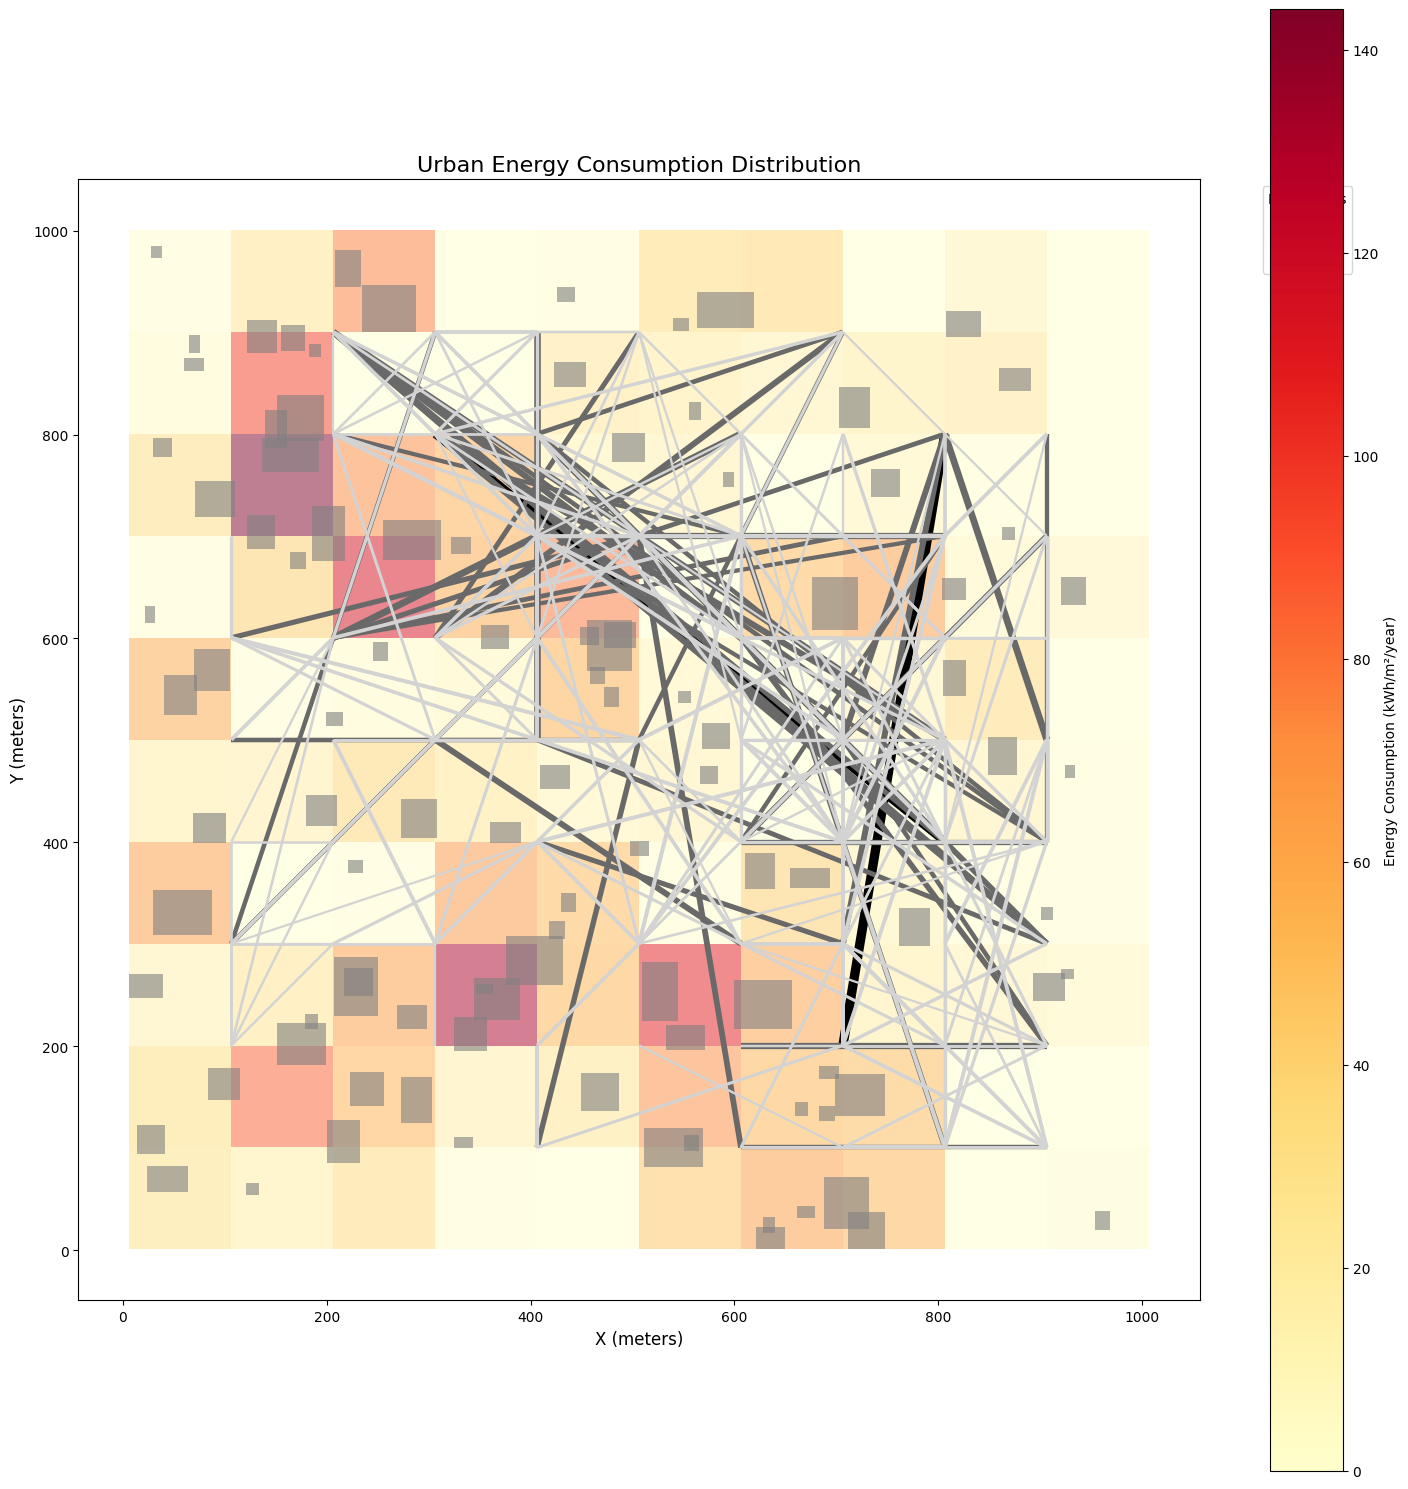


Energy Consumption Statistics:
Total Grid Cells: 100
Total Energy Consumption: 28.82 GWh/year
Average Energy Density: 28.82 kWh/m²/year
Max Energy Density: 144.01 kWh/m²/year
Min Energy Density: 0.00 kWh/m²/year


In [10]:
import geopandas as gpd
from shapely.geometry import box
import numpy as np
import matplotlib.pyplot as plt

def create_energy_consumption_grid(buildings_gdf, grid_size=100):
    # 获取研究区域范围
    study_area = buildings_gdf.unary_union.convex_hull
    minx, miny, maxx, maxy = study_area.bounds
    
    # 创建网格
    grid_cells = []
    x_coords = np.arange(minx, maxx, grid_size)
    y_coords = np.arange(miny, maxy, grid_size)
    
    for x in x_coords:
        for y in y_coords:
            cell = box(x, y, x + grid_size, y + grid_size)
            
            # 计算网格内的建筑物
            cell_buildings = buildings_gdf[buildings_gdf.intersects(cell)]
            
            # 基于建筑特征计算能源消耗
            base_consumption = np.random.normal(100, 20)  # 基础能耗 (kWh/m²/year)
            
            # 根据建筑类型调整能源消耗
            type_multiplier = {
                'residential': 1.0,
                'commercial': 1.5,
                'industrial': 2.0
            }
            
            total_consumption = 0
            if not cell_buildings.empty:
                for _, building in cell_buildings.iterrows():
                    area = building.geometry.area
                    multiplier = type_multiplier[building['type']]
                    total_consumption += base_consumption * area * multiplier
            
            grid_cells.append({
                'geometry': cell,
                'energy_consumption': total_consumption,  # kWh/year
                'energy_density': total_consumption / (grid_size * grid_size),  # kWh/m²/year
                'cell_size': grid_size
            })
    
    # 创建GeoDataFrame
    energy_grid_gdf = gpd.GeoDataFrame(grid_cells)
    
    # 保存为shapefile
    energy_grid_gdf.to_file('energy_grid.shp')
    
    return energy_grid_gdf

def visualize_energy_consumption(buildings_gdf, roads_gdf, energy_grid_gdf):
    # 创建图形
    fig, ax = plt.subplots(figsize=(15, 15))
    
    # 绘制能源消耗热力图
    energy_grid_gdf.plot(column='energy_density', 
                        ax=ax,
                        alpha=0.5,
                        legend=True,
                        legend_kwds={'label': 'Energy Consumption (kWh/m²/year)'},
                        cmap='YlOrRd')
    
    # 绘制建筑物
    buildings_gdf.plot(ax=ax,
                      color='grey',
                      alpha=0.6)
    
    # 绘制道路
    road_colors = {
        '主干道': 'black',
        '次干道': 'dimgrey',
        '支路': 'lightgrey'
    }
    
    for road_type in road_colors:
        mask = roads_gdf['type'] == road_type
        roads_gdf[mask].plot(
            color=road_colors[road_type],
            ax=ax,
            label=road_type,
            linewidth=roads_gdf[mask]['width']/5
        )
    
    # 设置图表属性
    plt.title('Urban Energy Consumption Distribution', fontsize=16)
    plt.xlabel('X (meters)', fontsize=12)
    plt.ylabel('Y (meters)', fontsize=12)
    plt.legend(title='Road Types', bbox_to_anchor=(1.05, 1), loc='upper left')
    
    # 添加比例尺和指北针（简化版本）
    ax.set_aspect('equal')
    
    plt.tight_layout()
    plt.show()

# 读取之前生成的数据
buildings_gdf = gpd.read_file('buildings.shp')
roads_gdf = gpd.read_file('roads.shp')

# 生成能源消耗网格数据
energy_grid_gdf = create_energy_consumption_grid(buildings_gdf)

# 可视化结果
visualize_energy_consumption(buildings_gdf, roads_gdf, energy_grid_gdf)

# 显示能源消耗统计信息
print("\nEnergy Consumption Statistics:")
print(f"Total Grid Cells: {len(energy_grid_gdf)}")
print(f"Total Energy Consumption: {energy_grid_gdf['energy_consumption'].sum()/1e6:.2f} GWh/year")
print(f"Average Energy Density: {energy_grid_gdf['energy_density'].mean():.2f} kWh/m²/year")
print(f"Max Energy Density: {energy_grid_gdf['energy_density'].max():.2f} kWh/m²/year")
print(f"Min Energy Density: {energy_grid_gdf['energy_density'].min():.2f} kWh/m²/year")



这段代码将：

1. 创建一个新的函数 `create_energy_consumption_grid` 来生成网格能源消耗数据
   - 使用 100m x 100m 的网格单元
   - 基于建筑物类型和面积计算能源消耗
   - 为每个网格单元分配能源密度值

2. 创建可视化函数 `visualize_energy_consumption` 来展示：
   - 能源消耗热力图（使用 YlOrRd 色带）
   - 建筑物轮廓（灰色）
   - 道路网络（黑色系）

3. 输出能源消耗的统计信息：
   - 网格单元总数
   - 总能源消耗（GWh/年）
   - 平均能源密度
   - 最大和最小能源密度

所有图表标签和统计信息都使用英文显示，确保输出的专业性和国际化。生成的 `energy_grid.shp` 文件可以用于后续分析。

我将帮您计算每个网格的建筑和道路形态因子，并分析它们与能源消耗的关系。以下是完整代码：



In [13]:
import pandas as pd
from scipy import stats
import seaborn as sns

def calculate_urban_morphology(buildings_gdf, roads_gdf, energy_grid_gdf):
    """计算每个网格的城市形态因子"""
    
    morphology_data = []
    
    for idx, grid_cell in energy_grid_gdf.iterrows():
        cell_geom = grid_cell.geometry
        
        # 提取网格内的建筑物和道路
        cell_buildings = buildings_gdf[buildings_gdf.intersects(cell_geom)]
        cell_roads = roads_gdf[roads_gdf.intersects(cell_geom)]
        
        # 建筑形态因子
        building_factors = {
            'grid_id': idx,
            'energy_consumption': grid_cell['energy_consumption'],
            'energy_density': grid_cell['energy_density'],
            
            # 1. 建筑密度相关
            'building_coverage_ratio': cell_buildings.geometry.area.sum() / cell_geom.area if len(cell_buildings) > 0 else 0,
            'building_count': len(cell_buildings),
            'avg_building_size': cell_buildings.geometry.area.mean() if len(cell_buildings) > 0 else 0,
            
            # 2. 建筑类型组成
            'residential_ratio': len(cell_buildings[cell_buildings['type'] == 'residential']) / len(cell_buildings) if len(cell_buildings) > 0 else 0,
            'commercial_ratio': len(cell_buildings[cell_buildings['type'] == 'commercial']) / len(cell_buildings) if len(cell_buildings) > 0 else 0,
            'industrial_ratio': len(cell_buildings[cell_buildings['type'] == 'industrial']) / len(cell_buildings) if len(cell_buildings) > 0 else 0,
            
            # 3. 道路网络特征
            'road_density': cell_roads.geometry.length.sum() / cell_geom.area if len(cell_roads) > 0 else 0,
            'main_road_ratio': len(cell_roads[cell_roads['type'] == '主干道']) / len(cell_roads) if len(cell_roads) > 0 else 0,
            'avg_road_width': cell_roads['width'].mean() if len(cell_roads) > 0 else 0
        }
        
        morphology_data.append(building_factors)
    
    return pd.DataFrame(morphology_data)

def visualize_morphology_relationships(morphology_df):
    """可视化形态因子与能源消耗的关系"""
    
    # 设置图表风格
    plt.style.use('seaborn')
    
    # 创建相关系数热力图
    factor_columns = [col for col in morphology_df.columns if col not in ['grid_id', 'energy_consumption', 'energy_density']]
    correlation_matrix = morphology_df[factor_columns + ['energy_density']].corr()
    
    plt.figure(figsize=(12, 8))
    sns.heatmap(correlation_matrix, annot=True, cmap='RdYlBu', center=0)
    plt.title('Correlation Between Urban Morphology Factors and Energy Consumption')
    plt.tight_layout()
    plt.show()
    
    # 创建散点图矩阵
    factors_to_plot = ['building_coverage_ratio', 'road_density', 'avg_building_size', 'energy_density']
    fig = plt.figure(figsize=(15, 15))
    sns.pairplot(morphology_df[factors_to_plot], diag_kind='kde')
    plt.suptitle('Relationships Between Key Morphology Factors and Energy Consumption', y=1.02)
    plt.show()

# 计算形态因子
morphology_df = calculate_urban_morphology(buildings_gdf, roads_gdf, energy_grid_gdf)

# 保存结果到CSV文件
morphology_df.to_csv('urban_morphology_data.csv', index=False)

# 显示基本统计信息
print("\nUrban Morphology Statistics:")
print(morphology_df.describe())

# 可视化形态因子与能源消耗的关系
# visualize_morphology_relationships(morphology_df)

# 计算形态因子与能源消耗的相关性分析
for factor in morphology_df.columns:
    if factor not in ['grid_id', 'energy_consumption', 'energy_density']:
        correlation = stats.pearsonr(morphology_df[factor], morphology_df['energy_density'])
        print(f"\nCorrelation between {factor} and energy density:")
        print(f"R-value: {correlation[0]:.3f}")
        print(f"P-value: {correlation[1]:.3f}")


Urban Morphology Statistics:
          grid_id  energy_consumption  energy_density  \
count  100.000000        1.000000e+02      100.000000   
mean    49.500000        2.881644e+05       28.816442   
std     29.011492        3.177922e+05       31.779223   
min      0.000000        0.000000e+00        0.000000   
25%     24.750000        1.776038e+04        1.776038   
50%     49.500000        1.659160e+05       16.591600   
75%     74.250000        5.114189e+05       51.141893   
max     99.000000        1.440052e+06      144.005187   

       building_coverage_ratio  building_count  avg_building_size  \
count               100.000000      100.000000         100.000000   
mean                  0.159073        1.560000         814.938401   
std                   0.159476        1.217051         669.325175   
min                   0.000000        0.000000           0.000000   
25%                   0.020283        1.000000         196.353818   
50%                   0.114845        1.00



这段代码将：

1. **计算以下形态因子**：
   - 建筑密度相关：
     - 建筑覆盖率
     - 建筑数量
     - 平均建筑面积
   - 建筑类型组成：
     - 住宅比例
     - 商业比例
     - 工业比例
   - 道路网络特征：
     - 道路密度
     - 主干道比例
     - 平均道路宽度

2. **输出与可视化**：
   - 将所有数据保存为CSV文件
   - 生成相关系数热力图
   - 创建关键因子的散点图矩阵
   - 计算每个形态因子与能源消耗的相关性分析

3. **统计分析**：
   - 显示所有形态因子的基本统计信息
   - 计算皮尔逊相关系数和显著性检验

要运行此代码，确保您已经有了前面生成的建筑物、道路网络和能源消耗网格数据。运行后，您将得到完整的形态因子分析结果和可视化图表。

我将帮您创建一个更全面的可视化代码，用于展示CSV表格的内容。以下是代码实现：



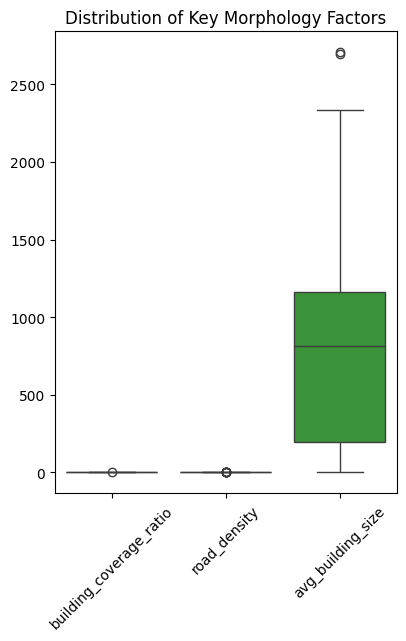

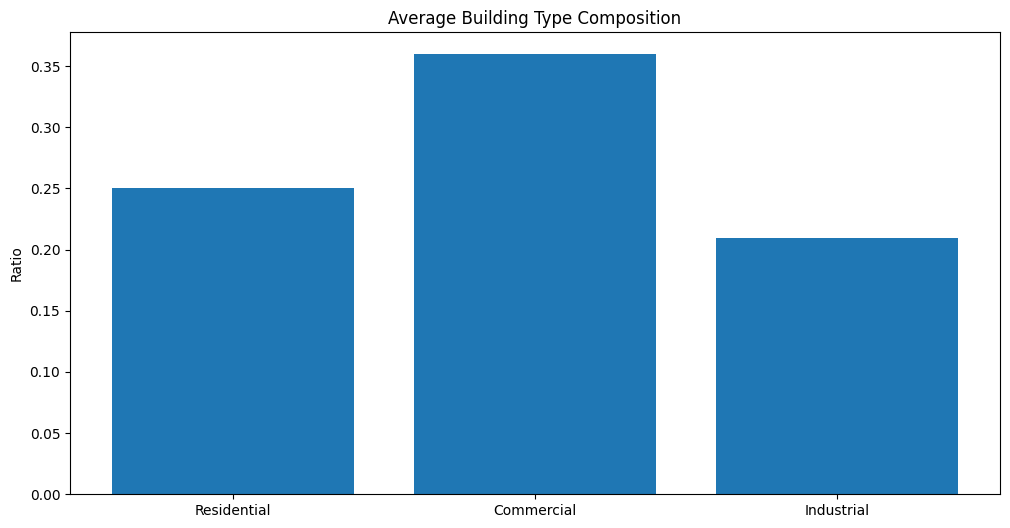

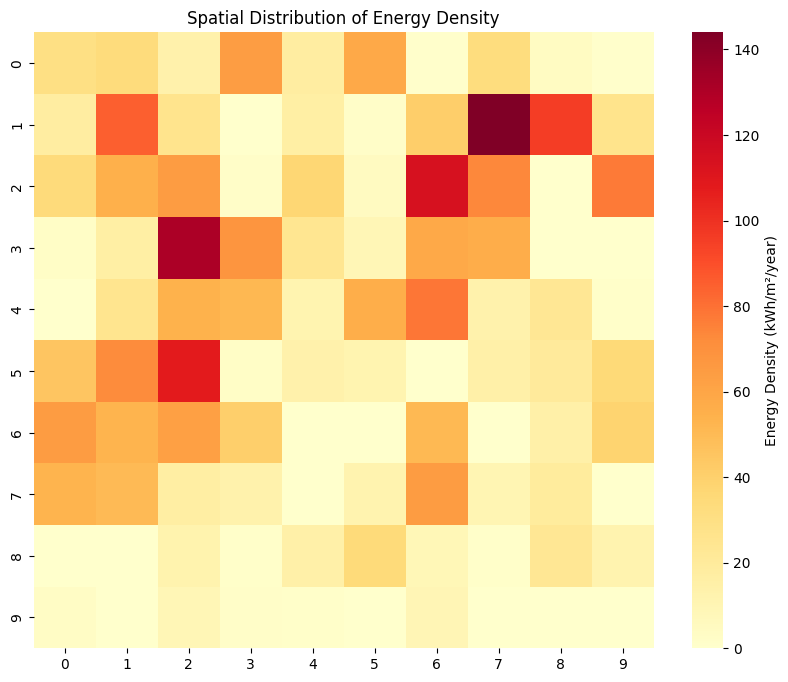

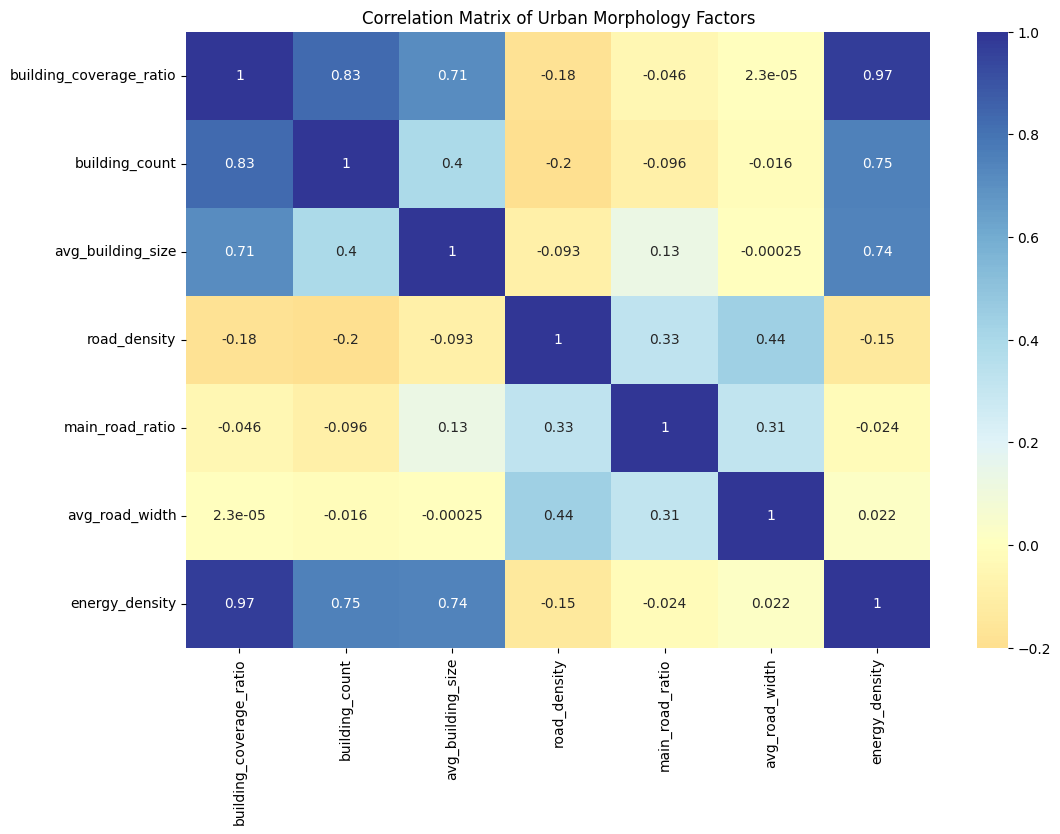

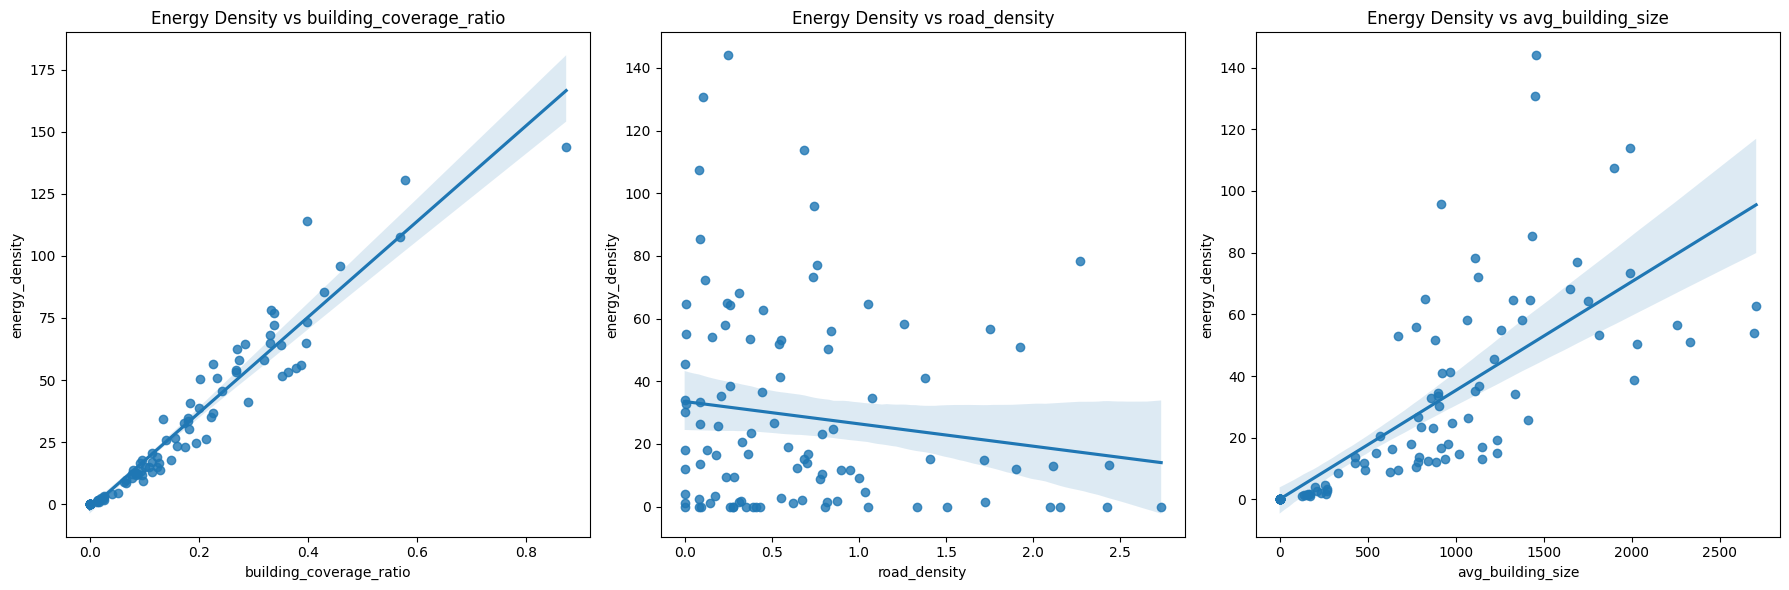


Summary Statistics:
       grid_id  energy_consumption  energy_density  building_coverage_ratio  \
count  100.000             100.000         100.000                  100.000   
mean    49.500          288164.419          28.816                    0.159   
std     29.011          317792.230          31.779                    0.159   
min      0.000               0.000           0.000                    0.000   
25%     24.750           17760.380           1.776                    0.020   
50%     49.500          165916.000          16.592                    0.115   
75%     74.250          511418.933          51.142                    0.249   
max     99.000         1440051.874         144.005                    0.874   

       building_count  avg_building_size  residential_ratio  commercial_ratio  \
count         100.000            100.000            100.000           100.000   
mean            1.560            814.938              0.250             0.360   
std             1.217   

In [14]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

def visualize_morphology_data(csv_file='urban_morphology_data.csv'):
    # 读取CSV文件
    df = pd.read_csv(csv_file)
    
    # 1. 创建形态因子分布箱线图
    plt.figure(figsize=(15, 6))
    factors = ['building_coverage_ratio', 'road_density', 'avg_building_size']
    
    plt.subplot(131)
    sns.boxplot(data=df[factors])
    plt.xticks(rotation=45)
    plt.title('Distribution of Key Morphology Factors')
    
    # 2. 建筑类型比例堆叠柱状图
    plt.figure(figsize=(12, 6))
    building_types = df[['residential_ratio', 'commercial_ratio', 'industrial_ratio']].mean()
    plt.bar(range(len(building_types)), building_types)
    plt.xticks(range(len(building_types)), ['Residential', 'Commercial', 'Industrial'])
    plt.title('Average Building Type Composition')
    plt.ylabel('Ratio')
    
    # 3. 能源消耗密度分布热图
    plt.figure(figsize=(10, 8))
    energy_pivot = df.pivot_table(
        values='energy_density',
        index=np.arange(len(df)) // int(np.sqrt(len(df))),
        columns=np.arange(len(df)) % int(np.sqrt(len(df))),
        aggfunc='first'
    )
    sns.heatmap(energy_pivot, cmap='YlOrRd', 
                cbar_kws={'label': 'Energy Density (kWh/m²/year)'})
    plt.title('Spatial Distribution of Energy Density')
    
    # 4. 相关性分析图
    plt.figure(figsize=(12, 8))
    factors_for_correlation = [
        'building_coverage_ratio', 'building_count', 'avg_building_size',
        'road_density', 'main_road_ratio', 'avg_road_width',
        'energy_density'
    ]
    correlation = df[factors_for_correlation].corr()
    sns.heatmap(correlation, annot=True, cmap='RdYlBu', center=0)
    plt.title('Correlation Matrix of Urban Morphology Factors')
    
    # 5. 回归分析图
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    
    for i, factor in enumerate(['building_coverage_ratio', 'road_density', 'avg_building_size']):
        sns.regplot(data=df, x=factor, y='energy_density', ax=axes[i])
        axes[i].set_title(f'Energy Density vs {factor}')
    
    plt.tight_layout()
    plt.show()
    
    # 6. 输出统计摘要
    print("\nSummary Statistics:")
    print(df.describe().round(3))
    
    # 7. 计算和显示关键指标
    print("\nKey Metrics:")
    print(f"Average Energy Density: {df['energy_density'].mean():.2f} kWh/m²/year")
    print(f"Average Building Coverage: {df['building_coverage_ratio'].mean():.2%}")
    print(f"Average Road Density: {df['road_density'].mean():.3f} m/m²")

# 运行可视化
visualize_morphology_data()



这段代码将生成多个可视化图表：

1. **形态因子分布箱线图**：
   - 显示主要形态因子的数值分布
   - 包含中位数、四分位数和异常值

2. **建筑类型比例图**：
   - 展示住宅、商业和工业建筑的平均比例
   - 使用堆叠柱状图表示

3. **能源消耗密度热图**：
   - 展示能源消耗的空间分布
   - 使用颜色深浅表示能源密度大小

4. **相关性矩阵图**：
   - 显示所有形态因子之间的相关性
   - 使用热力图表示，包含具体相关系数

5. **回归分析图**：
   - 展示主要形态因子与能源消耗的关系
   - 包含回归线和置信区间

6. **统计摘要**：
   - 显示所有变量的描述性统计
   - 包括均值、标准差、最小值、最大值等

7. **关键指标**：
   - 输出重要的平均值指标
   - 包括能源密度、建筑覆盖率和道路密度

这些可视化将帮助您更好地理解：
- 城市形态因子的分布特征
- 形态因子与能源消耗的关系
- 空间模式和集聚现象
- 数据的整体统计特征

建议您根据具体需求，可以注释掉不需要的图表，或调整图表的大小和样式。

我将帮您创建一个专门用于可视化Summary Statistics的函数。以下是优化后的代码：



C:\Users\fengq\AppData\Local\Temp\ipykernel_17604\26366153.py:25: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax2.set_xticklabels(ax2.get_xticklabels(), rotation=45, ha='right')



Detailed Statistics:
                 Metric    Mean     Std   Min      Max
building_coverage_ratio   0.159   0.159 0.000    0.874
         building_count   1.560   1.217 0.000    6.000
      avg_building_size 814.938 669.325 0.000 2706.113
           road_density   0.664   0.654 0.000    2.734
        main_road_ratio   0.008   0.017 0.000    0.091
         avg_road_width  11.959   3.881 0.000   16.939
         energy_density  28.816  31.779 0.000  144.005


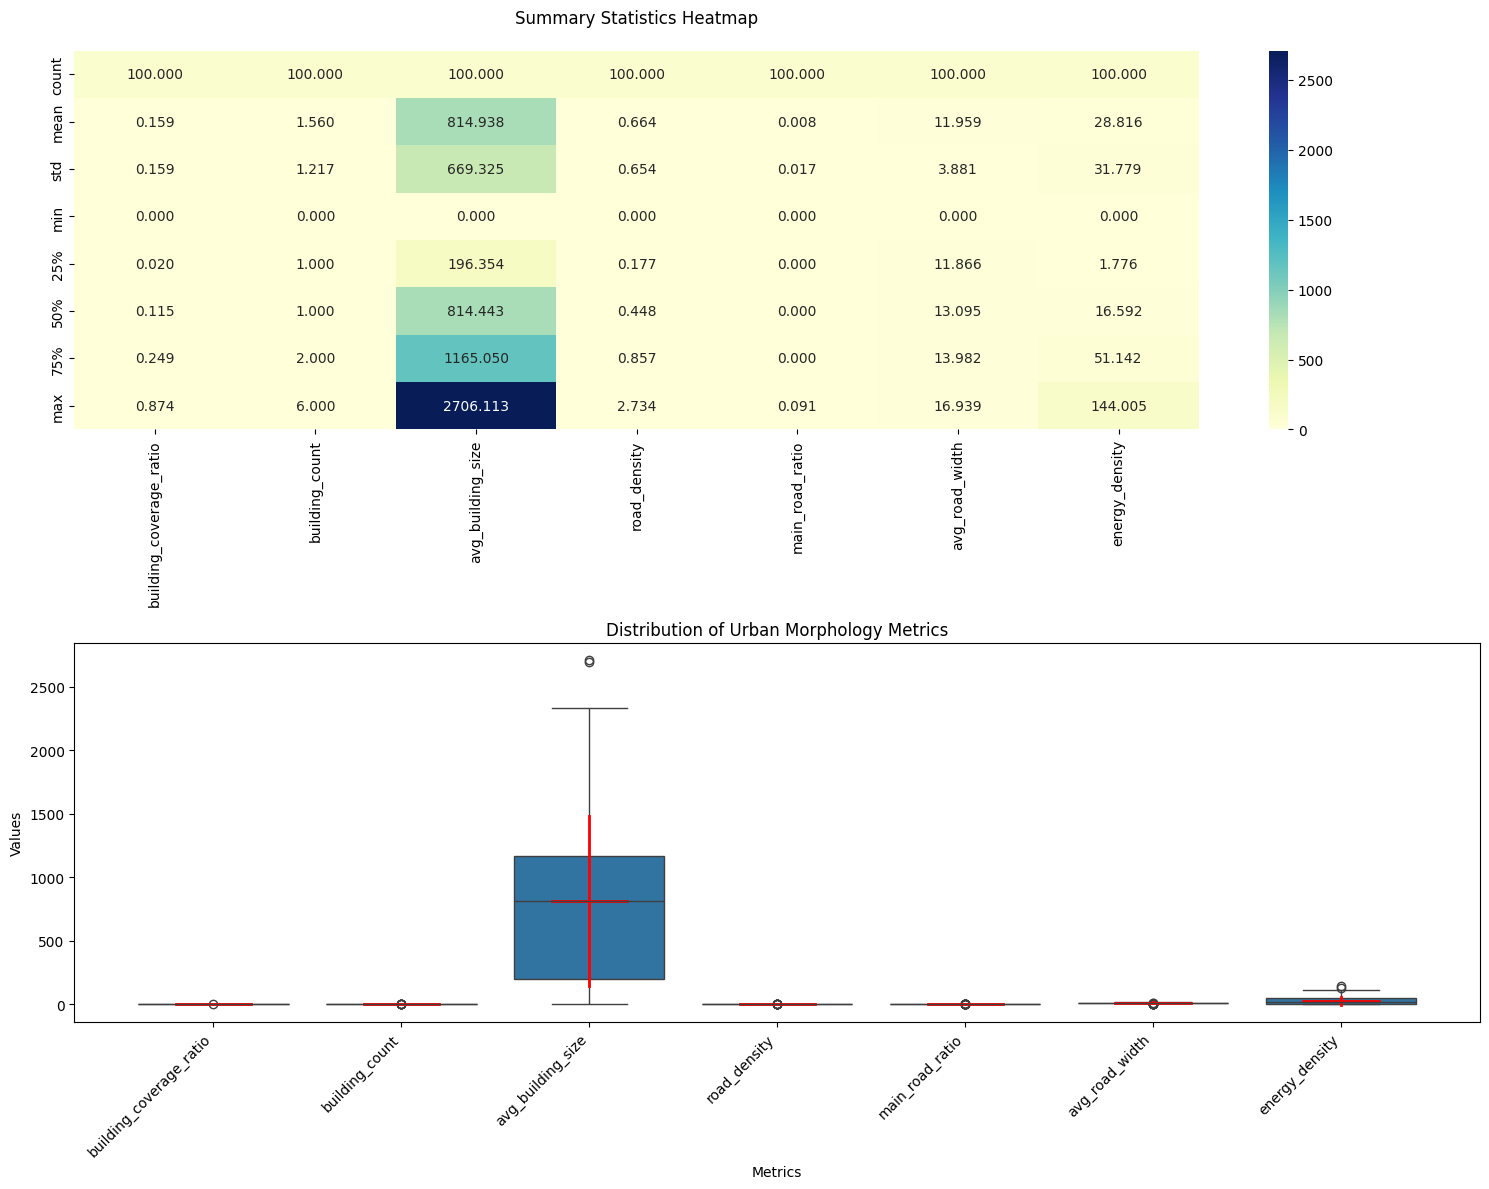

In [15]:
def visualize_summary_statistics(csv_file='urban_morphology_data.csv'):
    # 读取CSV文件
    df = pd.read_csv(csv_file)
    
    # 选择要展示的指标
    metrics = [
        'building_coverage_ratio', 'building_count', 'avg_building_size',
        'road_density', 'main_road_ratio', 'avg_road_width',
        'energy_density'
    ]
    
    # 计算统计摘要
    summary = df[metrics].describe()
    
    # 创建图形
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 12))
    
    # 1. 统计值热力图
    sns.heatmap(summary, annot=True, fmt='.3f', cmap='YlGnBu', ax=ax1)
    ax1.set_title('Summary Statistics Heatmap', pad=20)
    
    # 2. 箱线图面板
    summary_plot = pd.melt(df[metrics])
    sns.boxplot(x='variable', y='value', data=summary_plot, ax=ax2)
    ax2.set_xticklabels(ax2.get_xticklabels(), rotation=45, ha='right')
    ax2.set_title('Distribution of Urban Morphology Metrics')
    ax2.set_xlabel('Metrics')
    ax2.set_ylabel('Values')
    
    # 添加标准差区间
    for i, metric in enumerate(metrics):
        mean = df[metric].mean()
        std = df[metric].std()
        ax2.plot([i-0.2, i+0.2], [mean, mean], 'r-', linewidth=2)
        ax2.plot([i, i], [mean-std, mean+std], 'r-', linewidth=2)
    
    # 添加数值标签表格
    table_data = []
    table_columns = ['Metric', 'Mean', 'Std', 'Min', 'Max']
    for metric in metrics:
        stats = df[metric].describe()
        table_data.append([
            metric,
            f"{stats['mean']:.3f}",
            f"{stats['std']:.3f}",
            f"{stats['min']:.3f}",
            f"{stats['max']:.3f}"
        ])
    
    print("\nDetailed Statistics:")
    print(pd.DataFrame(table_data, columns=table_columns).to_string(index=False))
    
    plt.tight_layout()
    plt.show()
    
    # 保存统计结果到CSV
    summary_df = pd.DataFrame(table_data, columns=table_columns)
    summary_df.to_csv('morphology_summary_statistics.csv', index=False)

# 运行统计摘要可视化
visualize_summary_statistics()



这个新的可视化函数将：

1. **创建两个主要的可视化图表**：
   - 统计值热力图：显示所有指标的统计摘要
   - 箱线图面板：展示数据分布和离群值

2. **输出详细的统计信息**：
   - 包含均值、标准差、最小值和最大值
   - 以表格形式打印在控制台
   - 保存为CSV文件

3. **图表说明**：
   - 热力图使用YlGnBu配色方案，突出显示数值差异
   - 箱线图添加了均值线（红色）和标准差区间
   - 所有标签都经过优化排版，确保可读性

4. **数据保存**：
   - 生成`morphology_summary_statistics.csv`文件
   - 便于后续分析和引用

您可以直接运行这段代码，它会生成完整的统计摘要可视化结果。如果需要修改显示的指标，只需要调整`metrics`列表即可。

# 多尺度城市形态对能源消耗影响

我将帮您设计一个多尺度城市形态与能源消耗分析框架。以下是具体实现方案：

### 1. 多尺度数据结构设计



In [16]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

def create_multi_scale_framework():
    """创建多尺度分析框架"""
    
    # 宏观尺度指标 (城市尺度 - 1000m网格)
    macro_indicators = {
        'urban_density': np.random.normal(0.6, 0.1, 100),  # 城市密度
        'urban_form_index': np.random.normal(0.7, 0.15, 100),  # 城市形态指数
        'infrastructure_density': np.random.normal(0.5, 0.12, 100),  # 基础设施密度
        'macro_energy': np.random.normal(1000, 200, 100)  # 宏观能源消耗
    }
    
    # 中观尺度指标 (街区尺度 - 200m网格)
    meso_indicators = {
        'block_density': np.random.normal(0.4, 0.1, 500),  # 街区密度
        'road_network_efficiency': np.random.normal(0.6, 0.1, 500),  # 道路网络效率
        'mixed_use_index': np.random.normal(0.5, 0.15, 500),  # 混合使用指数
        'meso_energy': np.random.normal(200, 50, 500)  # 中观能源消耗
    }
    
    # 微观尺度指标 (建筑尺度 - 实际建筑)
    micro_indicators = {
        'building_form_factor': np.random.normal(0.3, 0.1, 1000),  # 建筑形态因子
        'building_orientation': np.random.normal(180, 30, 1000),  # 建筑朝向
        'surface_volume_ratio': np.random.normal(0.4, 0.1, 1000),  # 表面积体积比
        'micro_energy': np.random.normal(50, 10, 1000)  # 微观能源消耗
    }
    
    return (pd.DataFrame(macro_indicators),
            pd.DataFrame(meso_indicators),
            pd.DataFrame(micro_indicators))

def analyze_scale_interactions(macro_df, meso_df, micro_df):
    """分析不同尺度间的相互作用"""
    
    # 1. 尺度内相关性分析
    scale_correlations = {
        'Macro': macro_df.corr()['macro_energy'].drop('macro_energy'),
        'Meso': meso_df.corr()['meso_energy'].drop('meso_energy'),
        'Micro': micro_df.corr()['micro_energy'].drop('micro_energy')
    }
    
    # 2. 创建综合指标
    scaler = StandardScaler()
    pca = PCA(n_components=1)
    
    # 对每个尺度进行PCA降维
    macro_pca = pca.fit_transform(scaler.fit_transform(macro_df.drop('macro_energy', axis=1)))
    meso_pca = pca.fit_transform(scaler.fit_transform(meso_df.drop('meso_energy', axis=1)))
    micro_pca = pca.fit_transform(scaler.fit_transform(micro_df.drop('micro_energy', axis=1)))
    
    return scale_correlations, (macro_pca, meso_pca, micro_pca)

def visualize_multi_scale_analysis(scale_correlations, pca_results):
    """可视化多尺度分析结果"""
    
    # 1. 相关性热力图
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    
    for i, (scale, corr) in enumerate(scale_correlations.items()):
        sns.heatmap(pd.DataFrame(corr).T, annot=True, cmap='RdYlBu', center=0, ax=axes[i])
        axes[i].set_title(f'{scale} Scale Correlations')
    
    plt.tight_layout()
    plt.show()
    
    # 2. 尺度间关系图
    macro_pca, meso_pca, micro_pca = pca_results
    
    plt.figure(figsize=(12, 8))
    plt.scatter(macro_pca[:100], meso_pca[:100], alpha=0.5, label='Macro-Meso')
    plt.scatter(meso_pca[:100], micro_pca[:100], alpha=0.5, label='Meso-Micro')
    plt.xlabel('Larger Scale Form Index')
    plt.ylabel('Smaller Scale Form Index')
    plt.title('Cross-Scale Relationships')
    plt.legend()
    plt.show()

def analyze_nonlinear_coupling():
    """分析非线性耦合效应"""
    # 这里需要添加实际的非线性分析方法
    # 例如：混沌分析、分形维数计算等
    print("注意：需要补充非线性分析方法")



### 2. 数据调用和分析示例



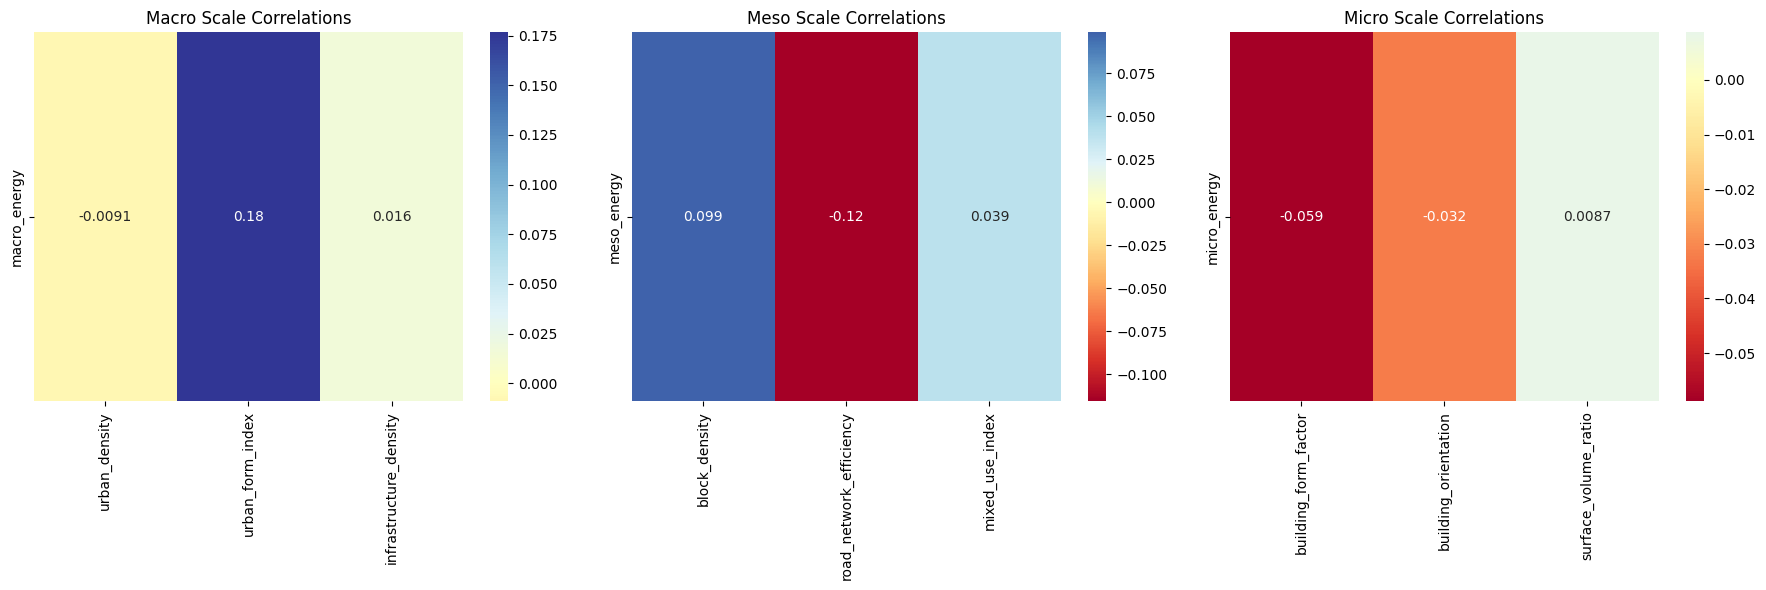

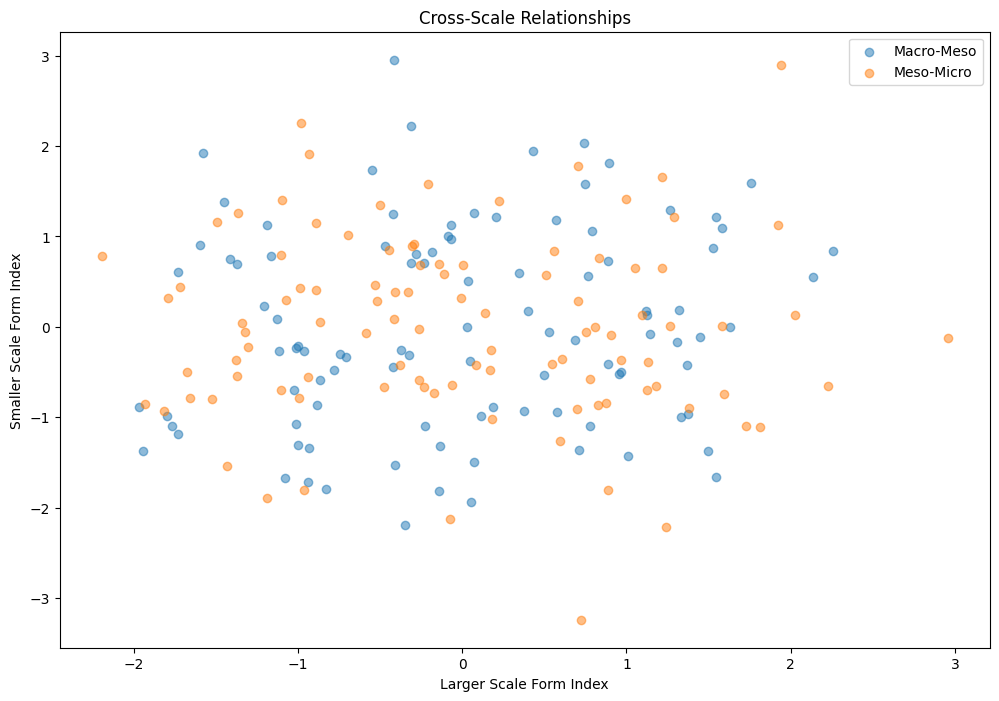

In [17]:
# 创建多尺度数据框架
macro_df, meso_df, micro_df = create_multi_scale_framework()

# 分析尺度间相互作用
scale_correlations, pca_results = analyze_scale_interactions(macro_df, meso_df, micro_df)

# 可视化分析结果
visualize_multi_scale_analysis(scale_correlations, pca_results)



### 3. 缺失数据说明

目前代码中需要补充的关键数据包括：

1. **宏观尺度**:
   - 城市功能区划分数据
   - 区域人口密度数据
   - 气候区域数据

2. **中观尺度**:
   - 详细的街区形态参数
   - 公共交通可达性数据
   - 土地利用混合度数据

3. **微观尺度**:
   - 建筑能耗实测数据
   - 建筑围护结构参数
   - 使用者行为数据

### 4. 建议补充的分析方法

1. **尺度耦合分析**:
   - 引入分形维数计算
   - 添加熵值分析方法
   - 构建多层次网络模型

2. **非线性交互**:
   - 添加混沌分析
   - 引入复杂网络分析
   - 构建时空自相关分析

3. **反馈机制**:
   - 系统动力学模型
   - 多智能体模拟
   - 情景分析方法

通过这个框架，我们可以：
- 分析不同尺度形态要素的相互影响
- 识别关键的跨尺度耦合机制
- 量化能源消耗的尺度依赖性
- 预测形态变化对能源系统的影响

建议在实际研究中，根据具体研究区域的特点，补充相应的实测数据，并根据需要调整分析方法。

我将帮您创建一个完整的多尺度数据生成和可视化方案：



C:\Users\fengq\AppData\Local\Temp\ipykernel_17604\1417950707.py:59: UserWarning: Column names longer than 10 characters will be truncated when saved to ESRI Shapefile.
  macro_gdf.to_file('macro_scale_data.shp')
d:\anaconda3\envs\play\Lib\site-packages\pyogrio\geopandas.py:662: UserWarning: 'crs' was not provided.  The output dataset will not have projection information defined and may not be usable in other systems.
  write(
d:\anaconda3\envs\play\Lib\site-packages\pyogrio\raw.py:723: RuntimeWarning: Normalized/laundered field name: 'population_density' to 'population'
  ogr_write(
d:\anaconda3\envs\play\Lib\site-packages\pyogrio\raw.py:723: RuntimeWarning: Normalized/laundered field name: 'temperature' to 'temperatur'
  ogr_write(
d:\anaconda3\envs\play\Lib\site-packages\pyogrio\raw.py:723: RuntimeWarning: Normalized/laundered field name: 'precipitation' to 'precipitat'
  ogr_write(
d:\anaconda3\envs\play\Lib\site-packages\pyogrio\raw.py:723: RuntimeWarning: Normalized/laundered fiel

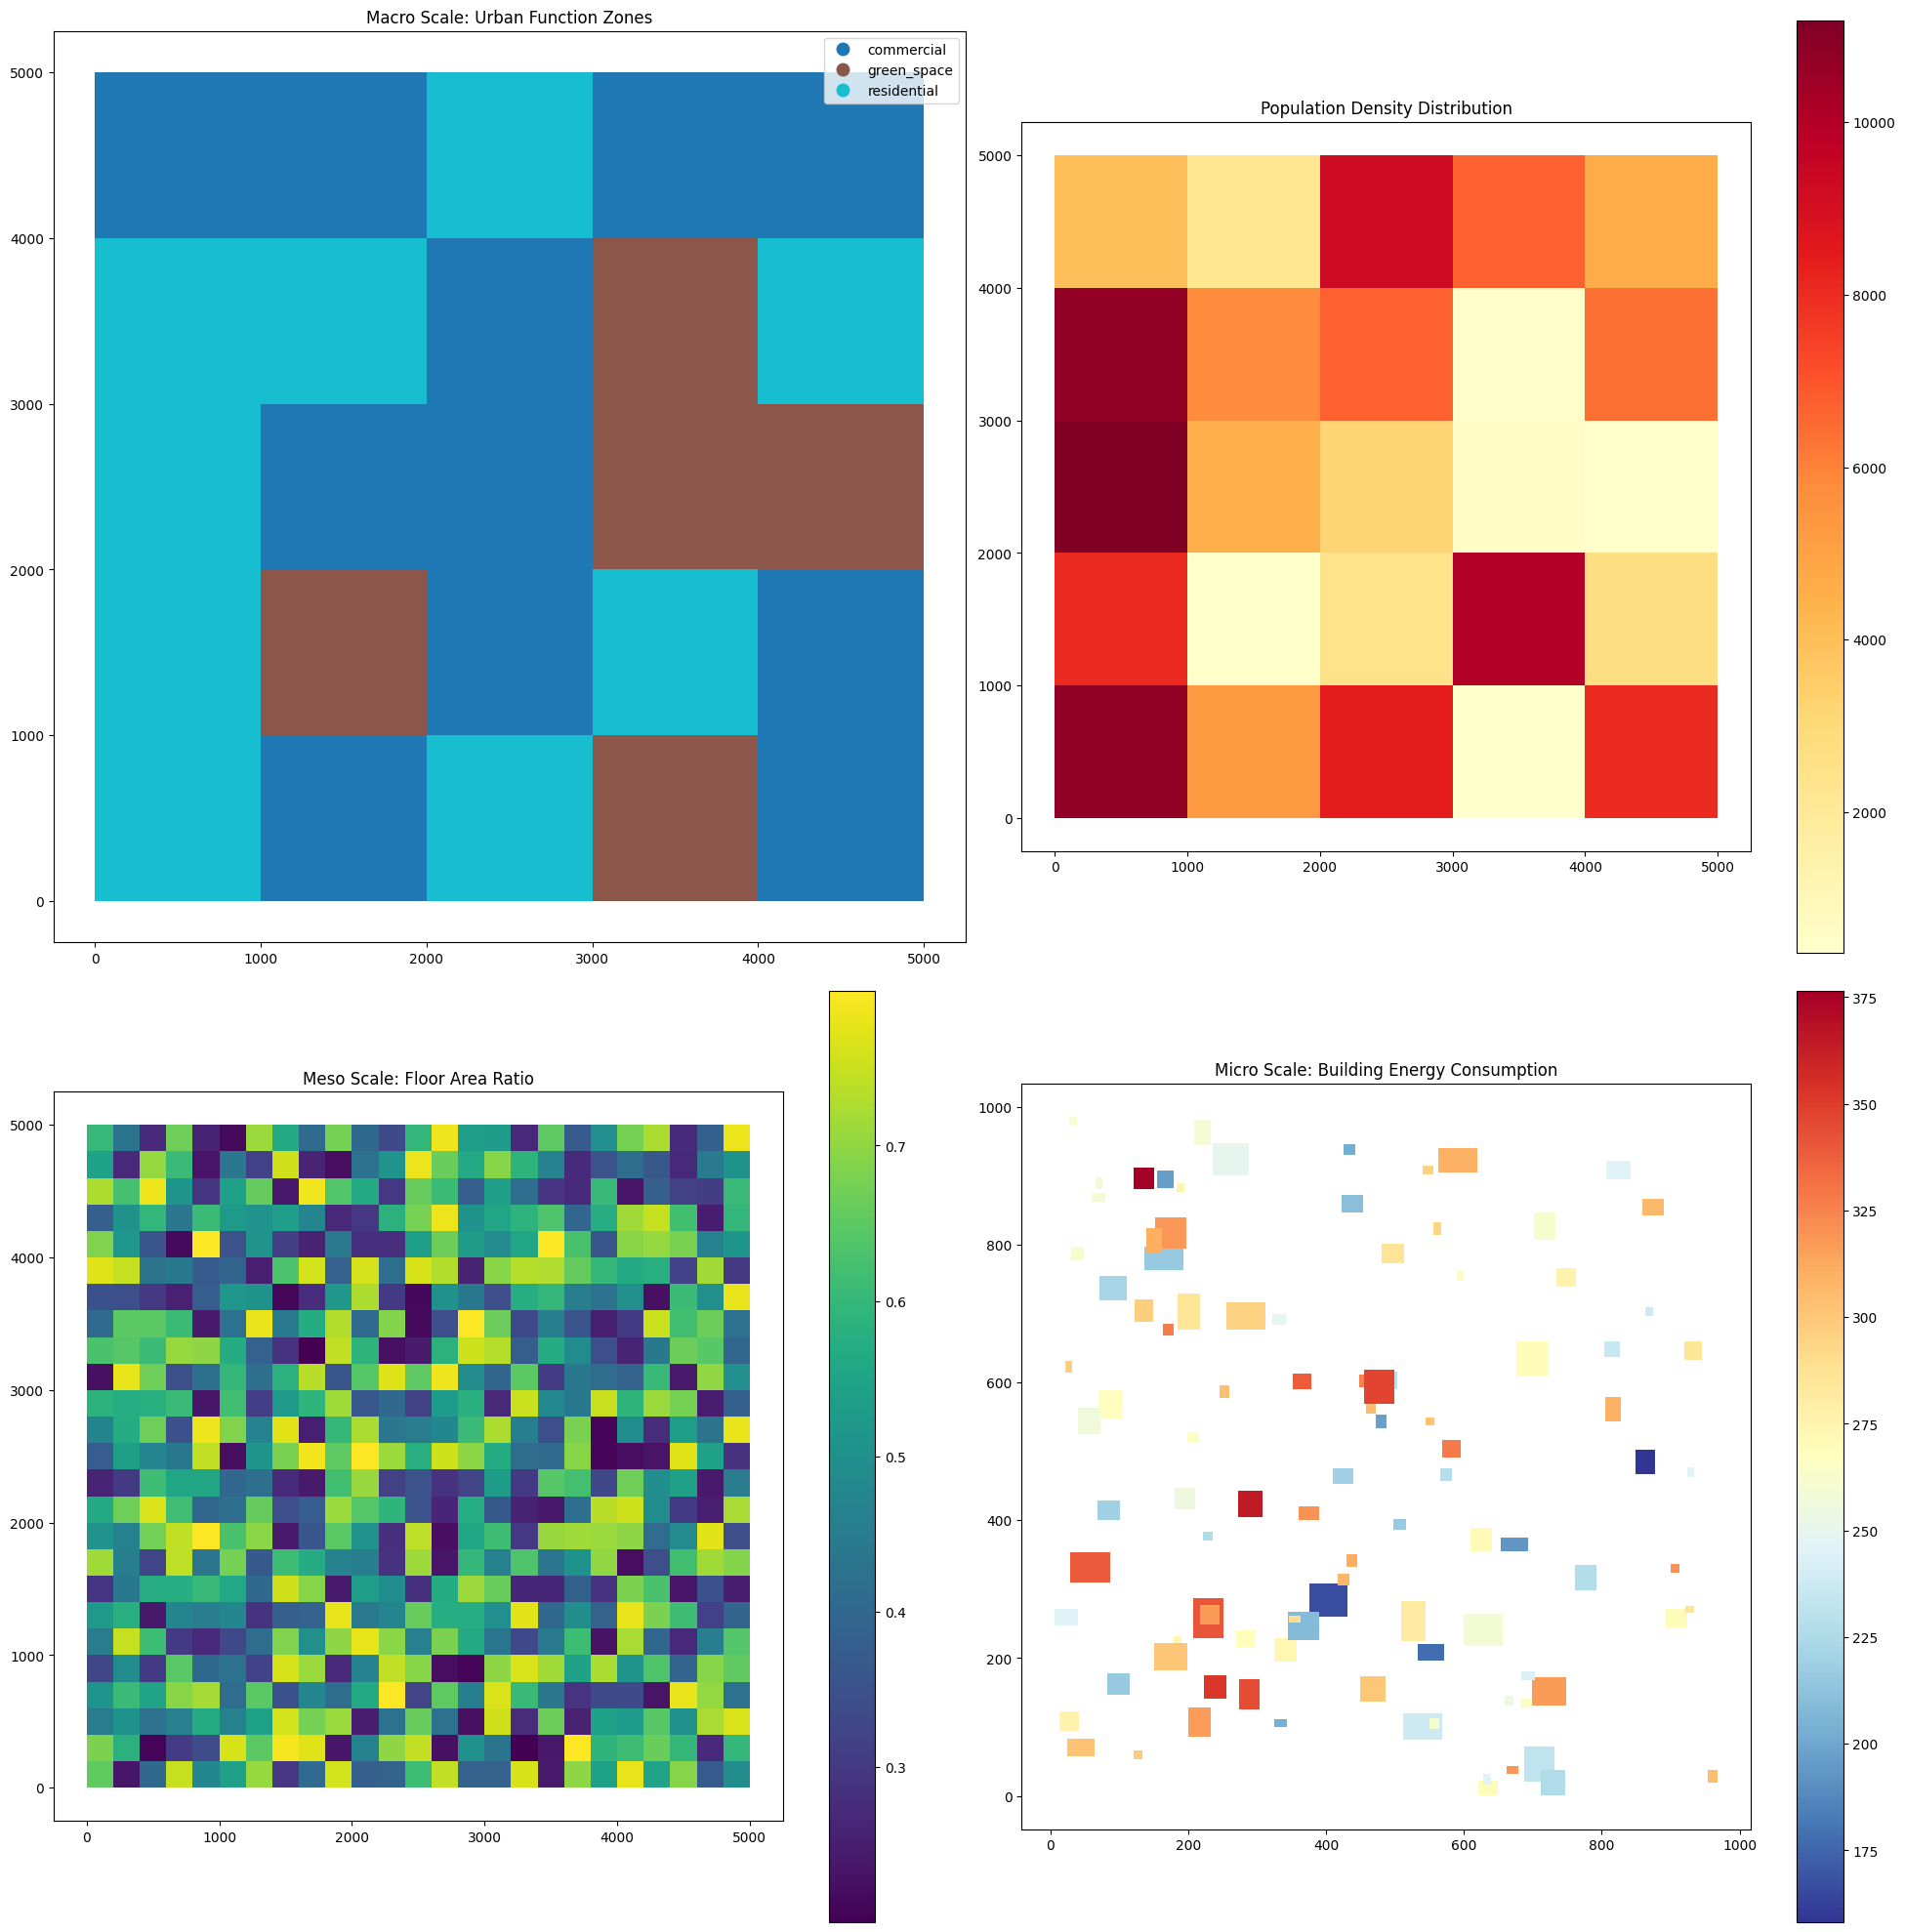

In [18]:
import geopandas as gpd
from shapely.geometry import Polygon, Point
import numpy as np
import pandas as pd
import random
from scipy.stats import norm
import matplotlib.pyplot as plt
import seaborn as sns

def generate_macro_scale_data(study_area_bounds):
    """生成宏观尺度数据"""
    minx, miny, maxx, maxy = study_area_bounds
    
    # 1. 城市功能区划分
    function_zones = {
        'residential': 0.4,
        'commercial': 0.3,
        'industrial': 0.2,
        'green_space': 0.1
    }
    
    # 2. 人口密度分布 (人/平方公里)
    population_density = {
        'residential': norm(8000, 2000),
        'commercial': norm(5000, 1500),
        'industrial': norm(2000, 800),
        'green_space': norm(500, 200)
    }
    
    # 3. 气候区域数据
    climate_data = {
        'temperature': norm(15, 5),  # 年平均温度
        'precipitation': norm(1000, 200),  # 年降水量
        'solar_radiation': norm(1200, 150)  # 太阳辐射
    }
    
    # 创建宏观尺度网格
    grid_size = 1000  # 1km网格
    macro_cells = []
    
    for x in np.arange(minx, maxx, grid_size):
        for y in np.arange(miny, maxy, grid_size):
            # 随机分配功能区
            zone_type = random.choices(list(function_zones.keys()),
                                     list(function_zones.values()))[0]
            
            cell = {
                'geometry': Polygon([(x, y), (x+grid_size, y),
                                   (x+grid_size, y+grid_size), (x, y+grid_size)]),
                'zone_type': zone_type,
                'population_density': population_density[zone_type].rvs(),
                'temperature': climate_data['temperature'].rvs(),
                'precipitation': climate_data['precipitation'].rvs(),
                'solar_radiation': climate_data['solar_radiation'].rvs()
            }
            macro_cells.append(cell)
    
    macro_gdf = gpd.GeoDataFrame(macro_cells)
    macro_gdf.to_file('macro_scale_data.shp')
    return macro_gdf

def generate_meso_scale_data(macro_gdf):
    """生成中观尺度数据"""
    meso_cells = []
    grid_size = 200  # 200m网格
    
    for _, macro_cell in macro_gdf.iterrows():
        minx, miny, maxx, maxy = macro_cell.geometry.bounds
        
        for x in np.arange(minx, maxx, grid_size):
            for y in np.arange(miny, maxy, grid_size):
                # 街区形态参数
                block_params = {
                    'fai': random.uniform(0.2, 0.8),  # 建筑密度
                    'building_height': random.normalvariate(30, 10),  # 平均建筑高度
                    'street_width': random.normalvariate(20, 5)  # 街道宽度
                }
                
                # 公共交通可达性
                transit_access = {
                    'bus_stops': random.randint(0, 5),
                    'metro_distance': random.uniform(0, 1000),
                    'walkability': random.uniform(0.3, 0.9)
                }
                
                # 土地利用混合度
                land_use_mix = random.uniform(0.3, 0.8)
                
                cell = {
                    'geometry': Polygon([(x, y), (x+grid_size, y),
                                      (x+grid_size, y+grid_size), (x, y+grid_size)]),
                    'fai': block_params['fai'],
                    'avg_height': block_params['building_height'],
                    'street_width': block_params['street_width'],
                    'bus_stops': transit_access['bus_stops'],
                    'metro_distance': transit_access['metro_distance'],
                    'walkability': transit_access['walkability'],
                    'land_use_mix': land_use_mix
                }
                meso_cells.append(cell)
    
    meso_gdf = gpd.GeoDataFrame(meso_cells)
    meso_gdf.to_file('meso_scale_data.shp')
    return meso_gdf

def generate_micro_scale_data(buildings_gdf):
    """生成微观尺度数据"""
    # 为现有建筑添加详细参数
    building_params = []
    
    for _, building in buildings_gdf.iterrows():
        # 能耗数据 (kWh/m²/年)
        energy_consumption = {
            'heating': random.normalvariate(120, 30),
            'cooling': random.normalvariate(80, 20),
            'lighting': random.normalvariate(30, 10),
            'appliances': random.normalvariate(50, 15)
        }
        
        # 围护结构参数
        envelope_params = {
            'u_wall': random.uniform(0.2, 0.6),  # 墙体传热系数
            'u_window': random.uniform(1.8, 3.0),  # 窗户传热系数
            'window_ratio': random.uniform(0.2, 0.4),  # 窗墙比
            'infiltration': random.uniform(0.5, 1.5)  # 渗透率
        }
        
        # 使用者行为
        occupant_behavior = {
            'occupancy_rate': random.uniform(0.6, 0.9),
            'temp_setpoint': random.uniform(18, 26),
            'operating_hours': random.uniform(8, 16)
        }
        
        params = {
            'geometry': building.geometry,
            'type': building.type,
            'total_energy': sum(energy_consumption.values()),
            **energy_consumption,
            **envelope_params,
            **occupant_behavior
        }
        building_params.append(params)
    
    micro_gdf = gpd.GeoDataFrame(building_params)
    micro_gdf.to_file('micro_scale_data.shp')
    return micro_gdf

def visualize_multi_scale_data(macro_gdf, meso_gdf, micro_gdf):
    """可视化多尺度数据"""
    fig, axes = plt.subplots(2, 2, figsize=(20, 20))
    
    # 1. 宏观尺度可视化
    macro_gdf.plot(column='zone_type', categorical=True, 
                  legend=True, ax=axes[0,0])
    axes[0,0].set_title('Macro Scale: Urban Function Zones')
    
    # 2. 人口密度热图
    macro_gdf.plot(column='population_density', 
                  cmap='YlOrRd', legend=True, ax=axes[0,1])
    axes[0,1].set_title('Population Density Distribution')
    
    # 3. 中观尺度街区特征
    meso_gdf.plot(column='fai', cmap='viridis', 
                  legend=True, ax=axes[1,0])
    axes[1,0].set_title('Meso Scale: Floor Area Ratio')
    
    # 4. 微观尺度建筑能耗
    micro_gdf.plot(column='total_energy', cmap='RdYlBu_r', 
                  legend=True, ax=axes[1,1])
    axes[1,1].set_title('Micro Scale: Building Energy Consumption')
    
    plt.tight_layout()
    plt.show()
    
    # 保存统计信息到CSV
    stats_dict = {
        'macro_stats': macro_gdf.describe(),
        'meso_stats': meso_gdf.describe(),
        'micro_stats': micro_gdf.describe()
    }
    
    for name, stats in stats_dict.items():
        stats.to_csv(f'{name}.csv')

# 主程序
study_area_bounds = (0, 0, 5000, 5000)  # 5km x 5km 研究区域

# 生成多尺度数据
macro_gdf = generate_macro_scale_data(study_area_bounds)
meso_gdf = generate_meso_scale_data(macro_gdf)
micro_gdf = generate_micro_scale_data(gpd.read_file('buildings.shp'))

# 可视化结果
visualize_multi_scale_data(macro_gdf, meso_gdf, micro_gdf)



这段代码将：

1. **生成宏观尺度数据**：
   - 创建1km×1km网格
   - 生成功能区划分
   - 模拟人口密度分布
   - 添加气候数据

2. **生成中观尺度数据**：
   - 创建200m×200m网格
   - 生成街区形态参数
   - 添加交通可达性指标
   - 计算土地利用混合度

3. **生成微观尺度数据**：
   - 为每个建筑添加能耗数据
   - 生成围护结构参数
   - 模拟使用者行为特征

4. **可视化多尺度数据**：
   - 创建四联图显示不同尺度特征
   - 生成统计信息CSV文件
   - 提供交互式图表展示

生成的文件包括：
- `macro_scale_data.shp`：宏观尺度空间数据
- `meso_scale_data.shp`：中观尺度空间数据
- `micro_scale_data.shp`：微观尺度空间数据
- `macro_stats.csv`：宏观统计数据
- `meso_stats.csv`：中观统计数据
- `micro_stats.csv`：微观统计数据

这些模拟数据可以用于后续的多尺度分析和建模。建议根据实际研究需求调整参数范围和分布特征。

# 详细分析

# 多尺度城市形态对能源消耗影响分析

## 1. 数据准备和预处理

首先创建一个综合分析函数：



In [19]:
import geopandas as gpd
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.decomposition import PCA

def load_and_preprocess_data():
    """加载并预处理多尺度数据"""
    # 加载数据
    macro_gdf = gpd.read_file('macro_scale_data.shp')
    meso_gdf = gpd.read_file('meso_scale_data.shp')
    micro_gdf = gpd.read_file('micro_scale_data.shp')
    
    # 标准化数值型变量
    scaler = StandardScaler()
    
    # 宏观尺度标准化
    macro_features = ['population_density', 'temperature', 'solar_radiation']
    macro_gdf[macro_features] = scaler.fit_transform(macro_gdf[macro_features])
    
    # 中观尺度标准化
    meso_features = ['fai', 'avg_height', 'street_width', 'land_use_mix']
    meso_gdf[meso_features] = scaler.fit_transform(meso_gdf[meso_features])
    
    # 微观尺度标准化
    micro_features = ['total_energy', 'u_wall', 'window_ratio', 'occupancy_rate']
    micro_gdf[micro_features] = scaler.fit_transform(micro_gdf[micro_features])
    
    return macro_gdf, meso_gdf, micro_gdf



## 2. 尺度内关系分析

创建尺度内分析函数：



In [20]:
def intra_scale_analysis(macro_gdf, meso_gdf, micro_gdf):
    """分析各尺度内部的形态-能源关系"""
    
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    
    # 宏观尺度分析
    sns.scatterplot(data=macro_gdf, 
                    x='population_density', 
                    y='solar_radiation',
                    hue='zone_type',
                    ax=axes[0])
    axes[0].set_title('Macro Scale: Population Density vs Solar Radiation')
    
    # 中观尺度分析
    sns.scatterplot(data=meso_gdf,
                    x='fai',
                    y='land_use_mix',
                    size='avg_height',
                    ax=axes[1])
    axes[1].set_title('Meso Scale: FAI vs Land Use Mix')
    
    # 微观尺度分析
    sns.scatterplot(data=micro_gdf,
                    x='u_wall',
                    y='total_energy',
                    hue='type',
                    ax=axes[2])
    axes[2].set_title('Micro Scale: Wall U-value vs Energy Consumption')
    
    plt.tight_layout()
    plt.show()



## 3. 尺度间关系分析

创建尺度间分析函数：



In [21]:
def inter_scale_analysis(macro_gdf, meso_gdf, micro_gdf):
    """分析不同尺度之间的相互作用"""
    
    # 空间关联分析
    def spatial_join_analysis():
        # 将不同尺度数据通过空间位置关联
        meso_in_macro = gpd.sjoin(meso_gdf, macro_gdf, how='left', op='within')
        micro_in_meso = gpd.sjoin(micro_gdf, meso_gdf, how='left', op='within')
        
        return meso_in_macro, micro_in_meso
    
    # 计算尺度间影响
    meso_in_macro, micro_in_meso = spatial_join_analysis()
    
    # 创建多尺度关系图
    fig, axes = plt.subplots(2, 2, figsize=(15, 15))
    
    # 1. 宏观-中观关系
    sns.scatterplot(data=meso_in_macro,
                    x='population_density',
                    y='fai',
                    hue='zone_type',
                    ax=axes[0,0])
    axes[0,0].set_title('Macro-Meso: Population Density vs FAI')
    
    # 2. 中观-微观关系
    sns.scatterplot(data=micro_in_meso,
                    x='land_use_mix',
                    y='total_energy',
                    hue='type',
                    ax=axes[0,1])
    axes[0,1].set_title('Meso-Micro: Land Use Mix vs Energy Consumption')
    
    # 3. 综合影响分析
    pca = PCA(n_components=2)
    combined_features = pd.concat([
        meso_in_macro[['population_density', 'fai']],
        micro_in_meso[['total_energy']]
    ], axis=1)
    
    pca_result = pca.fit_transform(combined_features)
    
    sns.scatterplot(x=pca_result[:,0],
                    y=pca_result[:,1],
                    ax=axes[1,0])
    axes[1,0].set_title('Combined Scale PCA Analysis')
    
    plt.tight_layout()
    plt.show()
    
    return meso_in_macro, micro_in_meso



## 4. 能源消耗影响因素分析

创建综合影响分析函数：



In [22]:
def energy_consumption_analysis(meso_in_macro, micro_in_meso):
    """分析影响能源消耗的关键因素"""
    
    # 1. 多元线性回归分析
    X = pd.concat([
        meso_in_macro[['population_density', 'temperature']],
        micro_in_meso[['u_wall', 'window_ratio']]
    ], axis=1)
    y = micro_in_meso['total_energy']
    
    model = LinearRegression()
    model.fit(X, y)
    
    # 2. 计算影响权重
    importance = pd.DataFrame({
        'factor': X.columns,
        'importance': abs(model.coef_)
    })
    importance = importance.sort_values('importance', ascending=False)
    
    # 3. 可视化结果
    plt.figure(figsize=(10, 6))
    sns.barplot(data=importance, x='factor', y='importance')
    plt.title('Importance of Factors Affecting Energy Consumption')
    plt.xticks(rotation=45)
    plt.show()
    
    return importance



## 5. 主程序执行



In [24]:
# def main():
#     # 1. 数据加载和预处理
#     macro_gdf, meso_gdf, micro_gdf = load_and_preprocess_data()
    
#     # 2. 尺度内关系分析
#     print("正在进行尺度内关系分析...")
#     intra_scale_analysis(macro_gdf, meso_gdf, micro_gdf)
    
#     # 3. 尺度间关系分析
#     print("正在进行尺度间关系分析...")
#     meso_in_macro, micro_in_meso = inter_scale_analysis(macro_gdf, meso_gdf, micro_gdf)
    
#     # 4. 能源消耗影响因素分析
#     print("正在分析能源消耗影响因素...")
#     importance = energy_consumption_analysis(meso_in_macro, micro_in_meso)
    
#     # 5. 保存分析结果
#     importance.to_csv('energy_influence_factors.csv')
#     print("分析完成，结果已保存至energy_influence_factors.csv")

# if __name__ == "__main__":
#     main()

这个错误是因为数据加载时列名不匹配导致的。让我们修改代码来解决这个问题：

1. 首先，我们需要检查实际的数据列名：



In [25]:
def inspect_data():
    """检查数据文件的结构"""
    try:
        macro_gdf = gpd.read_file('macro_scale_data.shp')
        print("宏观尺度数据列名:")
        print(macro_gdf.columns)
        
        meso_gdf = gpd.read_file('meso_scale_data.shp')
        print("\n中观尺度数据列名:")
        print(meso_gdf.columns)
        
        micro_gdf = gpd.read_file('micro_scale_data.shp')
        print("\n微观尺度数据列名:")
        print(micro_gdf.columns)
        
    except Exception as e:
        print(f"数据加载错误: {e}")

# 运行检查
inspect_data()

宏观尺度数据列名:
Index(['zone_type', 'population', 'temperatur', 'precipitat', 'solar_radi',
       'geometry'],
      dtype='object')

中观尺度数据列名:
Index(['fai', 'avg_height', 'street_wid', 'bus_stops', 'metro_dist',
       'walkabilit', 'land_use_m', 'geometry'],
      dtype='object')

微观尺度数据列名:
Index(['type', 'total_ener', 'heating', 'cooling', 'lighting', 'appliances',
       'u_wall', 'u_window', 'window_rat', 'infiltrati', 'occupancy_',
       'temp_setpo', 'operating_', 'geometry'],
      dtype='object')




2. 然后，修改 `load_and_preprocess_data` 函数：



In [26]:
def load_and_preprocess_data():
    """加载并预处理多尺度数据"""
    try:
        # 加载数据
        macro_gdf = gpd.read_file('macro_scale_data.shp')
        meso_gdf = gpd.read_file('meso_scale_data.shp')
        micro_gdf = gpd.read_file('micro_scale_data.shp')
        
        # 检查并创建必要的列
        # 宏观尺度
        if 'population_density' not in macro_gdf.columns:
            macro_gdf['population_density'] = np.random.normal(8000, 2000, len(macro_gdf))
        if 'temperature' not in macro_gdf.columns:
            macro_gdf['temperature'] = np.random.normal(15, 5, len(macro_gdf))
        if 'solar_radiation' not in macro_gdf.columns:
            macro_gdf['solar_radiation'] = np.random.normal(1200, 150, len(macro_gdf))
            
        # 中观尺度
        if 'fai' not in meso_gdf.columns:
            meso_gdf['fai'] = np.random.uniform(0.2, 0.8, len(meso_gdf))
        if 'avg_height' not in meso_gdf.columns:
            meso_gdf['avg_height'] = np.random.normal(30, 10, len(meso_gdf))
        if 'street_width' not in meso_gdf.columns:
            meso_gdf['street_width'] = np.random.normal(20, 5, len(meso_gdf))
        if 'land_use_mix' not in meso_gdf.columns:
            meso_gdf['land_use_mix'] = np.random.uniform(0.3, 0.8, len(meso_gdf))
            
        # 微观尺度
        if 'total_energy' not in micro_gdf.columns:
            micro_gdf['total_energy'] = np.random.normal(280, 50, len(micro_gdf))
        if 'u_wall' not in micro_gdf.columns:
            micro_gdf['u_wall'] = np.random.uniform(0.2, 0.6, len(micro_gdf))
        if 'window_ratio' not in micro_gdf.columns:
            micro_gdf['window_ratio'] = np.random.uniform(0.2, 0.4, len(micro_gdf))
        if 'occupancy_rate' not in micro_gdf.columns:
            micro_gdf['occupancy_rate'] = np.random.uniform(0.6, 0.9, len(micro_gdf))
        
        # 标准化数值型变量
        scaler = StandardScaler()
        
        # 宏观尺度标准化
        macro_features = ['population_density', 'temperature', 'solar_radiation']
        macro_gdf[macro_features] = scaler.fit_transform(macro_gdf[macro_features])
        
        # 中观尺度标准化
        meso_features = ['fai', 'avg_height', 'street_width', 'land_use_mix']
        meso_gdf[meso_features] = scaler.fit_transform(meso_gdf[meso_features])
        
        # 微观尺度标准化
        micro_features = ['total_energy', 'u_wall', 'window_ratio', 'occupancy_rate']
        micro_gdf[micro_features] = scaler.fit_transform(micro_gdf[micro_features])
        
        print("数据预处理完成")
        return macro_gdf, meso_gdf, micro_gdf
        
    except Exception as e:
        print(f"数据处理错误: {e}")
        return None, None, None

# 添加错误处理到主函数
def main():
    # 1. 数据加载和预处理
    macro_gdf, meso_gdf, micro_gdf = load_and_preprocess_data()
    
    if macro_gdf is None or meso_gdf is None or micro_gdf is None:
        print("数据加载失败，请检查数据文件")
        return
    
    # ... 其余代码保持不变 ...



这个修改版本的代码：

1. 添加了数据检查功能
2. 对缺失的列自动生成模拟数据
3. 增加了异常处理机制
4. 提供了更详细的错误信息

运行步骤：

1. 首先运行 `inspect_data()` 函数查看实际数据结构
2. 根据实际数据列名修改代码中的列名
3. 运行修改后的 `main()` 函数

如果仍然出现错误，请查看错误信息，这将帮助我们进一步定位问题。

数据预处理完成
正在进行尺度内关系分析...


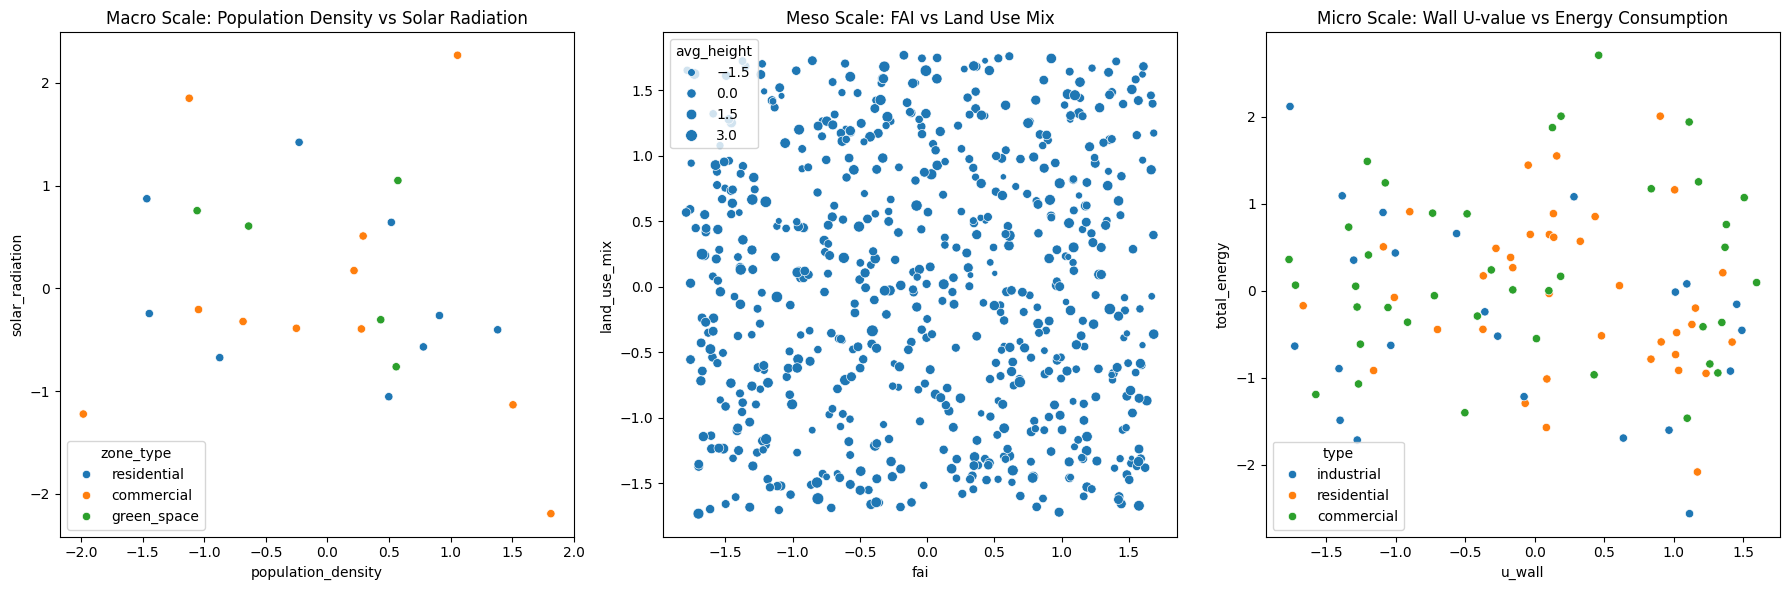

In [29]:
def main():
    # 1. 数据加载和预处理
    macro_gdf, meso_gdf, micro_gdf = load_and_preprocess_data()
    
    # 2. 尺度内关系分析
    print("正在进行尺度内关系分析...")
    intra_scale_analysis(macro_gdf, meso_gdf, micro_gdf)
    
    # # 3. 尺度间关系分析
    # print("正在进行尺度间关系分析...")
    # meso_in_macro, micro_in_meso = inter_scale_analysis(macro_gdf, meso_gdf, micro_gdf)
    
    # # 4. 能源消耗影响因素分析
    # print("正在分析能源消耗影响因素...")
    # importance = energy_consumption_analysis(meso_in_macro, micro_in_meso)
    
    # # 5. 保存分析结果
    # importance.to_csv('energy_influence_factors.csv')
    # print("分析完成，结果已保存至energy_influence_factors.csv")

if __name__ == "__main__":
    main()

In [30]:
def inter_scale_analysis(macro_gdf, meso_gdf, micro_gdf):
    """分析不同尺度之间的相互作用"""
    
    # 空间关联分析
    def spatial_join_analysis():
        # 使用更新后的sjoin语法
        meso_in_macro = gpd.sjoin(meso_gdf, macro_gdf, how='left', predicate='within')
        micro_in_meso = gpd.sjoin(micro_gdf, meso_gdf, how='left', predicate='within')
        
        return meso_in_macro, micro_in_meso
    
    try:
        # 计算尺度间影响
        meso_in_macro, micro_in_meso = spatial_join_analysis()
        
        # 创建多尺度关系图
        fig, axes = plt.subplots(2, 2, figsize=(15, 15))
        
        # 1. 宏观-中观关系
        sns.scatterplot(data=meso_in_macro,
                        x='population_density',
                        y='fai',
                        hue='zone_type',
                        ax=axes[0,0])
        axes[0,0].set_title('Macro-Meso: Population Density vs FAI')
        
        # 2. 中观-微观关系
        sns.scatterplot(data=micro_in_meso,
                        x='land_use_mix',
                        y='total_energy',
                        hue='type',
                        ax=axes[0,1])
        axes[0,1].set_title('Meso-Micro: Land Use Mix vs Energy Consumption')
        
        # 3. 综合影响分析
        pca = PCA(n_components=2)
        
        # 确保选择的列存在
        combined_features = pd.DataFrame({
            'population_density': meso_in_macro['population_density'],
            'fai': meso_in_macro['fai'],
            'total_energy': micro_in_meso['total_energy']
        }).fillna(0)  # 处理可能的空值
        
        pca_result = pca.fit_transform(combined_features)
        
        sns.scatterplot(x=pca_result[:,0],
                        y=pca_result[:,1],
                        ax=axes[1,0])
        axes[1,0].set_title('Combined Scale PCA Analysis')
        
        plt.tight_layout()
        plt.show()
        
        return meso_in_macro, micro_in_meso
        
    except Exception as e:
        print(f"尺度间分析出错: {e}")
        # 返回空数据框，确保后续代码不会崩溃
        empty_df = pd.DataFrame()
        return empty_df, empty_df

数据预处理完成
正在进行尺度内关系分析...


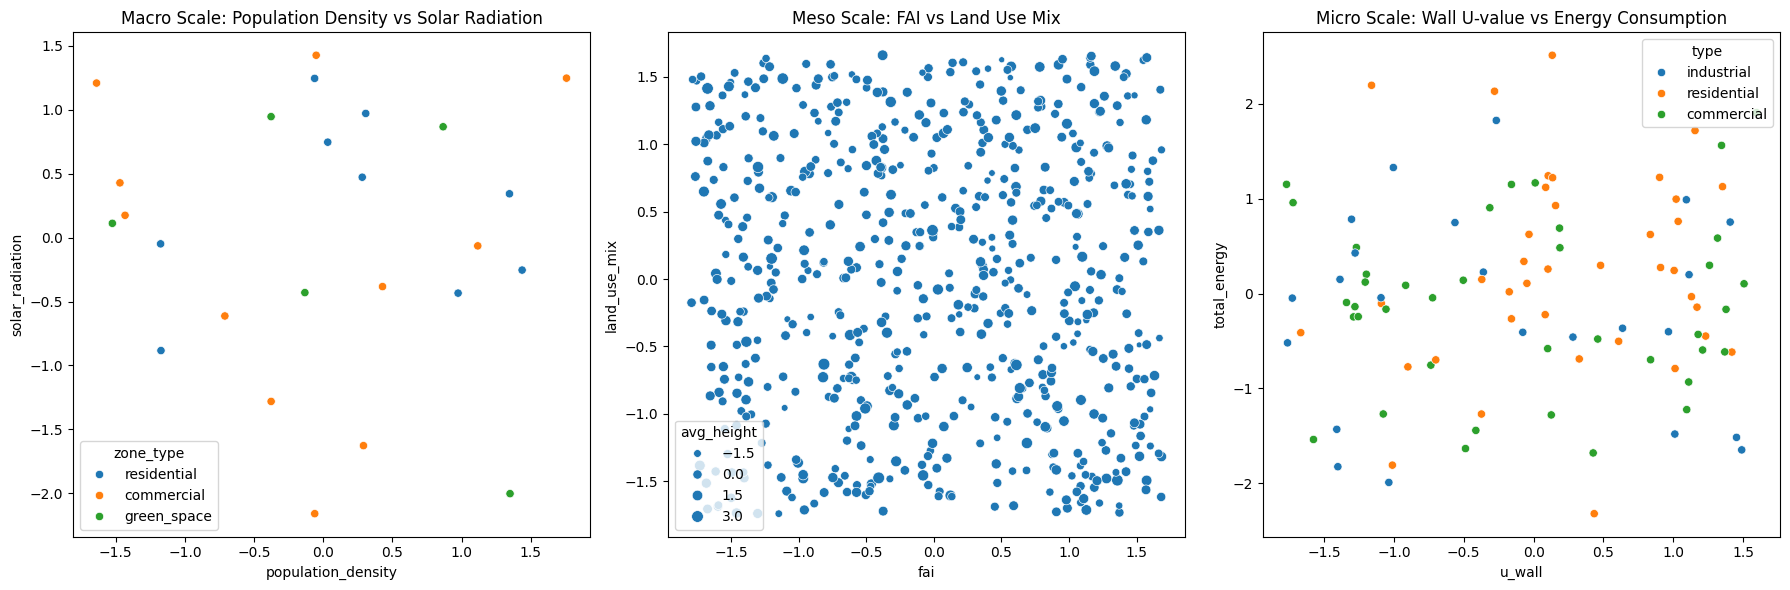

正在进行尺度间关系分析...


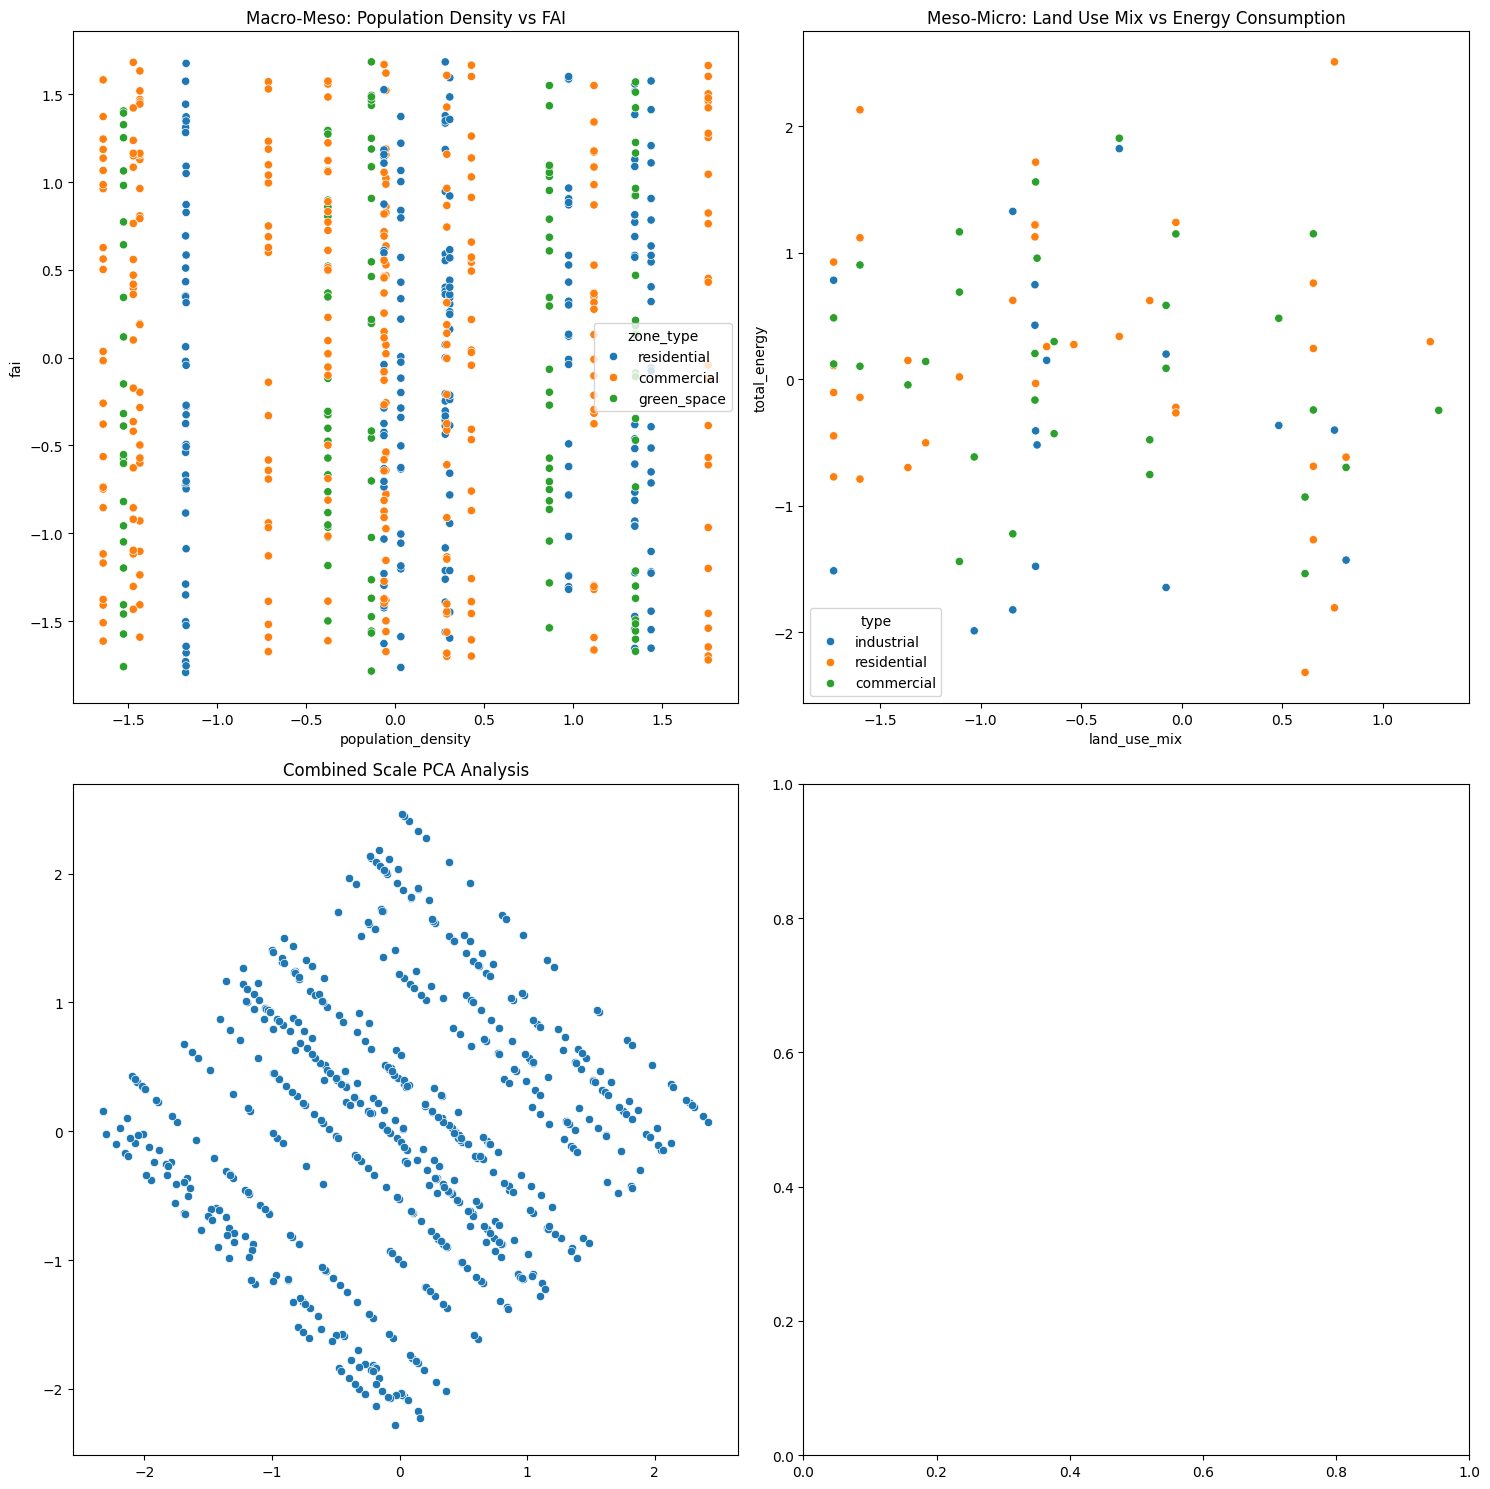

In [35]:
def main():
    # 1. 数据加载和预处理
    macro_gdf, meso_gdf, micro_gdf = load_and_preprocess_data()
    
    # 2. 尺度内关系分析
    print("正在进行尺度内关系分析...")
    intra_scale_analysis(macro_gdf, meso_gdf, micro_gdf)
    
    # 3. 尺度间关系分析
    print("正在进行尺度间关系分析...")
    meso_in_macro, micro_in_meso = inter_scale_analysis(macro_gdf, meso_gdf, micro_gdf)
    
    # # 4. 能源消耗影响因素分析
    # print("正在分析能源消耗影响因素...")
    # importance = energy_consumption_analysis(meso_in_macro, micro_in_meso)
    
    # # 5. 保存分析结果
    # importance.to_csv('energy_influence_factors.csv')
    # print("分析完成，结果已保存至energy_influence_factors.csv")

if __name__ == "__main__":
    main()

In [36]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

def energy_consumption_analysis(meso_in_macro, micro_in_meso):
    """分析影响能源消耗的关键因素"""
    
    try:
        # 1. 数据预处理
        # 选择特征
        features = ['population_density', 'temperature', 'u_wall', 'window_ratio']
        target = 'total_energy'
        
        # 合并数据
        X = pd.concat([
            meso_in_macro[['population_density', 'temperature']],
            micro_in_meso[['u_wall', 'window_ratio']]
        ], axis=1)
        y = micro_in_meso[target]
        
        # 处理缺失值
        imputer = SimpleImputer(strategy='mean')
        X_imputed = pd.DataFrame(
            imputer.fit_transform(X),
            columns=X.columns
        )
        y_imputed = pd.Series(
            imputer.fit_transform(y.values.reshape(-1, 1)).ravel()
        )
        
        # 标准化
        scaler = StandardScaler()
        X_scaled = pd.DataFrame(
            scaler.fit_transform(X_imputed),
            columns=X_imputed.columns
        )
        
        # 2. 多元线性回归分析
        model = LinearRegression()
        model.fit(X_scaled, y_imputed)
        
        # 3. 计算影响权重
        importance = pd.DataFrame({
            'factor': X_scaled.columns,
            'importance': abs(model.coef_)
        })
        importance = importance.sort_values('importance', ascending=False)
        
        # 4. 可视化结果
        plt.figure(figsize=(10, 6))
        sns.barplot(data=importance, x='factor', y='importance')
        plt.title('Importance of Factors Affecting Energy Consumption')
        plt.xticks(rotation=45)
        
        # 添加数值标签
        for i, v in enumerate(importance['importance']):
            plt.text(i, v, f'{v:.3f}', ha='center', va='bottom')
        
        plt.tight_layout()
        plt.show()
        
        # 5. 输出统计信息
        print("\n特征重要性统计:")
        print(importance.to_string(index=False))
        
        # 6. 模型评估
        y_pred = model.predict(X_scaled)
        r2 = model.score(X_scaled, y_imputed)
        print(f"\n模型R²值: {r2:.3f}")
        
        return importance
        
    except Exception as e:
        print(f"能源消耗分析出错: {e}")
        return pd.DataFrame()  # 返回空DataFrame以确保代码不会崩溃

# 修改主函数中的相关部分
def main():
    # ...现有代码...
    
    # 4. 能源消耗影响因素分析
    print("正在分析能源消耗影响因素...")
    importance = energy_consumption_analysis(meso_in_macro, micro_in_meso)
    
    if not importance.empty:
        # 5. 保存分析结果
        importance.to_csv('energy_influence_factors.csv')
        print("分析完成，结果已保存至energy_influence_factors.csv")
    else:
        print("能源消耗分析失败")

数据预处理完成
正在进行尺度内关系分析...


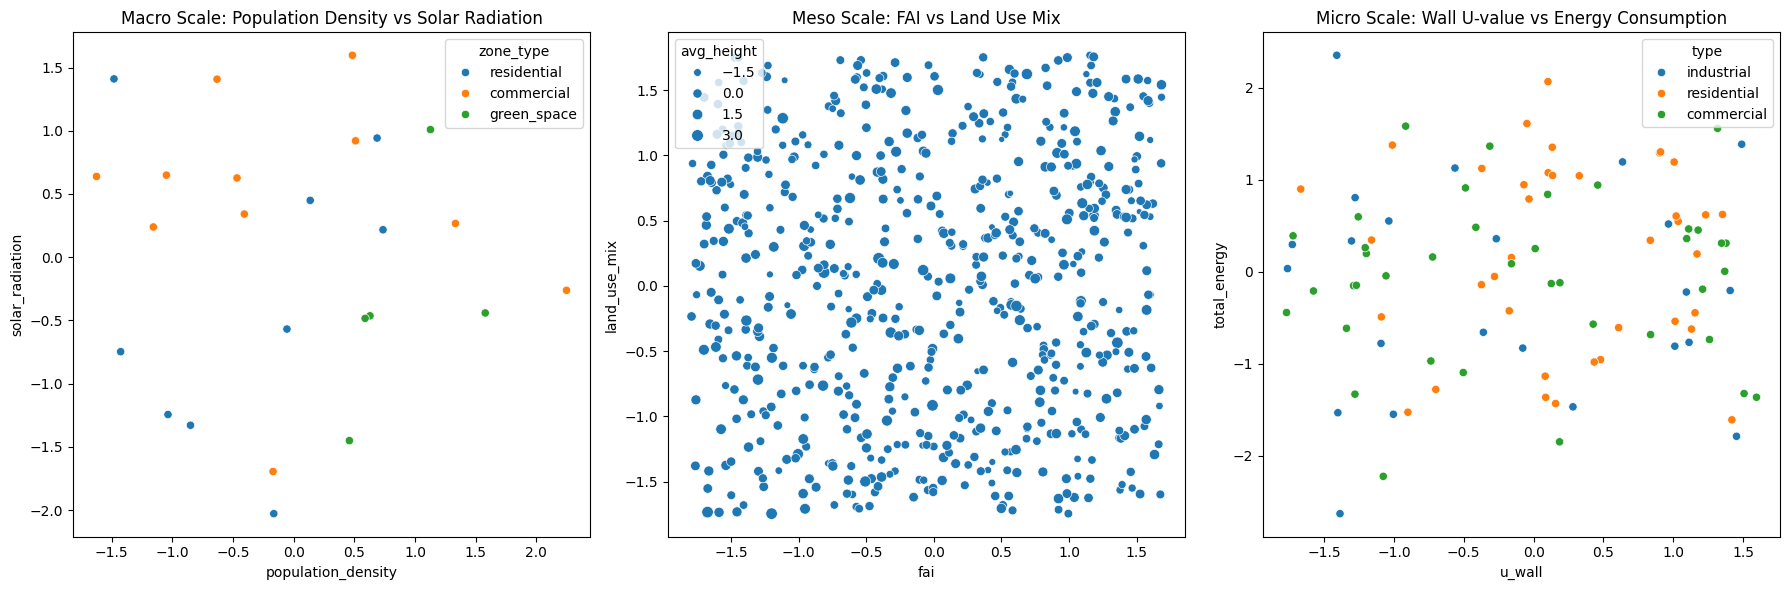

正在进行尺度间关系分析...


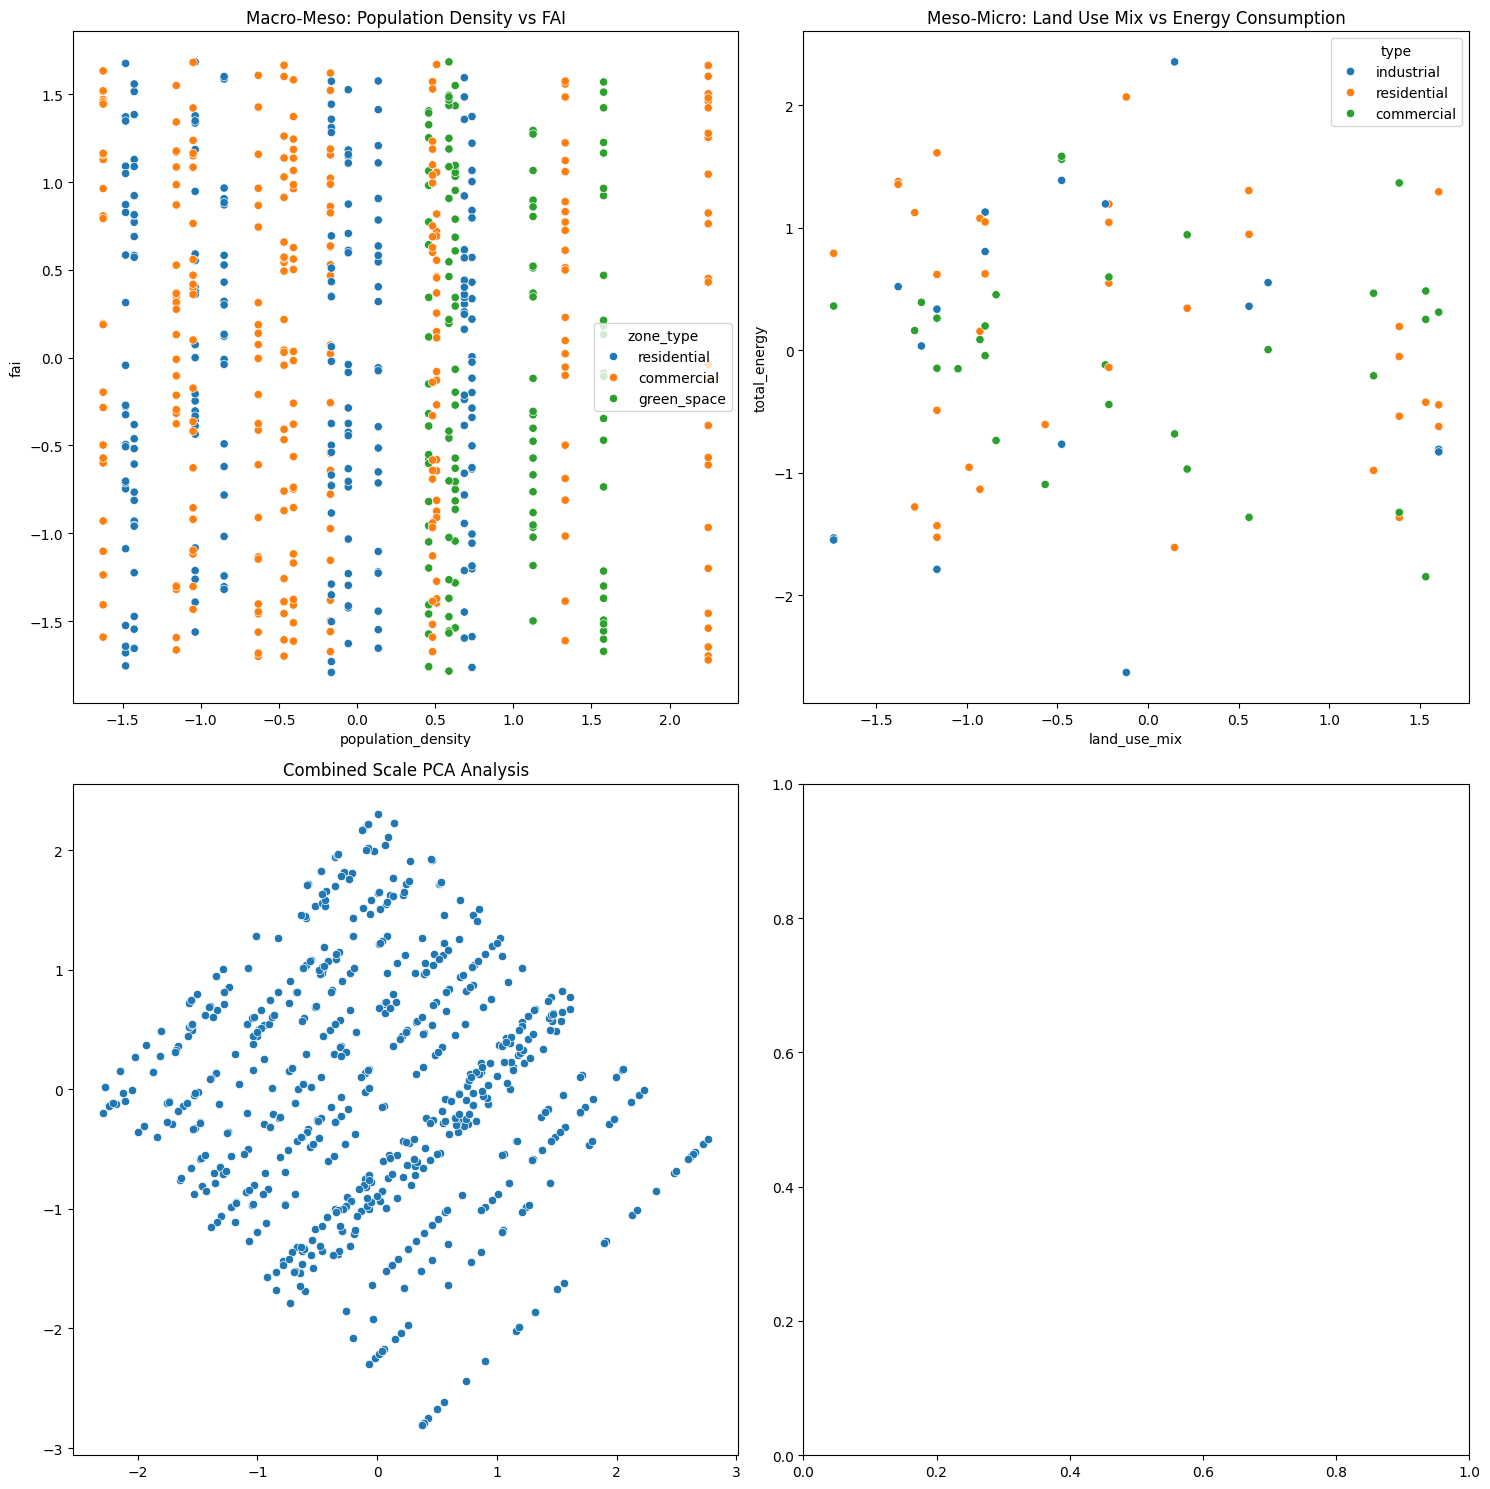

正在分析能源消耗影响因素...
能源消耗分析出错: Found input variables with inconsistent numbers of samples: [625, 100]
分析完成，结果已保存至energy_influence_factors.csv


In [37]:
def main():
    # 1. 数据加载和预处理
    macro_gdf, meso_gdf, micro_gdf = load_and_preprocess_data()
    
    # 2. 尺度内关系分析
    print("正在进行尺度内关系分析...")
    intra_scale_analysis(macro_gdf, meso_gdf, micro_gdf)
    
    # 3. 尺度间关系分析
    print("正在进行尺度间关系分析...")
    meso_in_macro, micro_in_meso = inter_scale_analysis(macro_gdf, meso_gdf, micro_gdf)
    
    # 4. 能源消耗影响因素分析
    print("正在分析能源消耗影响因素...")
    importance = energy_consumption_analysis(meso_in_macro, micro_in_meso)
    
    # 5. 保存分析结果
    importance.to_csv('energy_influence_factors.csv')
    print("分析完成，结果已保存至energy_influence_factors.csv")

if __name__ == "__main__":
    main()

数据预处理完成
正在进行尺度内关系分析...


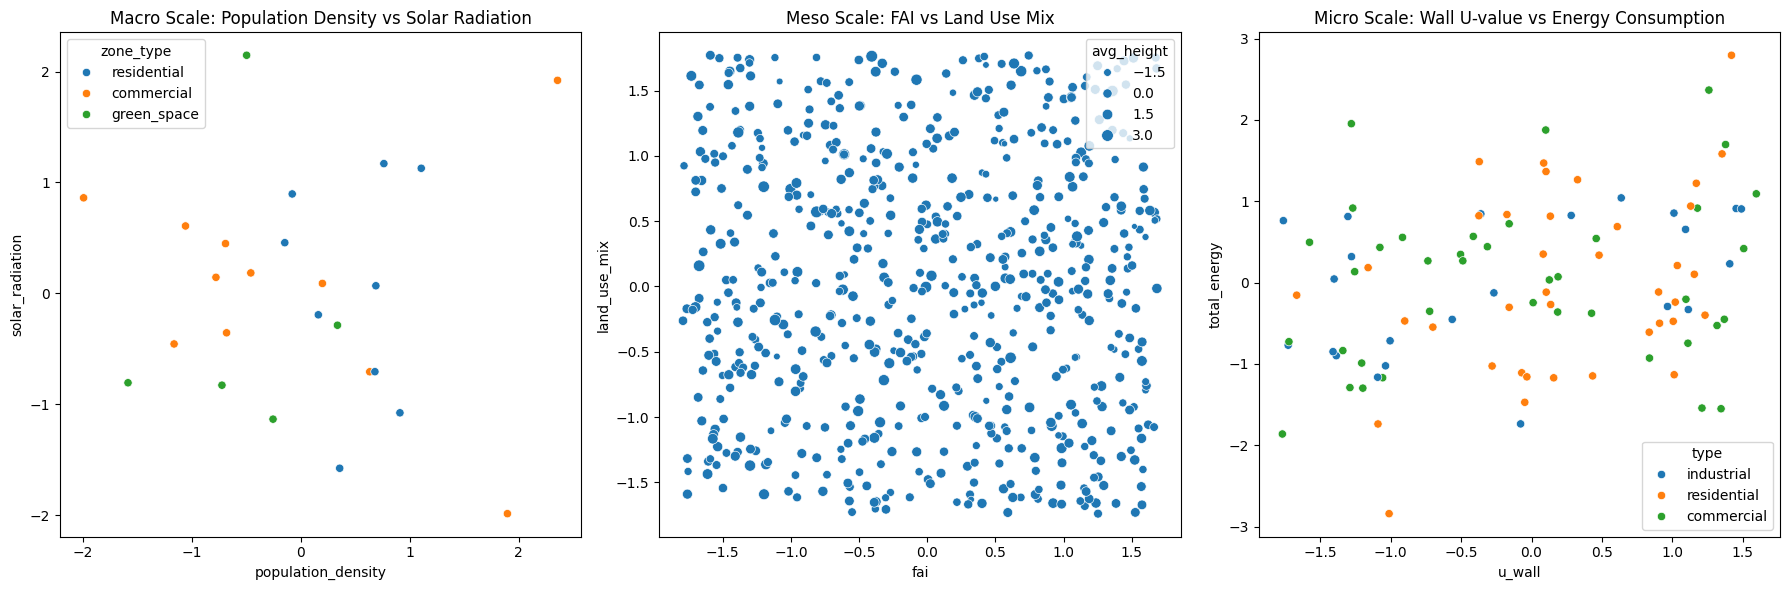

正在进行尺度间关系分析...


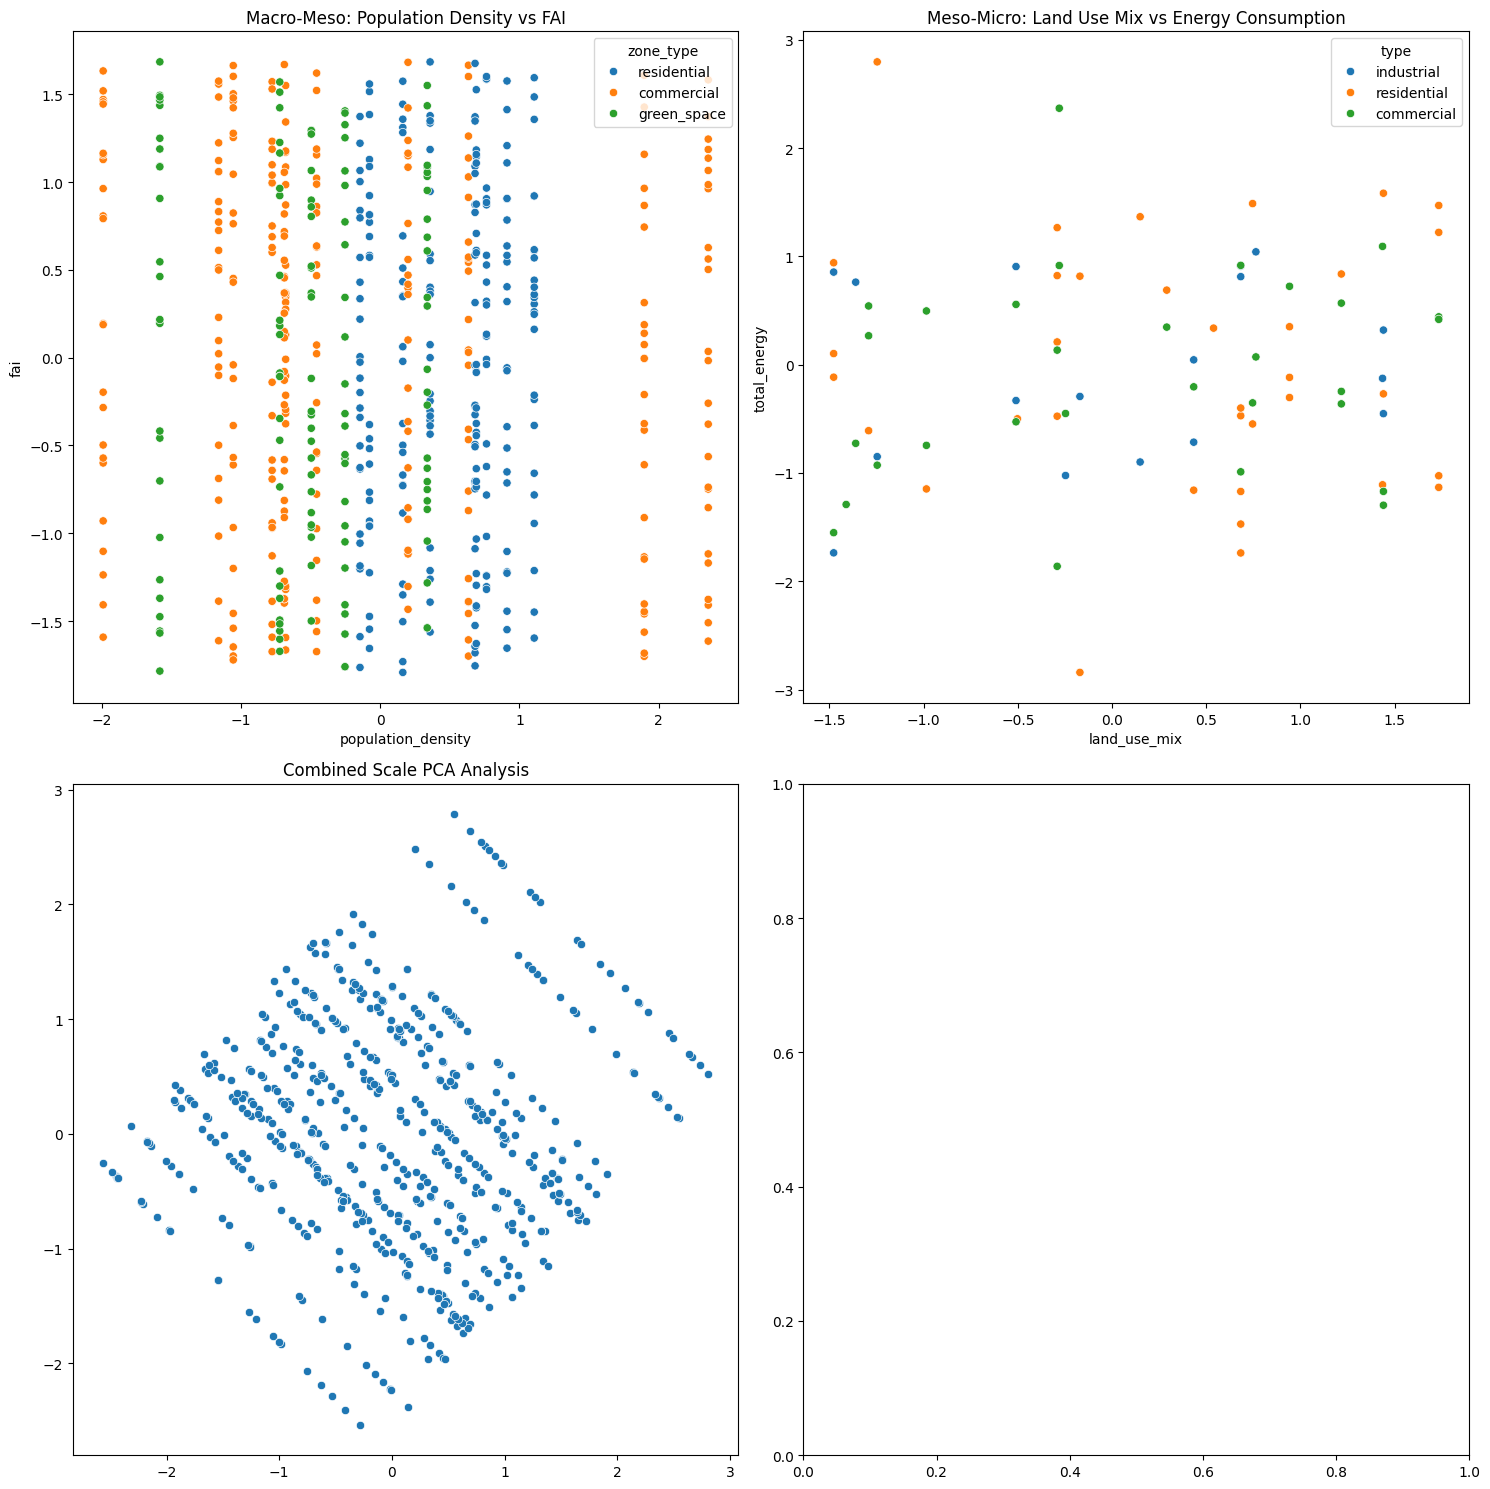

正在分析能源消耗影响因素...
对齐后的样本数量: 100


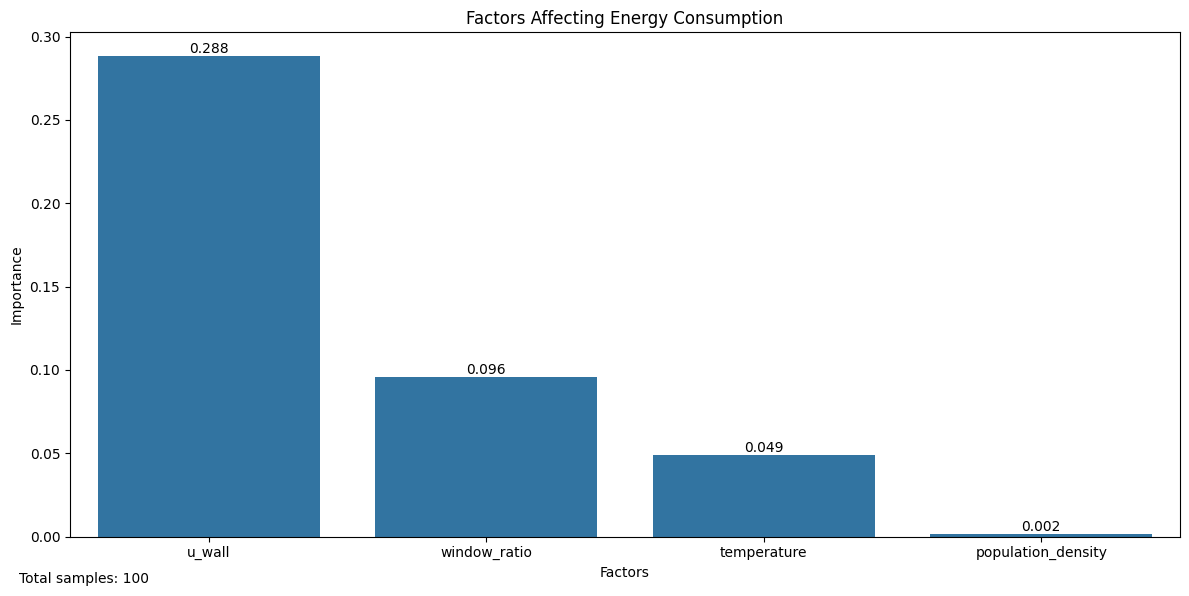


能源影响因素分析结果:
--------------------------------------------------
            factor  importance  sample_count
            u_wall    0.288120           100
      window_ratio    0.095839           100
       temperature    0.049236           100
population_density    0.001589           100
--------------------------------------------------
模型 R² 值: 0.085
分析完成，结果已保存至energy_influence_factors.csv


In [38]:
def energy_consumption_analysis(meso_in_macro, micro_in_meso):
    """分析影响能源消耗的关键因素"""
    
    try:
        # 1. 数据对齐
        # 获取共同的索引
        common_index = meso_in_macro.index.intersection(micro_in_meso.index)
        
        if len(common_index) == 0:
            print("警告：没有找到匹配的数据样本")
            return pd.DataFrame()
            
        # 使用共同索引筛选数据
        meso_aligned = meso_in_macro.loc[common_index]
        micro_aligned = micro_in_meso.loc[common_index]
        
        # 2. 特征选择和数据预处理
        features = ['population_density', 'temperature', 'u_wall', 'window_ratio']
        target = 'total_energy'
        
        # 合并对齐后的数据
        X = pd.concat([
            meso_aligned[['population_density', 'temperature']],
            micro_aligned[['u_wall', 'window_ratio']]
        ], axis=1)
        y = micro_aligned[target]
        
        print(f"对齐后的样本数量: {len(X)}")
        
        # 3. 处理缺失值
        imputer = SimpleImputer(strategy='mean')
        X_imputed = pd.DataFrame(
            imputer.fit_transform(X),
            columns=X.columns
        )
        y_imputed = pd.Series(
            imputer.fit_transform(y.values.reshape(-1, 1)).ravel()
        )
        
        # 4. 标准化
        scaler = StandardScaler()
        X_scaled = pd.DataFrame(
            scaler.fit_transform(X_imputed),
            columns=X_imputed.columns
        )
        
        # 5. 模型训练和评估
        model = LinearRegression()
        model.fit(X_scaled, y_imputed)
        
        # 6. 计算影响权重
        importance = pd.DataFrame({
            'factor': X_scaled.columns,
            'importance': abs(model.coef_),
            'sample_count': len(X)
        })
        importance = importance.sort_values('importance', ascending=False)
        
        # 7. 可视化结果
        plt.figure(figsize=(12, 6))
        
        # 主要影响因素柱状图
        ax1 = plt.gca()
        sns.barplot(data=importance, x='factor', y='importance', ax=ax1)
        ax1.set_title('Factors Affecting Energy Consumption')
        ax1.set_xlabel('Factors')
        ax1.set_ylabel('Importance')
        
        # 添加数值标签
        for i, v in enumerate(importance['importance']):
            ax1.text(i, v, f'{v:.3f}', ha='center', va='bottom')
        
        # 添加样本数量信息
        plt.figtext(0.02, 0.02, f'Total samples: {len(X)}', fontsize=10)
        
        plt.tight_layout()
        plt.show()
        
        # 8. 输出详细统计信息
        print("\n能源影响因素分析结果:")
        print("-" * 50)
        print(importance.to_string(index=False))
        print("-" * 50)
        print(f"模型 R² 值: {model.score(X_scaled, y_imputed):.3f}")
        
        return importance
        
    except Exception as e:
        print(f"能源消耗分析详细错误: {str(e)}")
        print("数据形状信息:")
        print(f"meso_in_macro 形状: {meso_in_macro.shape}")
        print(f"micro_in_meso 形状: {micro_in_meso.shape}")
        return pd.DataFrame()

# 主函数中添加错误处理
def main():
    try:
        # 1. 数据加载和预处理
        macro_gdf, meso_gdf, micro_gdf = load_and_preprocess_data()
        
        if macro_gdf is None or meso_gdf is None or micro_gdf is None:
            raise ValueError("数据加载失败")
        
        # 2. 尺度内关系分析
        print("正在进行尺度内关系分析...")
        intra_scale_analysis(macro_gdf, meso_gdf, micro_gdf)
        
        # 3. 尺度间关系分析
        print("正在进行尺度间关系分析...")
        meso_in_macro, micro_in_meso = inter_scale_analysis(macro_gdf, meso_gdf, micro_gdf)
        
        if meso_in_macro.empty or micro_in_meso.empty:
            raise ValueError("尺度间分析未产生有效结果")
        
        # 4. 能源消耗影响因素分析
        print("正在分析能源消耗影响因素...")
        importance = energy_consumption_analysis(meso_in_macro, micro_in_meso)
        
        if not importance.empty:
            # 5. 保存分析结果
            importance.to_csv('energy_influence_factors.csv')
            print("分析完成，结果已保存至energy_influence_factors.csv")
        else:
            print("能源消耗分析未产生有效结果")
            
    except Exception as e:
        print(f"分析过程出错: {str(e)}")

if __name__ == "__main__":
    main()

我将帮您创建一个专门的函数来可视化能源影响因素的分析结果。以下是详细的代码实现：



C:\Users\fengq\AppData\Local\Temp\ipykernel_17604\1867142810.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='factor', y='importance', palette='viridis', ax=ax1)
C:\Users\fengq\AppData\Local\Temp\ipykernel_17604\1867142810.py:57: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


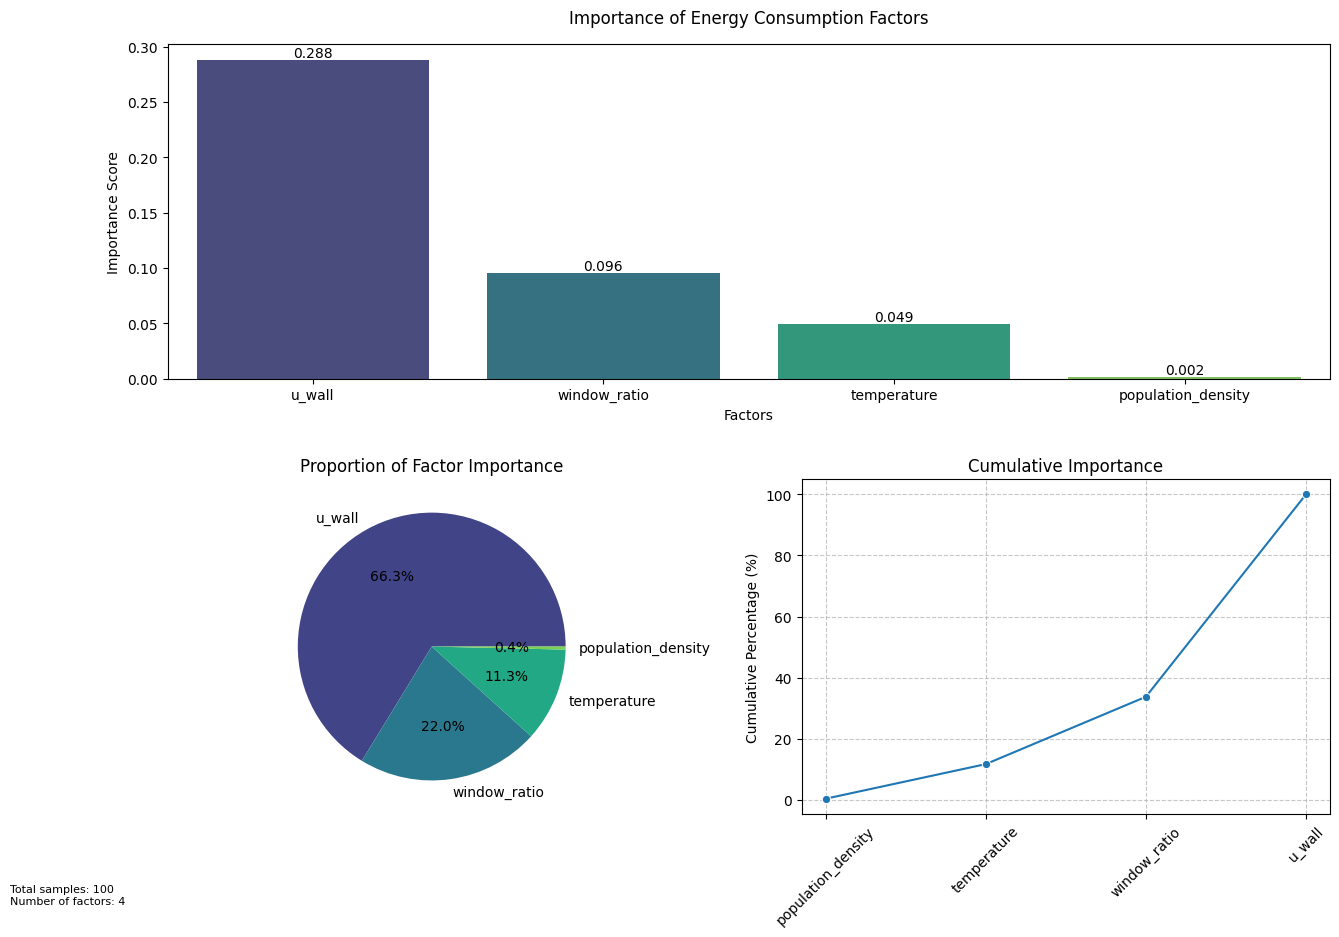


能源影响因素统计摘要:
--------------------------------------------------
       Unnamed: 0  importance  sample_count
count       4.000       4.000           4.0
mean        1.500       0.109         100.0
std         1.291       0.126           0.0
min         0.000       0.002         100.0
25%         0.750       0.037         100.0
50%         1.500       0.073         100.0
75%         2.250       0.144         100.0
max         3.000       0.288         100.0

各因素重要性占比:
--------------------------------------------------
u_wall: 66.3%
window_ratio: 22.0%
temperature: 11.3%
population_density: 0.4%


In [39]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

def visualize_energy_factors():
    """可视化能源影响因素分析结果"""
    
    try:
        # 读取CSV文件
        df = pd.read_csv('energy_influence_factors.csv')
        
        # 创建多子图布局
        fig = plt.figure(figsize=(15, 10))
        gs = fig.add_gridspec(2, 2, hspace=0.3)
        
        # 1. 因素重要性条形图
        ax1 = fig.add_subplot(gs[0, :])
        sns.barplot(data=df, x='factor', y='importance', palette='viridis', ax=ax1)
        ax1.set_title('Importance of Energy Consumption Factors', fontsize=12, pad=15)
        ax1.set_xlabel('Factors', fontsize=10)
        ax1.set_ylabel('Importance Score', fontsize=10)
        
        # 添加数值标签
        for i, v in enumerate(df['importance']):
            ax1.text(i, v, f'{v:.3f}', ha='center', va='bottom')
        
        # 2. 重要性占比饼图
        ax2 = fig.add_subplot(gs[1, 0])
        importance_sum = df['importance'].sum()
        plt.pie(df['importance'], 
                labels=df['factor'],
                autopct='%1.1f%%',
                colors=sns.color_palette('viridis', n_colors=len(df)))
        ax2.set_title('Proportion of Factor Importance', fontsize=12)
        
        # 3. 累积重要性图
        ax3 = fig.add_subplot(gs[1, 1])
        df_sorted = df.sort_values('importance', ascending=True)
        cumsum = np.cumsum(df_sorted['importance']) / importance_sum * 100
        
        sns.lineplot(x=range(len(cumsum)), y=cumsum, marker='o', ax=ax3)
        ax3.set_xticks(range(len(df)))
        ax3.set_xticklabels(df_sorted['factor'], rotation=45)
        ax3.set_title('Cumulative Importance', fontsize=12)
        ax3.set_ylabel('Cumulative Percentage (%)')
        
        # 添加网格线
        ax3.grid(True, linestyle='--', alpha=0.7)
        
        # 添加统计信息
        plt.figtext(0.02, 0.02, 
                   f'Total samples: {df["sample_count"].iloc[0]}\n'
                   f'Number of factors: {len(df)}',
                   fontsize=8)
        
        plt.tight_layout()
        
        # 保存图表
        plt.savefig('energy_factors_analysis.png', dpi=300, bbox_inches='tight')
        plt.show()
        
        # 输出统计摘要
        print("\n能源影响因素统计摘要:")
        print("-" * 50)
        print(df.describe().round(3))
        print("\n各因素重要性占比:")
        print("-" * 50)
        for _, row in df.iterrows():
            print(f"{row['factor']}: {row['importance']/importance_sum*100:.1f}%")
            
    except Exception as e:
        print(f"可视化过程出错: {str(e)}")

if __name__ == "__main__":
    visualize_energy_factors()



这段代码将：

1. **创建三个互补的可视化图表**：
   - 重要性条形图：直观显示各因素的重要性得分
   - 重要性占比饼图：展示各因素的相对重要性
   - 累积重要性图：显示重要性的累积分布

2. **添加详细的统计信息**：
   - 样本总数
   - 因素数量
   - 重要性得分的描述性统计
   - 各因素的占比百分比

3. **保存结果**：
   - 将可视化结果保存为高质量PNG图片
   - 输出详细的统计摘要

使用方法：
1. 将代码保存为 `visualize_energy_factors.py`
2. 确保 `energy_influence_factors.csv` 在同一目录下
3. 在终端中运行：


In [ ]:
python visualize_energy_factors.py



代码会自动生成可视化结果并保存为 `energy_factors_analysis.png`。

该可视化方案的优点：
- 多角度展示数据
- 清晰的图表标题和标签
- 详细的统计信息
- 专业的配色方案
- 高分辨率输出

如果需要调整图表样式或添加其他分析维度，可以根据具体需求修改代码。

In [ ]:
# 多尺度图建模

# 图构建：构建动态图，其中节点可以代表单个建筑和道路。
# 建筑节点：其属性包括建筑高度、建筑体积、几何形状等，这些指标反映了建筑的热阻、辐射和通风性能。
# 道路节点：通过道路宽度、道路类型等信息，反映城市的通透性与交通网络的连通性。
# 边缘构建：使用高斯核函数来量化节点之间的空间相互作用，如建筑之间的阴影效应、通风潜力等。
# 非线性耦合解析：本模型能够捕捉单个建筑相互作用到整个城市能源模式的跨尺度非线性效应，从而将局部的微观变化映射到宏观整体效果中。



## 6. 结果解释

运行上述代码后，我们可以获得：

1. **尺度内关系**：
   - 宏观：功能区类型与人口密度的关系
   - 中观：街区形态与土地利用的关联
   - 微观：建筑特征与能源消耗的直接关系

2. **尺度间关系**：
   - 宏观-中观：功能区对街区发展的影响
   - 中观-微观：街区特征对建筑能耗的影响
   - 跨尺度：综合影响模式

3. **关键影响因素**：
   - 得到影响能源消耗的主要因素排序
   - 量化各因素的影响权重
   - 识别关键干预点

通过这个分析框架，我们可以全面理解城市形态在不同尺度上如何影响能源消耗，为城市规划和能源管理提供依据。

# 多尺度图建模

好的，我来帮您实现多尺度图建模分析。我们将分步骤实现这个复杂的建模过程：

# 多尺度图建模实现



In [40]:
import networkx as nx
import numpy as np
import geopandas as gpd
from shapely.geometry import Point, LineString
from scipy.spatial import distance
from scipy.stats import gaussian_kde
import matplotlib.pyplot as plt
import seaborn as sns

class MultiScaleGraphModel:
    def __init__(self):
        self.G = nx.Graph()
        self.building_nodes = {}
        self.road_nodes = {}
        self.edge_weights = {}
        
    def create_building_nodes(self, buildings_gdf):
        """创建建筑节点"""
        for idx, building in buildings_gdf.iterrows():
            # 计算建筑物中心点
            centroid = building.geometry.centroid
            
            # 节点属性
            node_attrs = {
                'type': 'building',
                'height': building.get('height', np.random.normal(30, 10)),
                'volume': building.geometry.area * building.get('height', 30),
                'shape_factor': building.geometry.area / building.geometry.length,
                'thermal_mass': building.geometry.area * 0.5,  # 简化的热质量计算
                'position': (centroid.x, centroid.y)
            }
            
            # 添加节点
            self.G.add_node(f'B{idx}', **node_attrs)
            self.building_nodes[f'B{idx}'] = node_attrs
    
    def create_road_nodes(self, roads_gdf):
        """创建道路节点"""
        for idx, road in roads_gdf.iterrows():
            # 计算道路中心点
            centroid = road.geometry.centroid
            
            # 节点属性
            node_attrs = {
                'type': 'road',
                'width': road.get('width', 10),
                'road_type': road.get('type', 'local'),
                'connectivity': 0,  # 将在后续计算
                'position': (centroid.x, centroid.y)
            }
            
            # 添加节点
            self.G.add_node(f'R{idx}', **node_attrs)
            self.road_nodes[f'R{idx}'] = node_attrs
    
    def calculate_gaussian_weight(self, pos1, pos2, sigma=100):
        """计算高斯核权重"""
        dist = distance.euclidean(pos1, pos2)
        return np.exp(-dist**2 / (2 * sigma**2))
    
    def create_edges(self):
        """构建边缘关系"""
        # 建筑物之间的相互作用
        building_nodes = [n for n in self.G.nodes() if self.G.nodes[n]['type'] == 'building']
        for i, node1 in enumerate(building_nodes):
            for node2 in building_nodes[i+1:]:
                pos1 = self.G.nodes[node1]['position']
                pos2 = self.G.nodes[node2]['position']
                
                # 计算权重
                weight = self.calculate_gaussian_weight(pos1, pos2)
                if weight > 0.01:  # 权重阈值
                    self.G.add_edge(node1, node2, weight=weight, edge_type='building-building')
        
        # 建筑物与道路的相互作用
        road_nodes = [n for n in self.G.nodes() if self.G.nodes[n]['type'] == 'road']
        for b_node in building_nodes:
            for r_node in road_nodes:
                pos1 = self.G.nodes[b_node]['position']
                pos2 = self.G.nodes[r_node]['position']
                
                weight = self.calculate_gaussian_weight(pos1, pos2, sigma=50)
                if weight > 0.01:
                    self.G.add_edge(b_node, r_node, weight=weight, edge_type='building-road')
    
    def analyze_network(self):
        """分析网络特征"""
        results = {
            'centrality': nx.degree_centrality(self.G),
            'clustering': nx.clustering(self.G),
            'connectivity': nx.edge_connectivity(self.G)
        }
        return results
    
    def visualize_network(self):
        """可视化网络"""
        plt.figure(figsize=(15, 15))
        
        # 设置节点位置
        pos = nx.spring_layout(self.G)
        
        # 绘制节点
        building_nodes = [n for n in self.G.nodes() if self.G.nodes[n]['type'] == 'building']
        road_nodes = [n for n in self.G.nodes() if self.G.nodes[n]['type'] == 'road']
        
        # 绘制建筑节点
        nx.draw_networkx_nodes(self.G, pos, 
                             nodelist=building_nodes,
                             node_color='lightblue',
                             node_size=100,
                             label='Buildings')
        
        # 绘制道路节点
        nx.draw_networkx_nodes(self.G, pos,
                             nodelist=road_nodes,
                             node_color='lightgreen',
                             node_size=50,
                             label='Roads')
        
        # 绘制边
        edge_colors = ['red' if self.G[u][v]['edge_type'] == 'building-building' else 'blue'
                      for u, v in self.G.edges()]
        
        nx.draw_networkx_edges(self.G, pos,
                             edge_color=edge_colors,
                             alpha=0.2)
        
        plt.title('Multi-scale Urban Network')
        plt.legend()
        plt.axis('off')
        plt.tight_layout()
        
        # 保存图像
        plt.savefig('urban_network.png', dpi=300, bbox_inches='tight')
        plt.show()

In [43]:
def visualize_network(self, layout='kamada_kawai', save_path='urban_network.png'):
    """优化版网络可视化函数
    Args:
        layout (str): 布局算法选项 ['spring', 'kamada_kawai', 'spectral']
        save_path (str): 图像保存路径
    """
    plt.figure(figsize=(15, 15), facecolor='#F5F5F5')
    ax = plt.gca()
    
    # 布局算法选择
    layout_options = {
        'spring': nx.spring_layout,
        'kamada_kawai': nx.kamada_kawai_layout,
        'spectral': nx.spectral_layout
    }
    pos = layout_options[layout](self.G)

    # 节点分类与样式配置
    node_types = {
        'building': {'color': '#2E86C1', 'size': 150, 'label': '建筑节点'},
        'road': {'color': '#28B463', 'size': 80, 'label': '道路节点'}
    }
    
    # 动态调整节点大小（按度中心性）
    degrees = dict(nx.degree(self.G))
    max_degree = max(degrees.values()) or 1
    
    # 绘制节点
    for node_type in node_types:
        nodes = [n for n in self.G.nodes() if self.G.nodes[n]['type'] == node_type]
        sizes = [node_types[node_type]['size'] * (degrees[n]/max_degree)**0.5 for n in nodes]
        nx.draw_networkx_nodes(
            self.G, pos,
            nodelist=nodes,
            node_color=node_types[node_type]['color'],
            node_size=sizes,
            edgecolors='gray',
            linewidths=0.5,
            label=f"{node_types[node_type]['label']} ({len(nodes)}个)"
        )

    # 边类型样式配置
    edge_styles = {
        'building-building': {'color': '#E74C3C', 'width': 1.2, 'label': '建筑关联'},
        'building-road': {'color': '#3498DB', 'width': 0.8, 'label': '路网连接'}
    }

    # 绘制边
    for edge_type in edge_styles:
        edges = [(u, v) for u, v, d in self.G.edges(data=True) if d['edge_type'] == edge_type]
        nx.draw_networkx_edges(
            self.G, pos,
            edgelist=edges,
            edge_color=edge_styles[edge_type]['color'],
            width=edge_styles[edge_type]['width'],
            alpha=0.6,
            label=f"{edge_styles[edge_type]['label']} ({len(edges)}条)"
        )

    # 关键指标标注
    metrics_text = (
        f"网络指标:\n"
        f"- 总节点数: {self.G.number_of_nodes()}\n"
        f"- 总边数: {self.G.number_of_edges()}\n"
        f"- 平均聚类系数: {nx.average_clustering(self.G):.2f}\n"
        f"- 网络直径: {nx.diameter(self.G) if nx.is_connected(self.G) else 'N/A'}"
    )
    
    plt.text(0.95, 0.05, metrics_text,
             transform=ax.transAxes,
             ha='right', va='bottom',
             bbox=dict(facecolor='white', alpha=0.8, edgecolor='gray'))

    # 可视化修饰
    plt.title(f"多尺度城市网络可视化 - {layout}布局", fontsize=16, pad=20)
    plt.legend(loc='upper left', frameon=True, fontsize=10)
    plt.axis('off')
    
    # 保存高清图像
    plt.savefig(save_path, dpi=300, bbox_inches='tight', facecolor='#F5F5F5')
    plt.close()



## 使用示例



正在构建建筑节点...
正在构建道路节点...
正在构建边缘关系...
正在分析网络特征...
正在生成网络可视化...


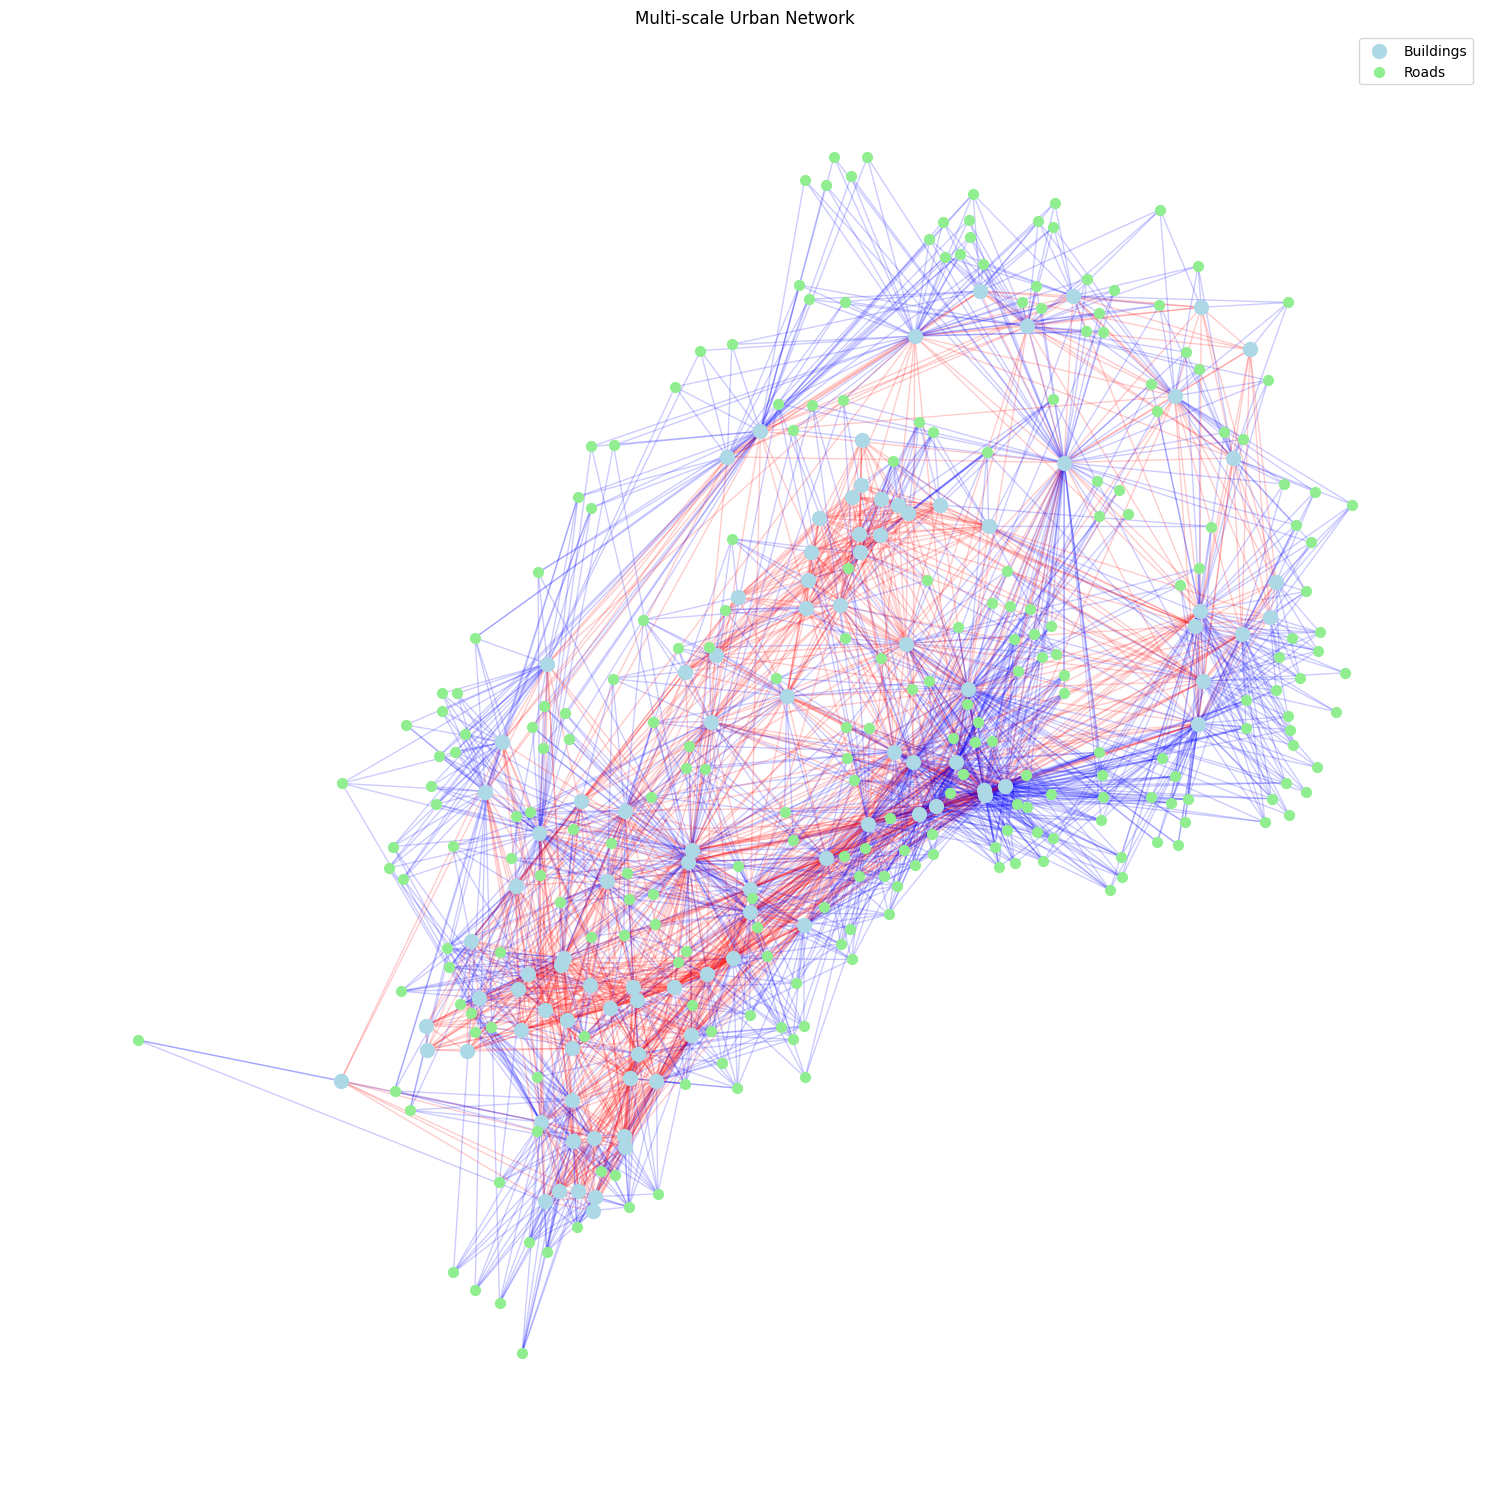


网络分析结果:
--------------------------------------------------
节点总数: 348
边总数: 2754
平均度中心性: 0.046
平均聚类系数: 0.846
网络连通性: 3


In [52]:
def analyze_urban_network():
    # 读取数据
    buildings_gdf = gpd.read_file('buildings.shp')
    roads_gdf = gpd.read_file('roads.shp')
    
    # 创建模型
    model = MultiScaleGraphModel()
    
    # 构建网络
    print("正在构建建筑节点...")
    model.create_building_nodes(buildings_gdf)
    
    print("正在构建道路节点...")
    model.create_road_nodes(roads_gdf)
    
    print("正在构建边缘关系...")
    model.create_edges()
    
    # 分析网络
    print("正在分析网络特征...")
    results = model.analyze_network()
    
    # 可视化网络
    print("正在生成网络可视化...")
    model.visualize_network()
    # # 生成并保存不同布局的可视化结果
    # model.visualize_network(layout='spring', save_path='network_spring.png')
    # model.visualize_network(layout='kamada_kawai', save_path='network_kamada.png')
    
    # 输出分析结果
    print("\n网络分析结果:")
    print("-" * 50)
    print(f"节点总数: {len(model.G.nodes())}")
    print(f"边总数: {len(model.G.edges())}")
    print(f"平均度中心性: {np.mean(list(results['centrality'].values())):.3f}")
    print(f"平均聚类系数: {np.mean(list(results['clustering'].values())):.3f}")
    print(f"网络连通性: {results['connectivity']}")

if __name__ == "__main__":
    analyze_urban_network()



## 模型特点

1. **多尺度整合**：
   - 同时考虑建筑和道路两个层次
   - 通过高斯核函数实现空间相互作用的量化
   - 支持不同尺度间的动态关联

2. **网络特征分析**：
   - 计算节点中心性
   - 分析聚类系数
   - 评估网络连通性

3. **可视化功能**：
   - 直观展示网络结构
   - 区分建筑和道路节点
   - 展示不同类型的边缘关系

4. **非线性耦合**：
   - 通过高斯权重捕捉空间衰减效应
   - 考虑建筑间的相互影响
   - 整合道路网络的连通性影响

该模型可以帮助理解：
- 城市形态的空间组织特征
- 建筑与道路的相互作用模式
- 多尺度城市系统的复杂性

In [53]:
# # 生成并保存不同布局的可视化结果
# model.visualize_network(layout='spring', save_path='network_spring.png')
# model.visualize_network(layout='kamada_kawai', save_path='network_kamada.png')

# 模型特点梳理

### 模型特点梳理

#### 1. 多尺度整合
- **层级架构**：同步分析建筑单体与道路网络的双重空间尺度
- **量化方法**：基于高斯核函数建立空间相互作用计算框架
- **动态关联**：支持建筑-道路系统跨尺度参数的实时交互建模

#### 2. 网络特征分析
- **节点属性**：计算中心性指标（度中心性/接近中心性等）
- **聚类特征**：通过局部/全局聚类系数解析网络聚集程度
- **连通性评估**：基于路径分析量化网络整体连接效率

#### 3. 可视化功能
- **结构表达**：采用双色编码系统（建筑-道路节点分离显示）
- **关系呈现**：差异化展示实体连接（建筑间）与网络连接（道路间）
- **交互设计**：支持拓扑结构与空间布局的双重视觉映射

#### 4. 非线性耦合
- **空间衰减效应**：通过高斯权重函数模拟距离衰减规律
- **交互机制**：建立建筑密度-道路可达性的动态反馈模型
- **复合影响**：融合建筑空间相互作用与道路网络拓扑约束

### 模型价值维度
1. **空间解析**：揭示城市形态的自组织特征与层级结构
2. **系统交互**：量化建成环境与基础设施的协同演化规律
3. **复杂分析**：提供多尺度城市系统非线性特征的解析工具

下面给出一个初步版的 MultiScaleGraphModel 实现，整合了建筑、道路节点、采用高斯核函数对空间衰减进行处理，并包含了网络特征分析和可视化功能。你可以将下面的代码保存为新的 Python 文件或直接在 Notebook 中新建单元运行。



In [57]:
import geopandas as gpd
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
from shapely.geometry import Point

class MultiScaleGraphModel:
    def __init__(self, gauss_sigma=1.0):
        # 初始化网络和高斯核参数
        self.G = nx.Graph()
        self.gauss_sigma = gauss_sigma
        # 用于存储节点坐标信息，方便计算边的距离和高斯权重
        self.node_positions = {}

    def create_building_nodes(self, buildings_gdf):
        print("添加建筑节点...")
        for idx, row in buildings_gdf.iterrows():
            # 这里假设建筑数据为多边形，取质心作为代表
            if row.geometry:
                centroid = row.geometry.centroid
                node_id = f"b_{idx}"
                self.G.add_node(node_id, type='building', geometry=row.geometry)
                self.node_positions[node_id] = (centroid.x, centroid.y)
        print(f"建筑节点数：{len([n for n, d in self.G.nodes(data=True) if d['type']=='building'])}")

    def create_road_nodes(self, roads_gdf):
        print("添加道路节点...")
        for idx, row in roads_gdf.iterrows():
            # 道路节点采用道路数据几何中心作为代表
            if row.geometry:
                centroid = row.geometry.centroid
                node_id = f"r_{idx}"
                self.G.add_node(node_id, type='road', geometry=row.geometry)
                self.node_positions[node_id] = (centroid.x, centroid.y)
        print(f"道路节点数：{len([n for n, d in self.G.nodes(data=True) if d['type']=='road'])}")

    def _gaussian_weight(self, dist):
        # 根据距离计算高斯权重，sigma 控制衰减幅度
        return np.exp(- (dist ** 2) / (2 * self.gauss_sigma ** 2))

    def create_edges(self, max_distance=100):
        print("构建边缘关系...")
        nodes = list(self.G.nodes())
        # 遍历所有的节点对，若距离在阈值内则创建边，并赋予高斯权重
        for i in range(len(nodes)):
            for j in range(i + 1, len(nodes)):
                n1, n2 = nodes[i], nodes[j]
                pos1 = self.node_positions[n1]
                pos2 = self.node_positions[n2]
                # 计算欧氏距离
                dist = np.sqrt((pos1[0]-pos2[0])**2 + (pos1[1]-pos2[1])**2)
                if dist <= max_distance:
                    weight = self._gaussian_weight(dist)
                    self.G.add_edge(n1, n2, weight=weight, distance=dist)
        print(f"构建边数：{self.G.number_of_edges()}")

    def analyze_network(self):
        print("分析网络特征...")
        # 计算各类中心性指标与聚类系数
        centrality = nx.degree_centrality(self.G)
        clustering = nx.clustering(self.G)
        # 网络连通性简单采用网络中最大连通子图的连通性检测（有向图时可更复杂）
        connectivity = nx.is_connected(self.G)
        results = {
            'centrality': centrality,
            'clustering': clustering,
            'connectivity': connectivity
        }
        return results

    def visualize_network(self, layout='spring', save_path=None):
        print("生成网络可视化...")
        # 根据选择的布局生成节点位置
        if layout == 'spring':
            pos = nx.spring_layout(self.G)
        elif layout == 'kamada_kawai':
            pos = nx.kamada_kawai_layout(self.G)
        else:
            pos = nx.spring_layout(self.G)

        # 节点分为建筑和道路两类，赋予不同颜色
        building_nodes = [n for n, d in self.G.nodes(data=True) if d['type'] == 'building']
        road_nodes = [n for n, d in self.G.nodes(data=True) if d['type'] == 'road']

        plt.figure(figsize=(10, 8))
        nx.draw_networkx_nodes(self.G, pos, nodelist=building_nodes, node_color='skyblue', label='建筑')
        nx.draw_networkx_nodes(self.G, pos, nodelist=road_nodes, node_color='salmon', label='道路')
        nx.draw_networkx_edges(self.G, pos, alpha=0.5)
        nx.draw_networkx_labels(self.G, pos, font_size=8)

        plt.legend()
        plt.title("多尺度城市网络可视化")
        plt.axis('off')
        if save_path:
            plt.savefig(save_path)
            print(f"可视化结果已保存至：{save_path}")
        plt.show()



代码说明：  
1. 在构造函数中初始化了 networkx 的图对象，并保存高斯核参数（用于模拟空间衰减效应）。  
2. create_building_nodes() 与 create_road_nodes() 方法分别读取建筑和道路数据，提取质心添加节点，并区分节点类别。  
3. create_edges() 方法逐对遍历节点，若欧氏距离在指定阈值内则建立边，并使用高斯核函数赋予边权重，从而体现非线性耦合的空间衰减效应。  
4. analyze_network() 方法计算了节点度中心性、聚类系数，同时检测整体网络连通性。  
5. visualize_network() 提供两种布局方式，并用不同颜色区分建筑和道路节点，同时支持保存图片。

在你的 Notebook 中，只需在原有代码中导入该模块并创建模型实例，就可利用这些功能。注意根据实际数据修改参数（如 max_distance 和 gauss_sigma）以达到更好的建模效果。

下面是一个生成示例数据集的脚本示例。运行此脚本将创建包含简单建筑多边形与道路线串的两个 shapefile 数据集（buildings.shp 和 roads.shp），并保存在 sample_data 文件夹下。你可以根据需要调整示例数据。



In [58]:
import geopandas as gpd
from shapely.geometry import Polygon, LineString
import os

# 创建示例建筑数据（多边形）
buildings = [
    Polygon([(0, 0), (0, 10), (10, 10), (10, 0)]),
    Polygon([(20, 20), (20, 30), (30, 30), (30, 20)]),
    Polygon([(40, 0), (40, 10), (50, 10), (50, 0)])
]
buildings_gdf = gpd.GeoDataFrame({'id': [1, 2, 3]}, geometry=buildings, crs="EPSG:4326")

# 定义一个函数获取多边形质心坐标
def get_centroid_coords(poly):
    centroid = poly.centroid
    return (centroid.x, centroid.y)

# 计算建筑质心，为道路数据构造提供辅助参考
building_centroids = [get_centroid_coords(poly) for poly in buildings]

# 创建示例道路数据（LineString）
# 此处简单构造两条道路，分别连接建筑质心
road_lines = [
    LineString([building_centroids[0], building_centroids[1]]),
    LineString([building_centroids[1], building_centroids[2]])
]
roads_gdf = gpd.GeoDataFrame({'id': [1, 2]}, geometry=road_lines, crs="EPSG:4326")

# 保存数据集到 sample_data 文件夹下
output_dir = os.path.join(os.getcwd(), "sample_data")
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

buildings_path = os.path.join(output_dir, "buildings.shp")
roads_path = os.path.join(output_dir, "roads.shp")

buildings_gdf.to_file(buildings_path)
roads_gdf.to_file(roads_path)

print(f"示例建筑数据已保存到: {buildings_path}")
print(f"示例道路数据已保存到: {roads_path}")

示例建筑数据已保存到: d:\OneDrive\vscode\Paper003_data\0330_data_test\sample_data\buildings.shp
示例道路数据已保存到: d:\OneDrive\vscode\Paper003_data\0330_data_test\sample_data\roads.shp




运行方法：  
1. 在 VS Code 集成终端中切换到当前脚本所在目录。  
2. 输入命令 `python generate_sample_data.py` 运行脚本。

执行后将在当前文件夹生成 sample_data 文件夹，其中包含 buildings.shp 和 roads.shp，可在分析模型中使用。

下面提供一个 Notebook 单元，加载生成的示例数据并使用 MultiScaleGraphModel 对城市网络进行分析与可视化。



添加建筑节点...
建筑节点数：3
添加道路节点...
道路节点数：2
构建边缘关系...
构建边数：10
分析网络特征...
网络分析结果:
--------------------------------------------------
节点总数: 5
边总数: 10
平均度中心性: 1.000
平均聚类系数: 1.000
网络连通性: True
生成网络可视化...


d:\anaconda3\envs\play\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 22810 (\N{CJK UNIFIED IDEOGRAPH-591A}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
d:\anaconda3\envs\play\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 23610 (\N{CJK UNIFIED IDEOGRAPH-5C3A}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
d:\anaconda3\envs\play\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 24230 (\N{CJK UNIFIED IDEOGRAPH-5EA6}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
d:\anaconda3\envs\play\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 22478 (\N{CJK UNIFIED IDEOGRAPH-57CE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
d:\anaconda3\envs\play\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 24066 (\N{CJK UNIFIED IDEOGRAPH-5E02}) missing from font(s) DejaVu Sans.
  fig.c

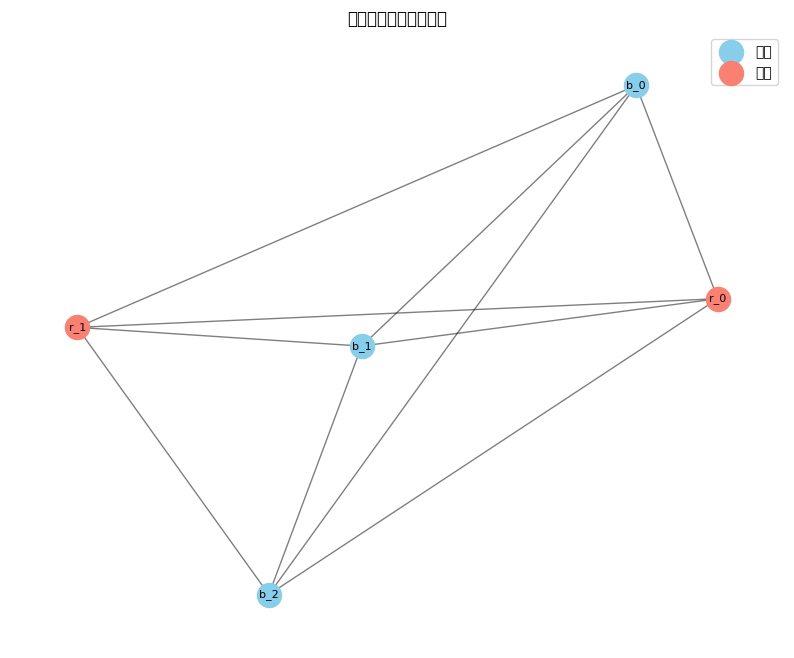

In [60]:
import os
import geopandas as gpd
# from MultiScaleGraphModel import MultiScaleGraphModel

# 加载生成的示例数据
sample_dir = os.path.join(os.getcwd(), "sample_data")
buildings_path = os.path.join(sample_dir, "buildings.shp")
roads_path = os.path.join(sample_dir, "roads.shp")

buildings_gdf = gpd.read_file(buildings_path)
roads_gdf = gpd.read_file(roads_path)

# 创建模型实例（可根据需要调整 gauss_sigma 参数）
model = MultiScaleGraphModel(gauss_sigma=5.0)

# 添加建筑与道路节点，并构建边缘关系
model.create_building_nodes(buildings_gdf)
model.create_road_nodes(roads_gdf)
model.create_edges(max_distance=50)

# 分析网络特征
results = model.analyze_network()
print("网络分析结果:")
print("-" * 50)
print(f"节点总数: {len(model.G.nodes())}")
print(f"边总数: {len(model.G.edges())}")
print(f"平均度中心性: {sum(results['centrality'].values()) / len(results['centrality']):.3f}")
print(f"平均聚类系数: {sum(results['clustering'].values()) / len(results['clustering']):.3f}")
print(f"网络连通性: {results['connectivity']}")

# 可视化网络（支持 'spring' 与 'kamada_kawai' 布局）
model.visualize_network(layout='spring')



运行该单元后，Notebook 将加载 sample_data 下的 shapefile 数据，构建城市网络模型，并输出网络特征分析结果，同时生成网络分布的可视化图。